In [1]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib as mpl
import numpy as np
import os    

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.style.use(['science', 'ieee'])
con = duckdb.connect(database = 'results-legacy.db', read_only = False)

output = widgets.Output()

plt.rcParams.update({'font.size': 18})
plt.rcParams['axes.prop_cycle'] = mpl.cycler('linestyle', ['-', '--', ':', '-.']) + mpl.cycler('color', ['b', 'r', 'g', 'm'])

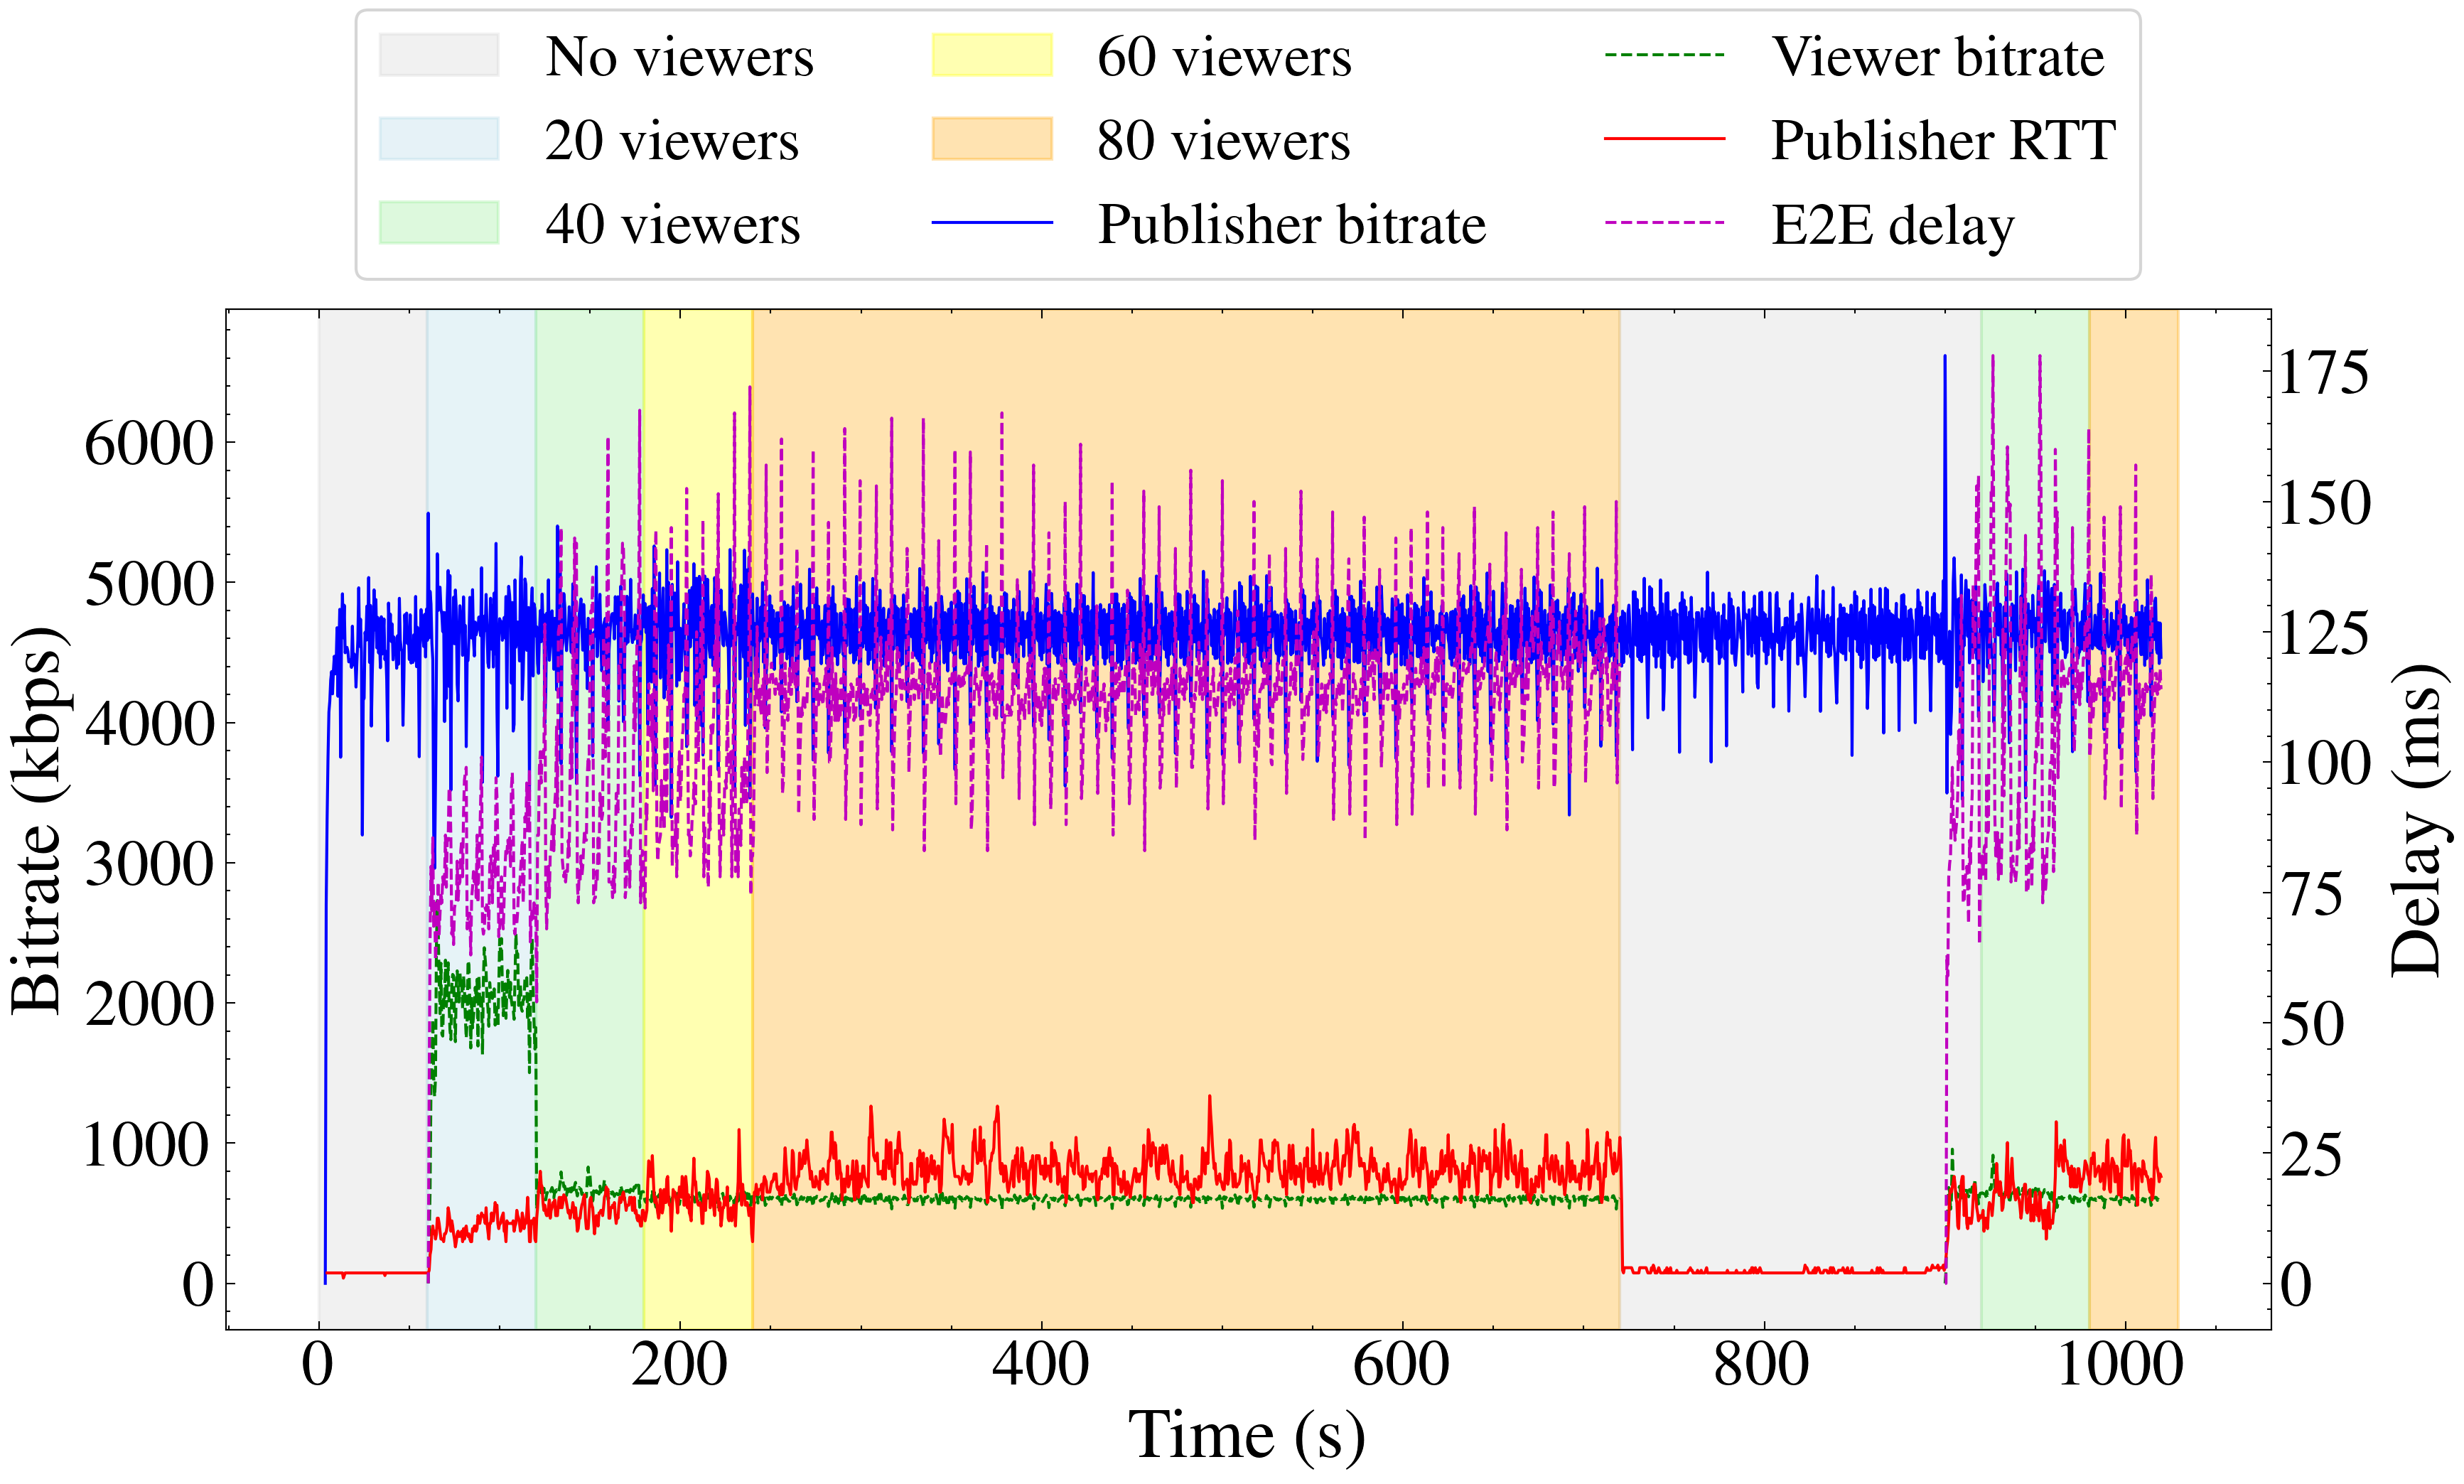

In [38]:
def go_annotate(ax):
    # Annotate the figure with background colors for different phases
    phases = [
        {"start": 0, "end": 60, "color": "lightgray", "label": "No viewers"},
        {"start": 60, "end": 120, "color": "lightblue", "label": "20 viewers"},
        {"start": 120, "end": 180, "color": "lightgreen", "label": "40 viewers"},
        {"start": 180, "end": 240, "color": "yellow", "label": "60 viewers"},
        {"start": 240, "end": 720, "color": "orange", "label": "80 viewers"},
        {"start": 720, "end": 920, "color": "lightgray", "label": None },
        {"start": 920, "end": 980, "color": "lightgreen", "label": None },
        {"start": 980, "end": None, "color": "orange", "label": None },
    ]

    for phase in phases:
        ax.axvspan(
            phase["start"],
            phase["end"] if phase["end"] is not None else ax.get_xlim()[1],
            color=phase["color"],
            alpha=0.3,
            label=phase["label"]
        )

def gen_figs_regul(name, exp):
    query = f"""
    SELECT TIME, MEDIAN("PUBLISHER BITRATE") AS bitrate, MEDIAN("PUBLISHER RTT") AS rtt
    FROM stats
    WHERE exp_name='{exp}'
    GROUP BY TIME
    ORDER BY TIME
    """
    df = con.execute(query).pl()
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    fig.patch.set_alpha(0.0)                                                                                                                                                                        
    ax.set_facecolor('none')

    go_annotate(ax)
    
    bx = ax.twinx()
    
    ax.plot(df["TIME"]/1000, df["bitrate"], label="Publisher bitrate", color='b', linewidth=1)
    bx.plot(df["TIME"]/1000, df["rtt"], label="Publisher RTT", color='r', linewidth=1)
    
    query = f"""
    SELECT time, MEDIAN("bitrate") AS bitrate, MEDIAN("delay") as delay
    FROM viewers
    WHERE exp_name='{exp}'
    GROUP BY time
    ORDER BY time
    """
    df = con.execute(query).pl()
    
    ax.plot(df["time"]/1000, df["bitrate"], label="Viewer bitrate", color='g', linewidth=1)
    bx.plot(df["time"]/1000, df["delay"], label="E2E delay", color='m', linewidth=1)
    
    ax.set_xlabel('Time (s)', fontweight='bold', fontsize=24)
    ax.set_ylabel('Bitrate (kbps)', fontweight='bold', fontsize=24)
    bx.set_ylabel('Delay (ms)', fontweight='bold', fontsize=24)    

    for label in ax.get_xticklabels():
        label.set_fontsize(22)

    for label in ax.get_yticklabels():
        label.set_fontsize(22)

    for label in bx.get_yticklabels():
        label.set_fontsize(22)
    
    # ax.legend(frameon=True)
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, 1.),  bbox_transform=ax.transAxes, frameon=True, ncol=3, fontsize=20) 
    
    plt.tight_layout()
    plt.savefig(f'figure-notebook/{name}.pdf', bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

gen_figs_regul('regul_baseline','noregul-viewer-increase-double-longer-par20')
# gen_figs_regul('regul_balloon','balloon-pid-viewer-increase-double-longer-par20')
# gen_figs_regul('regul_cgroups','cgroups-regul-stddev-30-viewer-double-increase-par20')

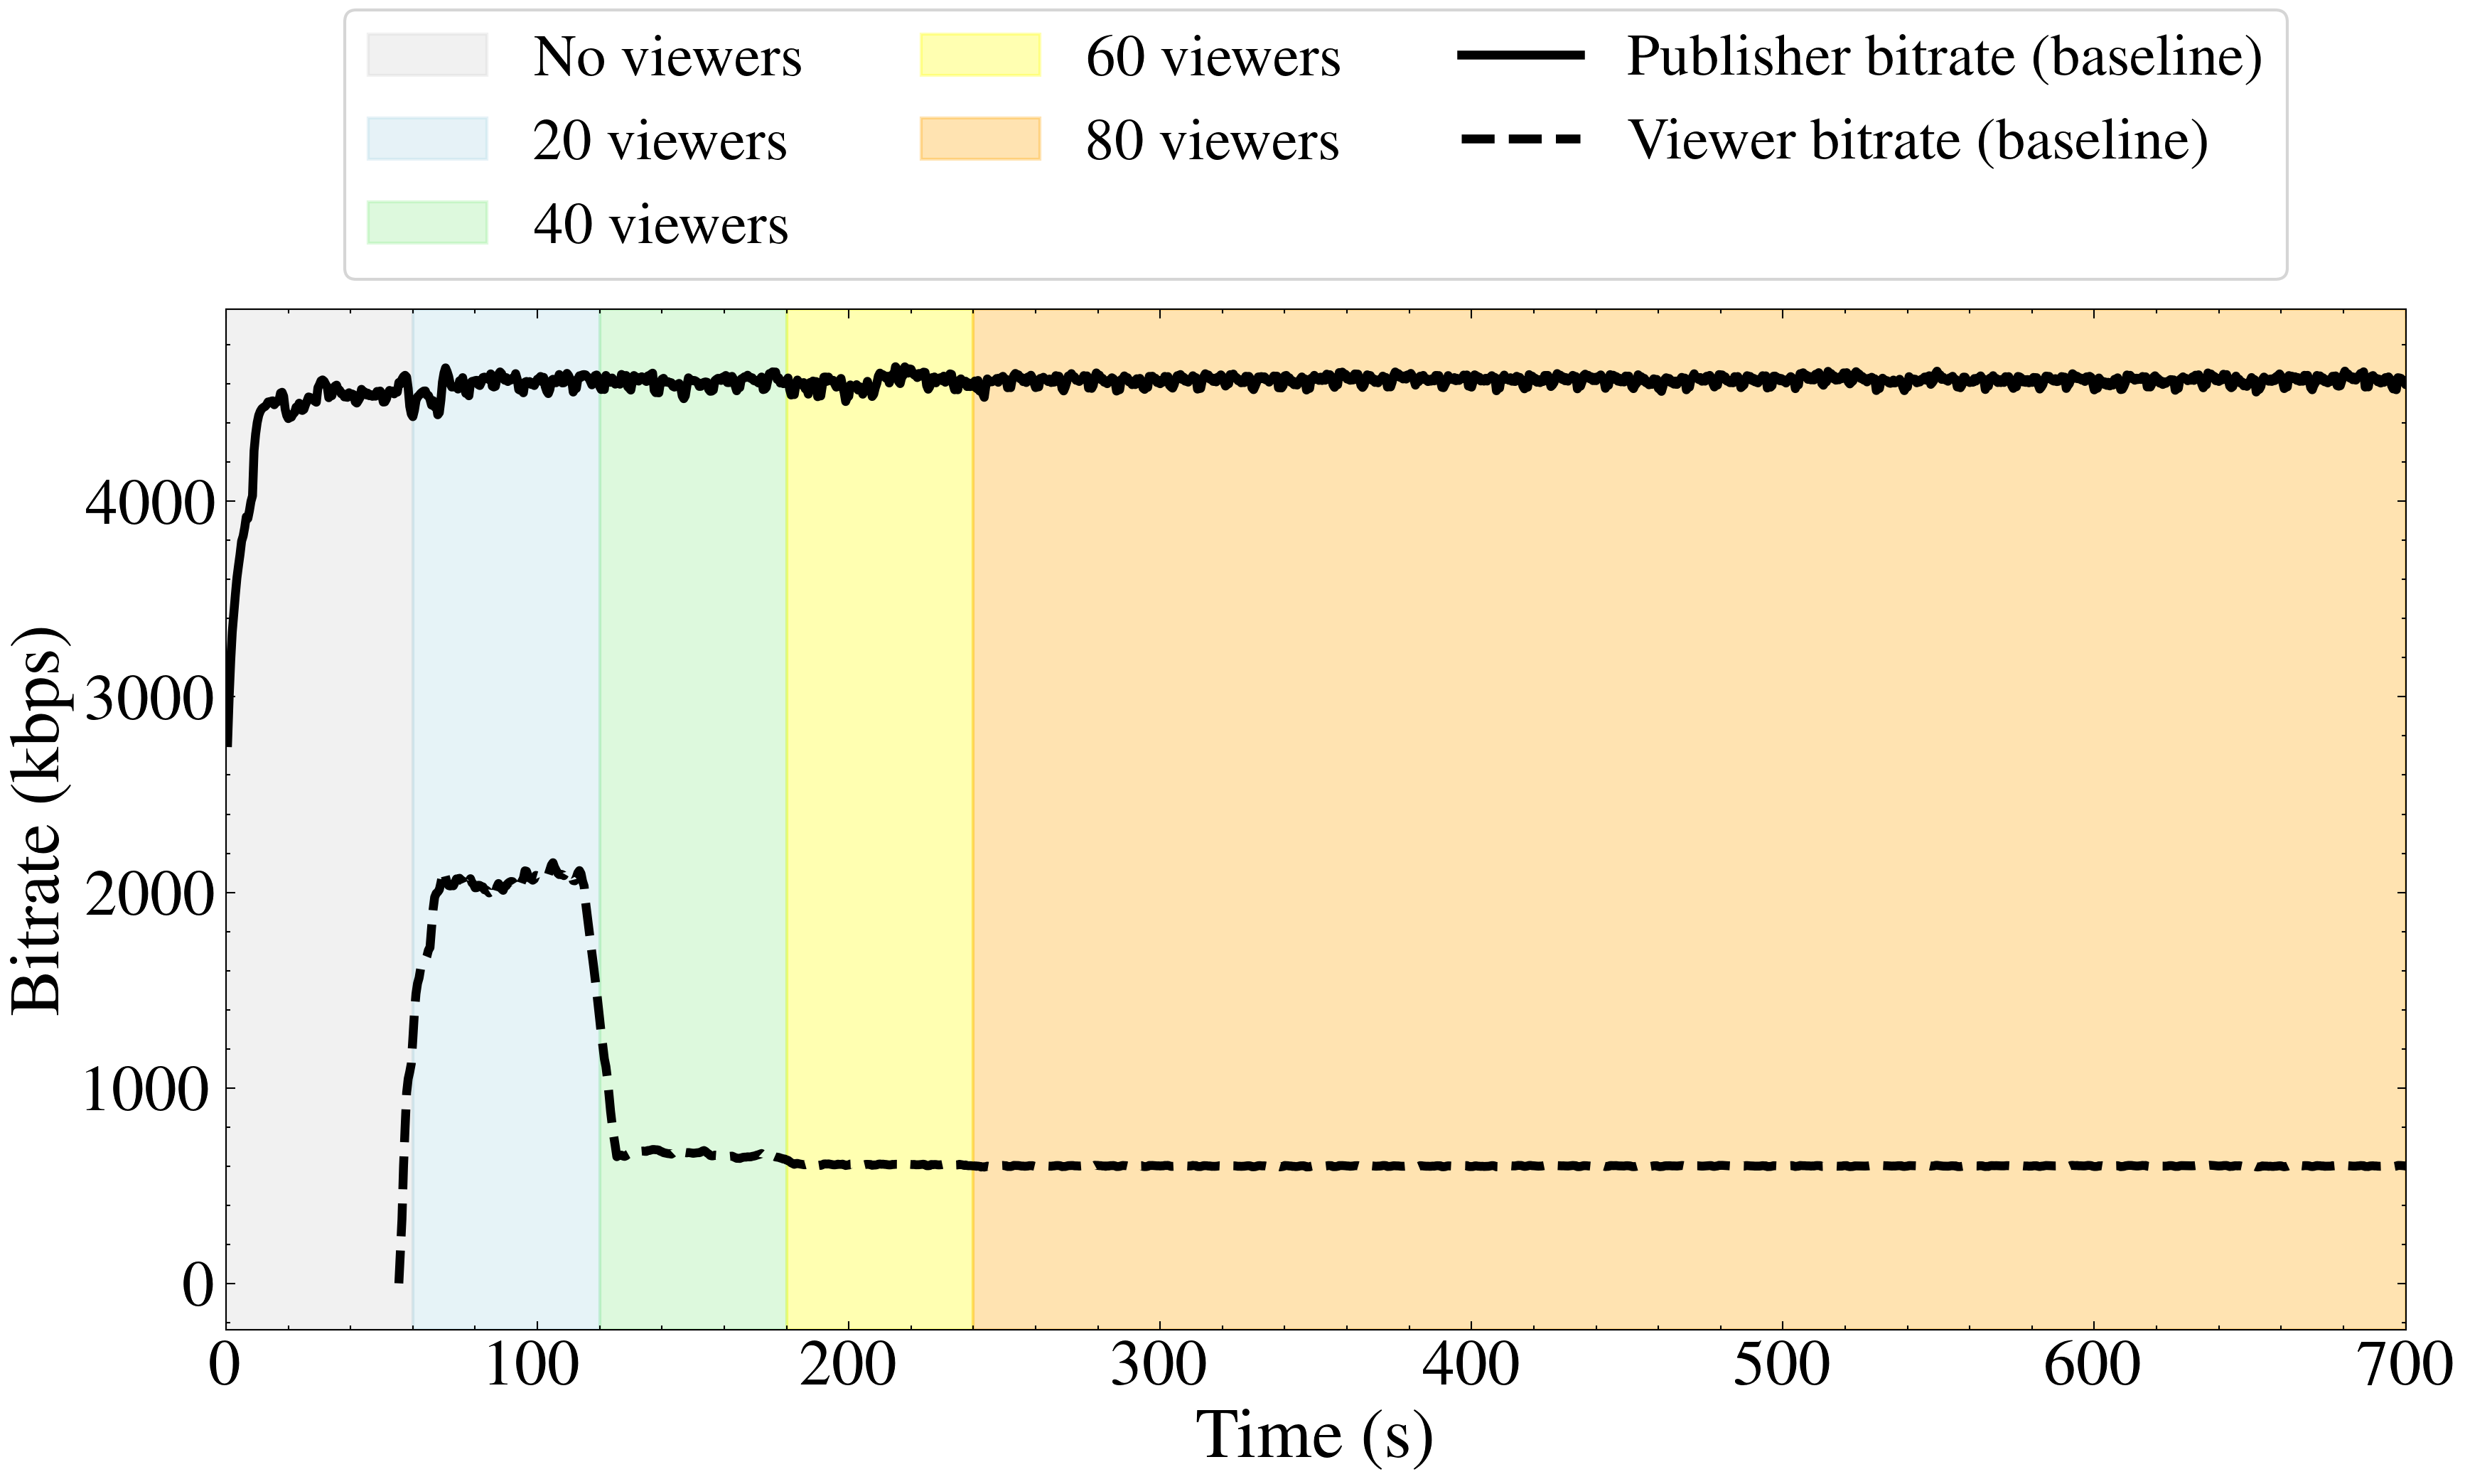

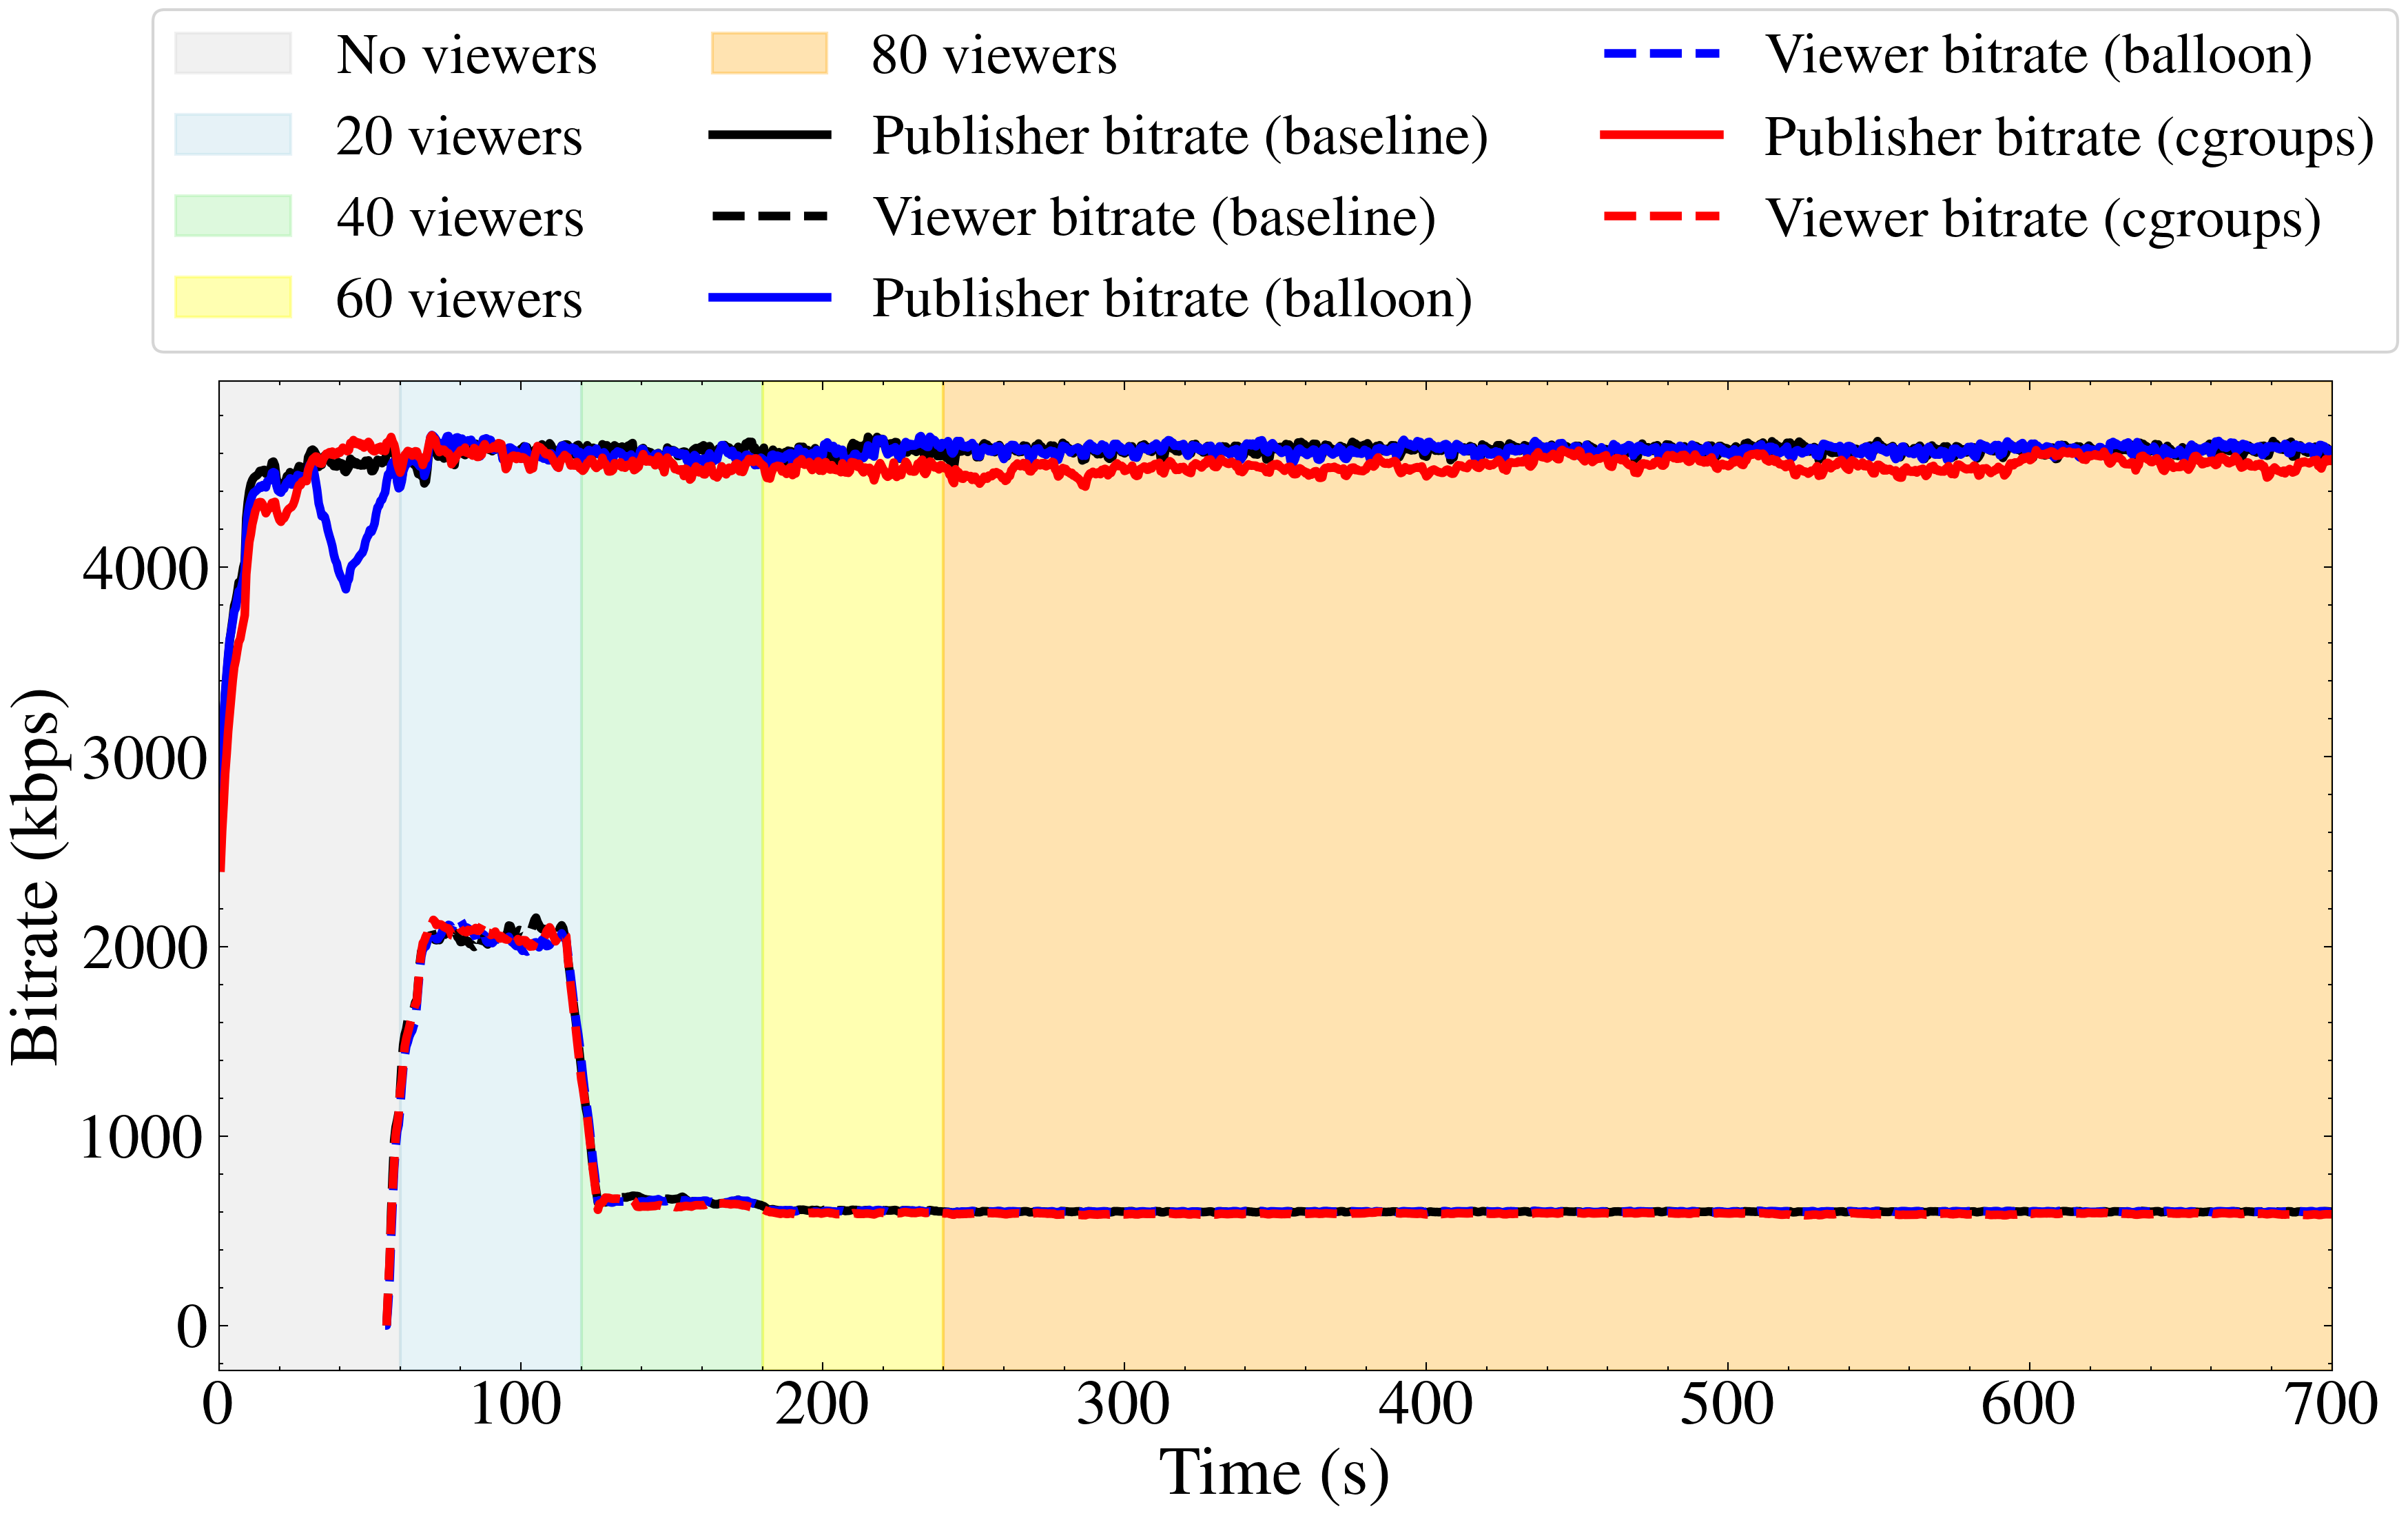

In [185]:
def go_annotate(ax):
    # Annotate the figure with background colors for different phases
    phases = [
        {"start": 0, "end": 60, "color": "lightgray", "label": "No viewers"},
        {"start": 60, "end": 120, "color": "lightblue", "label": "20 viewers"},
        {"start": 120, "end": 180, "color": "lightgreen", "label": "40 viewers"},
        {"start": 180, "end": 240, "color": "yellow", "label": "60 viewers"},
        {"start": 240, "end": 700, "color": "orange", "label": "80 viewers"},
        # {"start": 720, "end": 920, "color": "lightgray", "label": None },
        # {"start": 920, "end": 980, "color": "lightgreen", "label": None },
        # {"start": 980, "end": None, "color": "orange", "label": None },
    ]

    for phase in phases:
        ax.axvspan(
            phase["start"],
            phase["end"] if phase["end"] is not None else ax.get_xlim()[1],
            color=phase["color"],
            alpha=0.3,
            label=phase["label"]
        )

def gen_figs_regul(name, exps):
    smooth_window_sec = 10
    interval_ms = 500
    smooth_window_ms = smooth_window_sec * 1000
    num_rows = int(smooth_window_ms / interval_ms) // 2  # Diviser par 2 pour symétrique

    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
    fig.patch.set_alpha(0.0)                                                                                                                                                                        
    ax.set_facecolor('none')
    go_annotate(ax)

    marker = {
        "noregul": 'x',
        "balloon": 'o',
        "cgroups": '^',
    }

    color = {
        "baseline": 'k',
        "balloon": 'b',
        "cgroups": 'r',
    }

    for exp in exps:
        n = exp.split('-')[0]

        if n == 'noregul':
            n = 'baseline'
        
        query = f"""
            SELECT TIME,
                AVG(bitrate) OVER (ORDER BY TIME ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS bitrate
            FROM (
                SELECT TIME, MEDIAN("PUBLISHER BITRATE") AS bitrate
                FROM stats
                WHERE exp_name='{exp}'
                GROUP BY TIME
            )
            ORDER BY TIME
        """
        df = con.execute(query).pl()
        
        ax.plot(df["TIME"]/1000, df["bitrate"], label=f"Publisher bitrate ({n})", color=color[n], linewidth=3, linestyle='-')
        
        query = f"""
        SELECT time,
                AVG(bitrate) OVER (ORDER BY time ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS bitrate
            FROM (
                SELECT time, MEDIAN("bitrate") AS bitrate
                FROM viewers
                WHERE exp_name='{exp}'
                GROUP BY time
            )
            ORDER BY time
        """
        df = con.execute(query).pl()
        
        ax.plot(df["time"]/1000, df["bitrate"], label=f"Viewer bitrate ({n})", color=color[n], linewidth=3, linestyle='--')

    ax.set_xlim(0,700)
    ax.set_xlabel('Time (s)', fontweight='bold', fontsize=24)
    ax.set_ylabel('Bitrate (kbps)', fontweight='bold', fontsize=24)

    for label in ax.get_xticklabels():
        label.set_fontsize(22)

    for label in ax.get_yticklabels():
        label.set_fontsize(22)

    # ax.legend(frameon=True)
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, 1.),  bbox_transform=ax.transAxes, frameon=True, ncol=3, fontsize=20) 
    
    plt.tight_layout()
    plt.savefig(f'figure-notebook/{name}.pdf', bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

gen_figs_regul('regul_baseline',['noregul-viewer-increase-double-longer-par20'])
gen_figs_regul('regul_all',['noregul-viewer-increase-double-longer-par20', 'balloon-pid-viewer-increase-double-longer-par20', 'cgroups-regul-stddev-30-viewer-double-increase-par20'])
# gen_figs_regul('regul_balloon','balloon-pid-viewer-increase-double-longer-par20')
# gen_figs_regul('regul_cgroups','cgroups-regul-stddev-30-viewer-double-increase-par20')

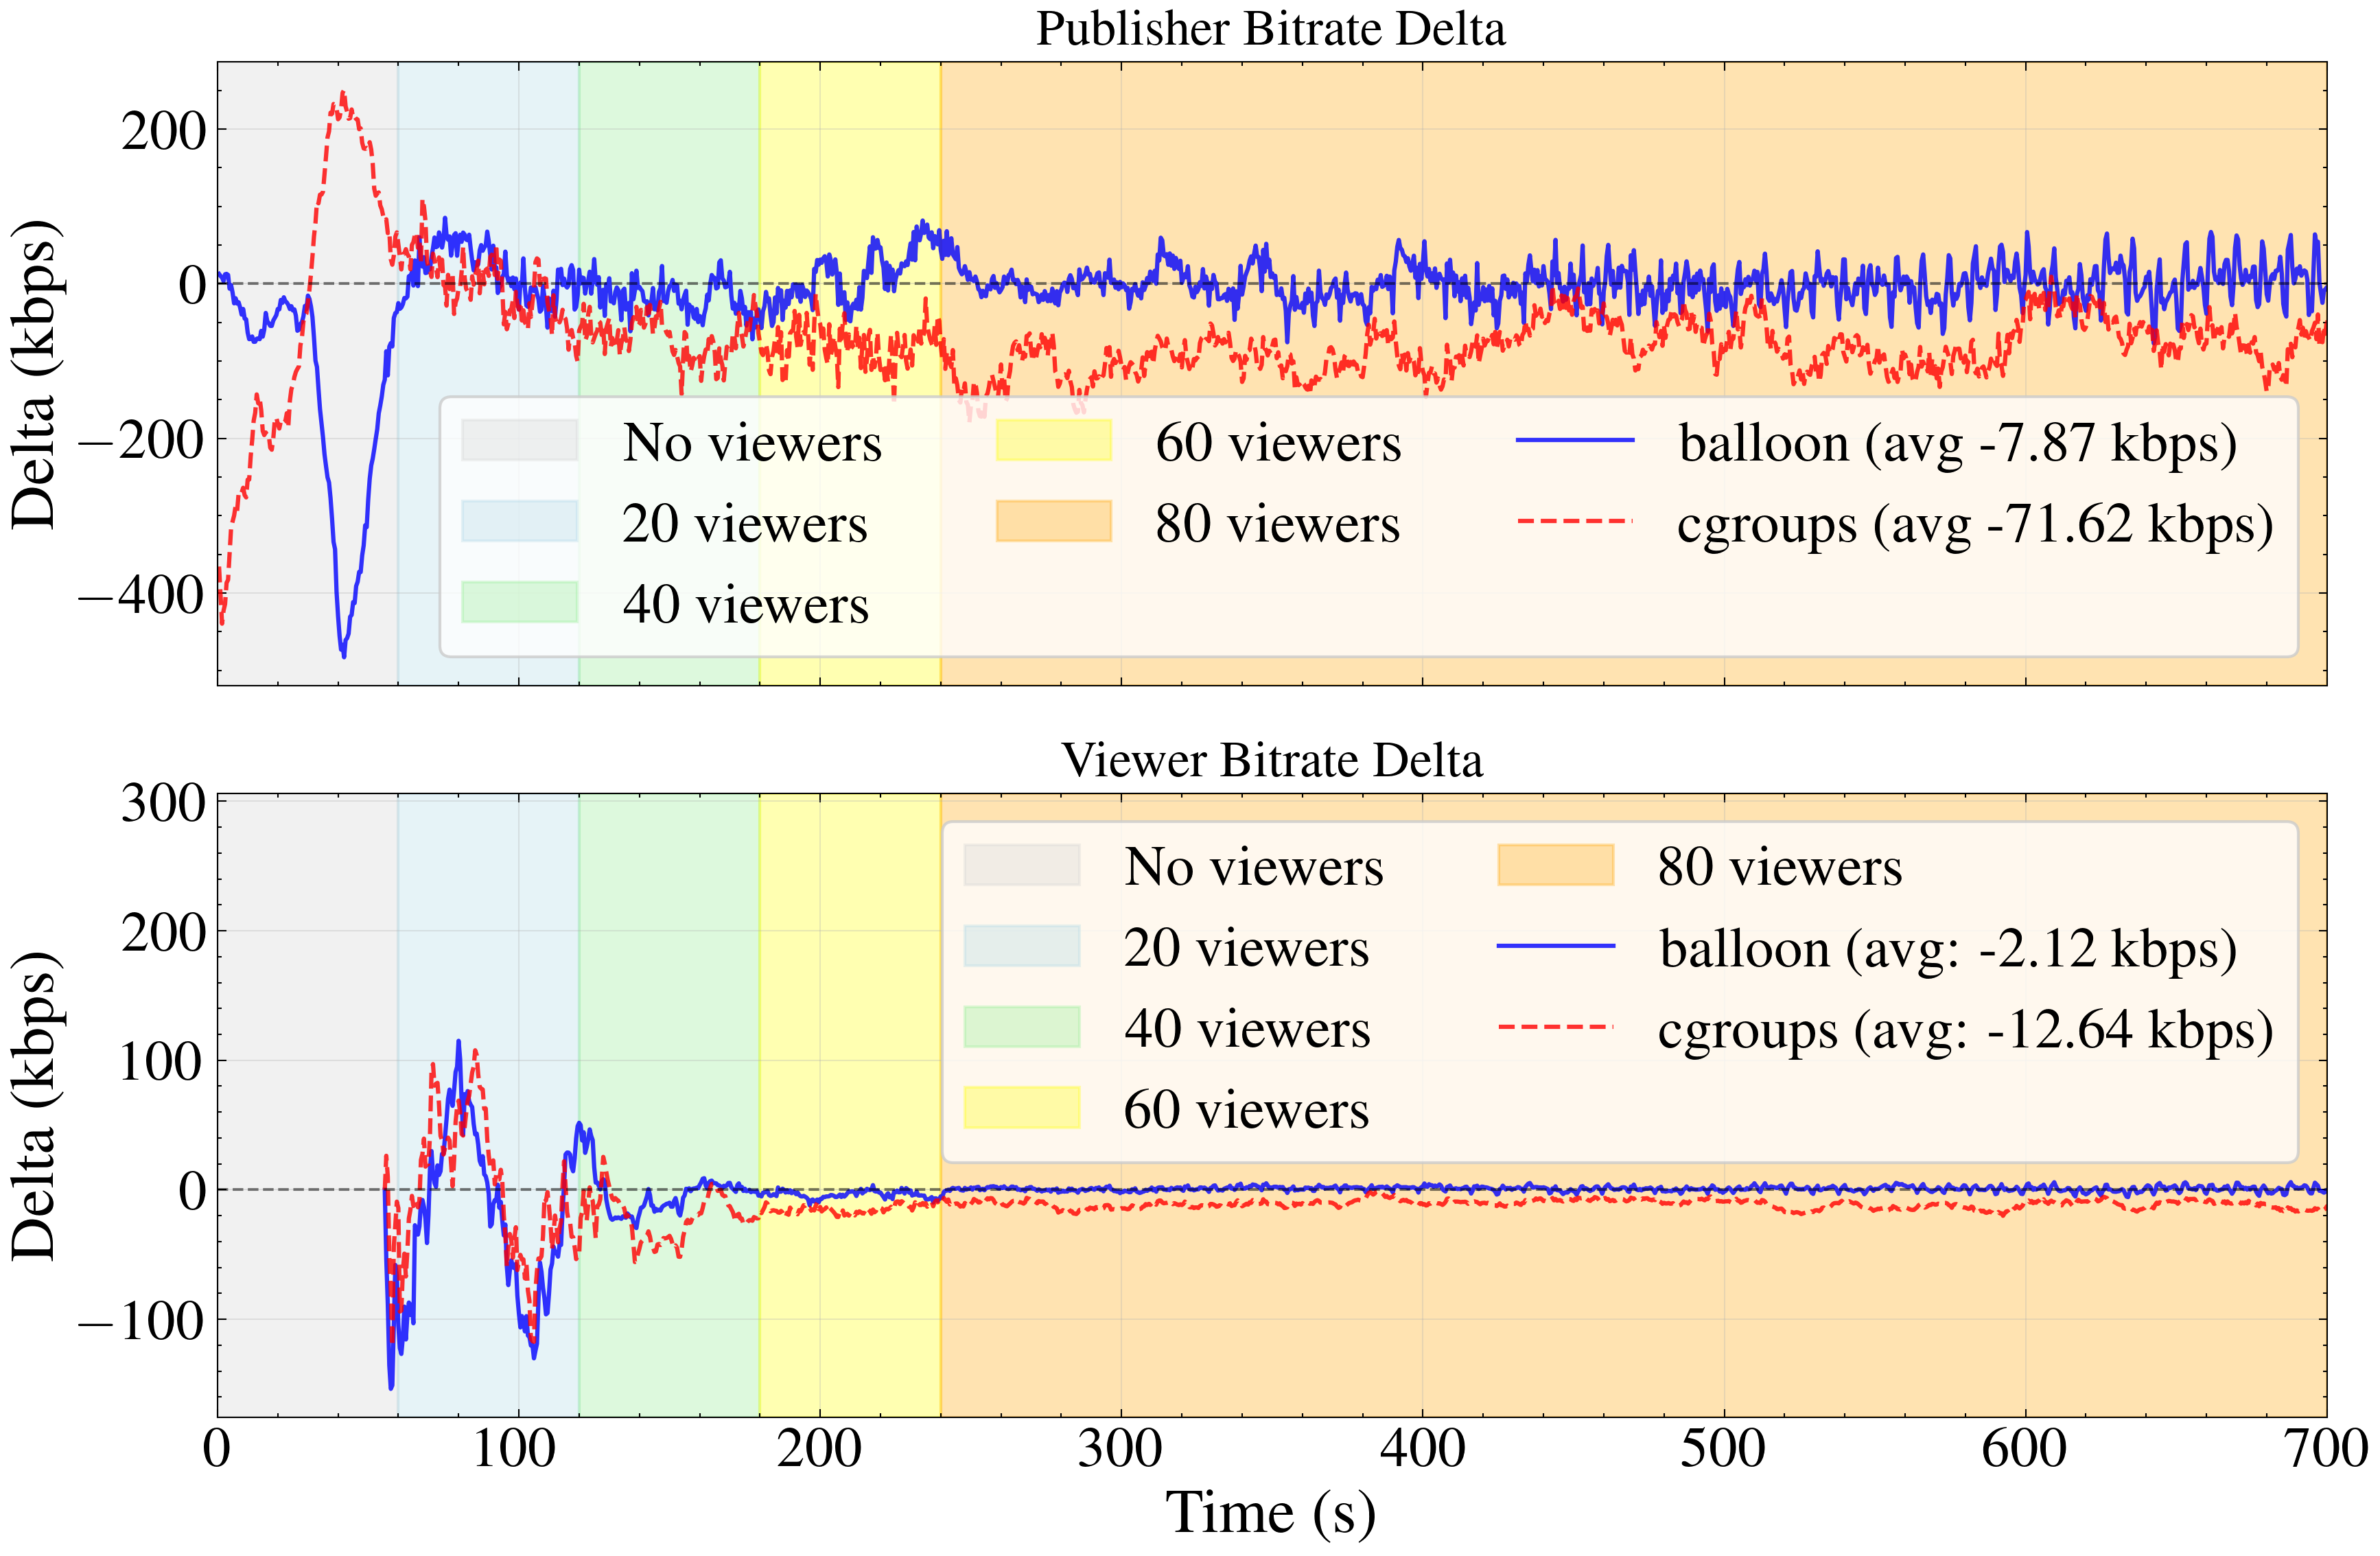

In [194]:
def gen_figs_delta(name, baseline_exp, other_exps, smooth_window_sec=10, interval_ms=500):
    """
    Génère un plot delta (baseline vs autres expériences).
    Affiche SEULEMENT les deltas (pas la baseline).
    4 métriques: Publisher bitrate, Viewer bitrate, Publisher RTT, E2E delay
    
    smooth_window_sec: fenêtre de lissage en secondes (défaut: 10)
    interval_ms: interval entre les échantillons en ms (défaut: 500)
    """
    
    # Calculer le nombre de lignes pour la fenêtre glissante
    smooth_window_ms = smooth_window_sec * 1000
    num_rows = int(smooth_window_ms / interval_ms) // 2  # Diviser par 2 pour symétrique
    
    # Récupérer les données baseline (stats) LISSÉES
    query_baseline_stats = f"""
    SELECT TIME, 
        AVG(bitrate) OVER (ORDER BY TIME ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS bitrate,
        AVG(rtt) OVER (ORDER BY TIME ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS rtt
    FROM (
        SELECT TIME, AVG("PUBLISHER BITRATE") AS bitrate, MEDIAN("PUBLISHER RTT") AS rtt
        FROM stats
        WHERE exp_name='{baseline_exp}'
        GROUP BY TIME
    )
    ORDER BY TIME
    """
    df_baseline_stats = con.execute(query_baseline_stats).pl()
    
    # Récupérer les données baseline (viewers) LISSÉES
    query_baseline_viewers = f"""
    SELECT time,
        AVG(bitrate) OVER (ORDER BY time ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS bitrate,
        AVG(delay) OVER (ORDER BY time ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS delay
    FROM (
        SELECT time, MEDIAN("bitrate") AS bitrate, MEDIAN("delay") as delay
        FROM viewers
        WHERE exp_name='{baseline_exp}'
        GROUP BY time
    )
    ORDER BY time
    """
    df_baseline_viewers = con.execute(query_baseline_viewers).pl()
    
    # Figure 4 subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), dpi=300, sharex=True)
    fig.patch.set_alpha(0.0)
    
    for ax in axes:
        ax.set_facecolor('none')
    
    # Couleurs pour chaque expérience
    colors = {'balloon': 'b', 'cgroups': 'r'}
    
    # ========== Subplot 1: Publisher Bitrate Delta ==========
    ax = axes[0]
    go_annotate(ax)
    for exp in other_exps:
        query_stats = f"""
        SELECT TIME,
            AVG(bitrate) OVER (ORDER BY TIME ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS bitrate
        FROM (
            SELECT TIME, MEDIAN("PUBLISHER BITRATE") AS bitrate
            FROM stats
            WHERE exp_name='{exp}'
            GROUP BY TIME
        )
        ORDER BY TIME
        """
        df_stats = con.execute(query_stats).pl()
        
        min_len = min(len(df_baseline_stats), len(df_stats))
        delta = (df_stats["bitrate"][:min_len].to_numpy() - 
                df_baseline_stats["bitrate"][:min_len].to_numpy())
        
        # Supprimer les NaN pour le calcul de la moyenne
        delta_clean = delta[~np.isnan(delta)]
        mean_delta = np.mean(delta_clean) if len(delta_clean) > 0 else 0
        
        exp_label = 'balloon' if 'balloon' in exp else 'cgroups' if 'cgroups' in exp else exp
        color = colors.get(exp_label, 'gray')
        ax.plot(df_baseline_stats["TIME"][:min_len]/1000, delta, 
                label=f'{exp_label} (avg {mean_delta:.2f} kbps)', color=color, linewidth=1.5, alpha=0.8)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Delta (kbps)', fontweight='bold', fontsize=22)
    ax.set_title(f'Publisher Bitrate Delta', fontweight='bold', fontsize=18)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=20, loc='lower right', frameon=True, ncol=3)
    ax.set_xlim(0,700)
    
    # ========== Subplot 2: Viewer Bitrate Delta ==========
    ax = axes[1]
    go_annotate(ax)
    for exp in other_exps:
        query_viewers = f"""
        SELECT time,
            AVG(bitrate) OVER (ORDER BY time ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS bitrate
        FROM (
            SELECT time, MEDIAN("bitrate") AS bitrate
            FROM viewers
            WHERE exp_name='{exp}'
            GROUP BY time
        )
        ORDER BY time
        """
        df_viewers = con.execute(query_viewers).pl()
        
        min_len = min(len(df_baseline_viewers), len(df_viewers))
        delta = (df_viewers["bitrate"][:min_len].to_numpy() - 
                df_baseline_viewers["bitrate"][:min_len].to_numpy())
        
        # Supprimer les NaN pour le calcul de la moyenne
        delta_clean = delta[~np.isnan(delta)]
        mean_delta = np.mean(delta_clean) if len(delta_clean) > 0 else 0
        
        exp_label = 'balloon' if 'balloon' in exp else 'cgroups' if 'cgroups' in exp else exp
        color = colors.get(exp_label, 'gray')
        ax.plot(df_baseline_viewers["time"][:min_len]/1000, delta, 
                label=f'{exp_label} (avg: {mean_delta:.2f} kbps)', color=color, linewidth=1.5, alpha=0.8)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Delta (kbps)', fontweight='bold', fontsize=22)
    ax.set_title(f'Viewer Bitrate Delta', fontweight='bold', fontsize=18)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=20, loc='upper right', frameon=True, ncol=2)
    ax.set_xlabel('Time (s)', fontweight='bold', fontsize=22)
    ax.set_xlim(0,700)
    
    # ========== Subplot 3: Publisher RTT Delta ==========
    # ax = axes[2]
    # for exp in other_exps:
    #     query_stats = f"""
    #     SELECT TIME,
    #         AVG(rtt) OVER (ORDER BY TIME ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS rtt
    #     FROM (
    #         SELECT TIME, MEDIAN("PUBLISHER RTT") AS rtt
    #         FROM stats
    #         WHERE exp_name='{exp}'
    #         GROUP BY TIME
    #     )
    #     ORDER BY TIME
    #     """
    #     df_stats = con.execute(query_stats).pl()
        
    #     min_len = min(len(df_baseline_stats), len(df_stats))
    #     delta = (df_stats["rtt"][:min_len].to_numpy() - 
    #             df_baseline_stats["rtt"][:min_len].to_numpy())
        
    #     # Supprimer les NaN pour le calcul de la moyenne
    #     delta_clean = delta[~np.isnan(delta)]
    #     mean_delta = np.mean(delta_clean) if len(delta_clean) > 0 else 0
        
    #     exp_label = 'balloon' if 'balloon' in exp else 'cgroups' if 'cgroups' in exp else exp
    #     color = colors.get(exp_label, 'gray')
    #     ax.plot(df_baseline_stats["TIME"][:min_len]/1000, delta, 
    #             label=f'{exp_label} (avg: {mean_delta:.2f} ms)', color=color, linewidth=1.5, alpha=0.8)
    
    # ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # ax.set_ylabel('Delta (ms)', fontweight='bold', fontsize=22)
    # ax.set_xlabel('Time (s)', fontweight='bold', fontsize=22)
    # ax.set_title(f'Publisher RTT Delta', fontweight='bold', fontsize=18)
    # ax.grid(alpha=0.3)
    # ax.legend(fontsize=20, loc='upper left', frameon=True, ncol=2)
    
    # ========== Subplot 4: E2E Delay Delta ==========
    # ax = axes[3]
    # for exp in other_exps:
    #     query_viewers = f"""
    #     SELECT time,
    #         AVG(delay) OVER (ORDER BY time ROWS BETWEEN {num_rows} PRECEDING AND {num_rows} FOLLOWING) AS delay
    #     FROM (
    #         SELECT time, MEDIAN("delay") AS delay
    #         FROM viewers
    #         WHERE exp_name='{exp}'
    #         GROUP BY time
    #     )
    #     ORDER BY time
    #     """
    #     df_viewers = con.execute(query_viewers).pl()
        
    #     min_len = min(len(df_baseline_viewers), len(df_viewers))
    #     delta = (df_viewers["delay"][:min_len].to_numpy() - 
    #             df_baseline_viewers["delay"][:min_len].to_numpy())
        
    #     # Supprimer les NaN pour le calcul de la moyenne
    #     delta_clean = delta[~np.isnan(delta)]
    #     mean_delta = np.mean(delta_clean) if len(delta_clean) > 0 else 0
        
    #     exp_label = 'balloon' if 'balloon' in exp else 'cgroups' if 'cgroups' in exp else exp
    #     color = colors.get(exp_label, 'gray')
    #     ax.plot(df_baseline_viewers["time"][:min_len]/1000, delta, 
    #             label=f'{exp_label} (avg: {mean_delta:.2f} ms)', color=color, linewidth=1.5, alpha=0.8)
    
    # ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    # ax.set_xlabel('Time (s)', fontweight='bold', fontsize=22)
    # ax.set_ylabel('Delta (ms)', fontweight='bold', fontsize=22)
    # ax.set_title(f'E2E Delay Delta', fontweight='bold', fontsize=18)
    # ax.grid(alpha=0.3)
    # ax.legend(fontsize=20, loc='upper left', frameon=True, ncol=2)

    
    
    # Ticks
    for ax in axes:
        for label in ax.get_xticklabels():
            label.set_fontsize(20)
        for label in ax.get_yticklabels():
            label.set_fontsize(20)
    
    plt.tight_layout()
    plt.savefig(f'figure-notebook/{name}.pdf', bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

# Appel
gen_figs_delta(
    'delta_regul_smooth10',
    baseline_exp='noregul-viewer-increase-double-longer-par20',
    other_exps=[
        'balloon-pid-viewer-increase-double-longer-par20',
        'cgroups-regul-stddev-30-viewer-double-increase-par20'
    ],
    smooth_window_sec=10,
    interval_ms=500
)

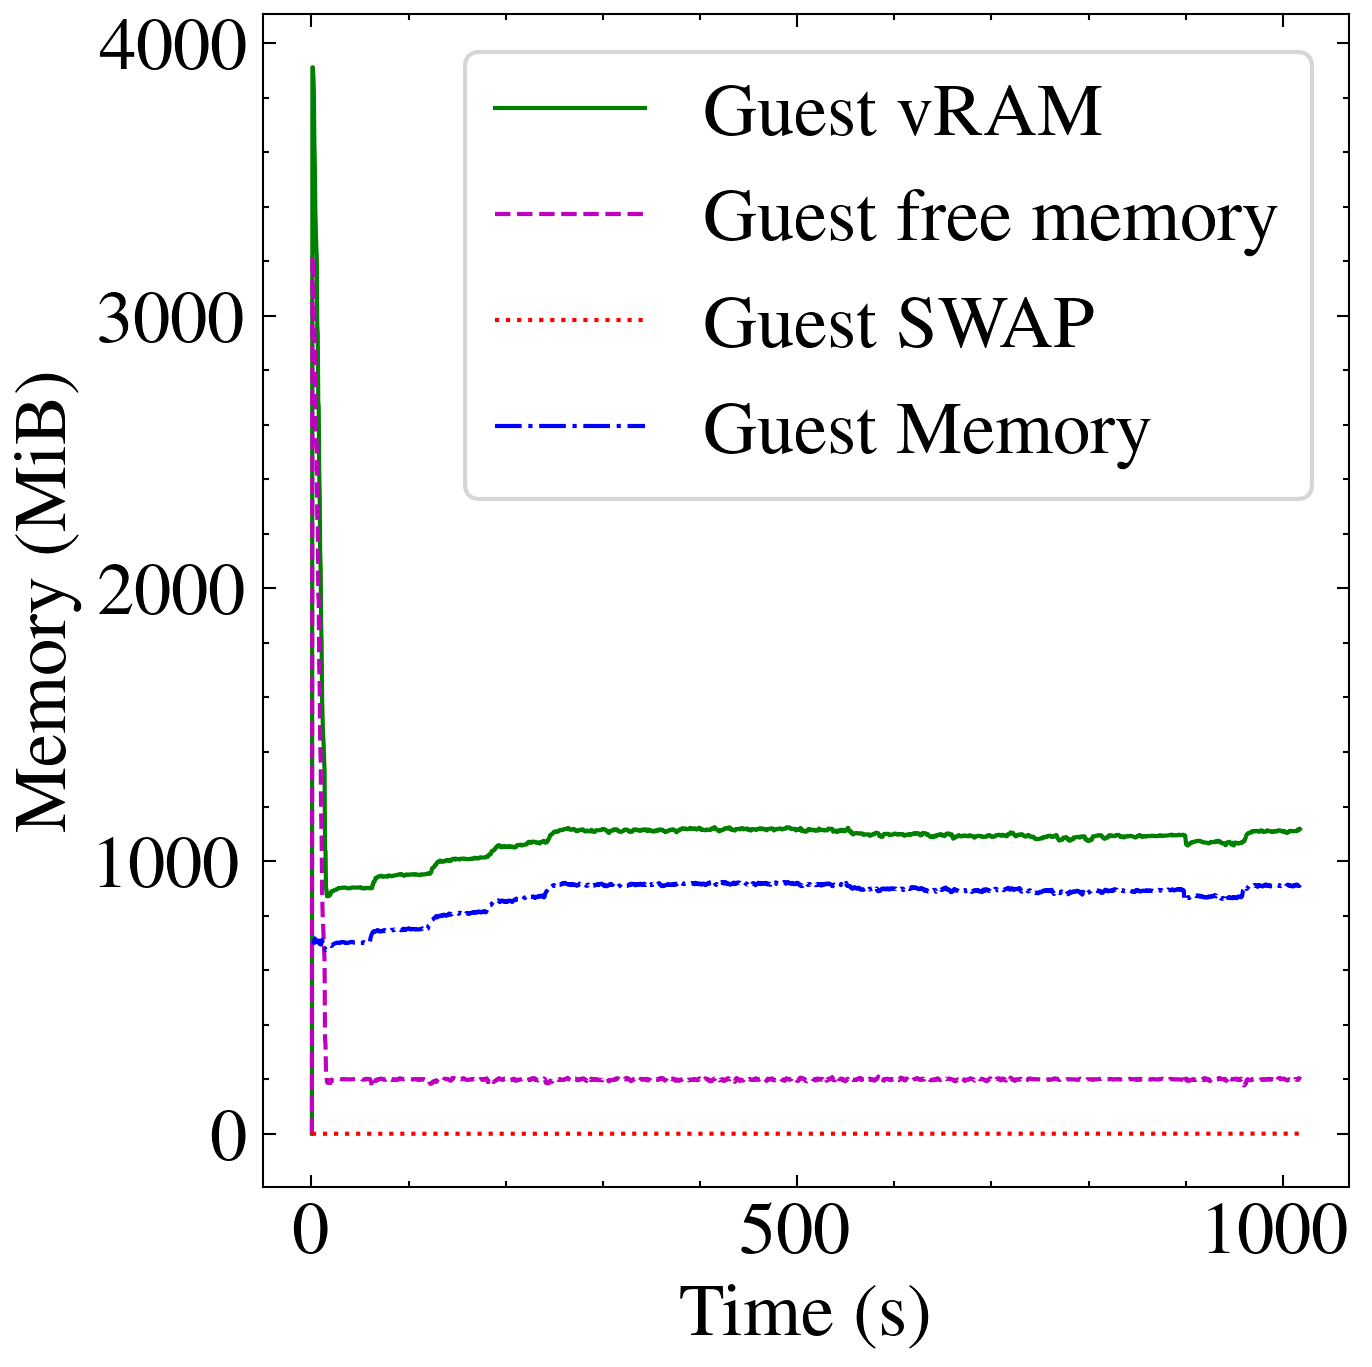

In [50]:
query = """
SELECT TIME, 
       MEDIAN("VIRSH AVAILABLE") AS "Guest vRAM",
       MEDIAN("VIRSH USABLE") AS "Guest free memory",
       MEDIAN("VIRSH SWAP OUT") AS "Guest SWAP",
       MEDIAN("VM MEMORY USAGE") AS "Guest Memory"
FROM stats
WHERE exp_name='balloon-pid-viewer-increase-double-longer-par20'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["Guest vRAM"]/(1024), label="Guest vRAM", color='g', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest free memory"]/(1024), label="Guest free memory", color='m', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest SWAP"]/(1024), label="Guest SWAP", color='r', linewidth=1)
ax.plot(df["TIME"]/1000, df["Guest Memory"], label="Guest Memory", color='b', linewidth=1)
    
ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')

ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/ballon_memory.pdf', bbox_inches='tight', dpi=300)
plt.show()

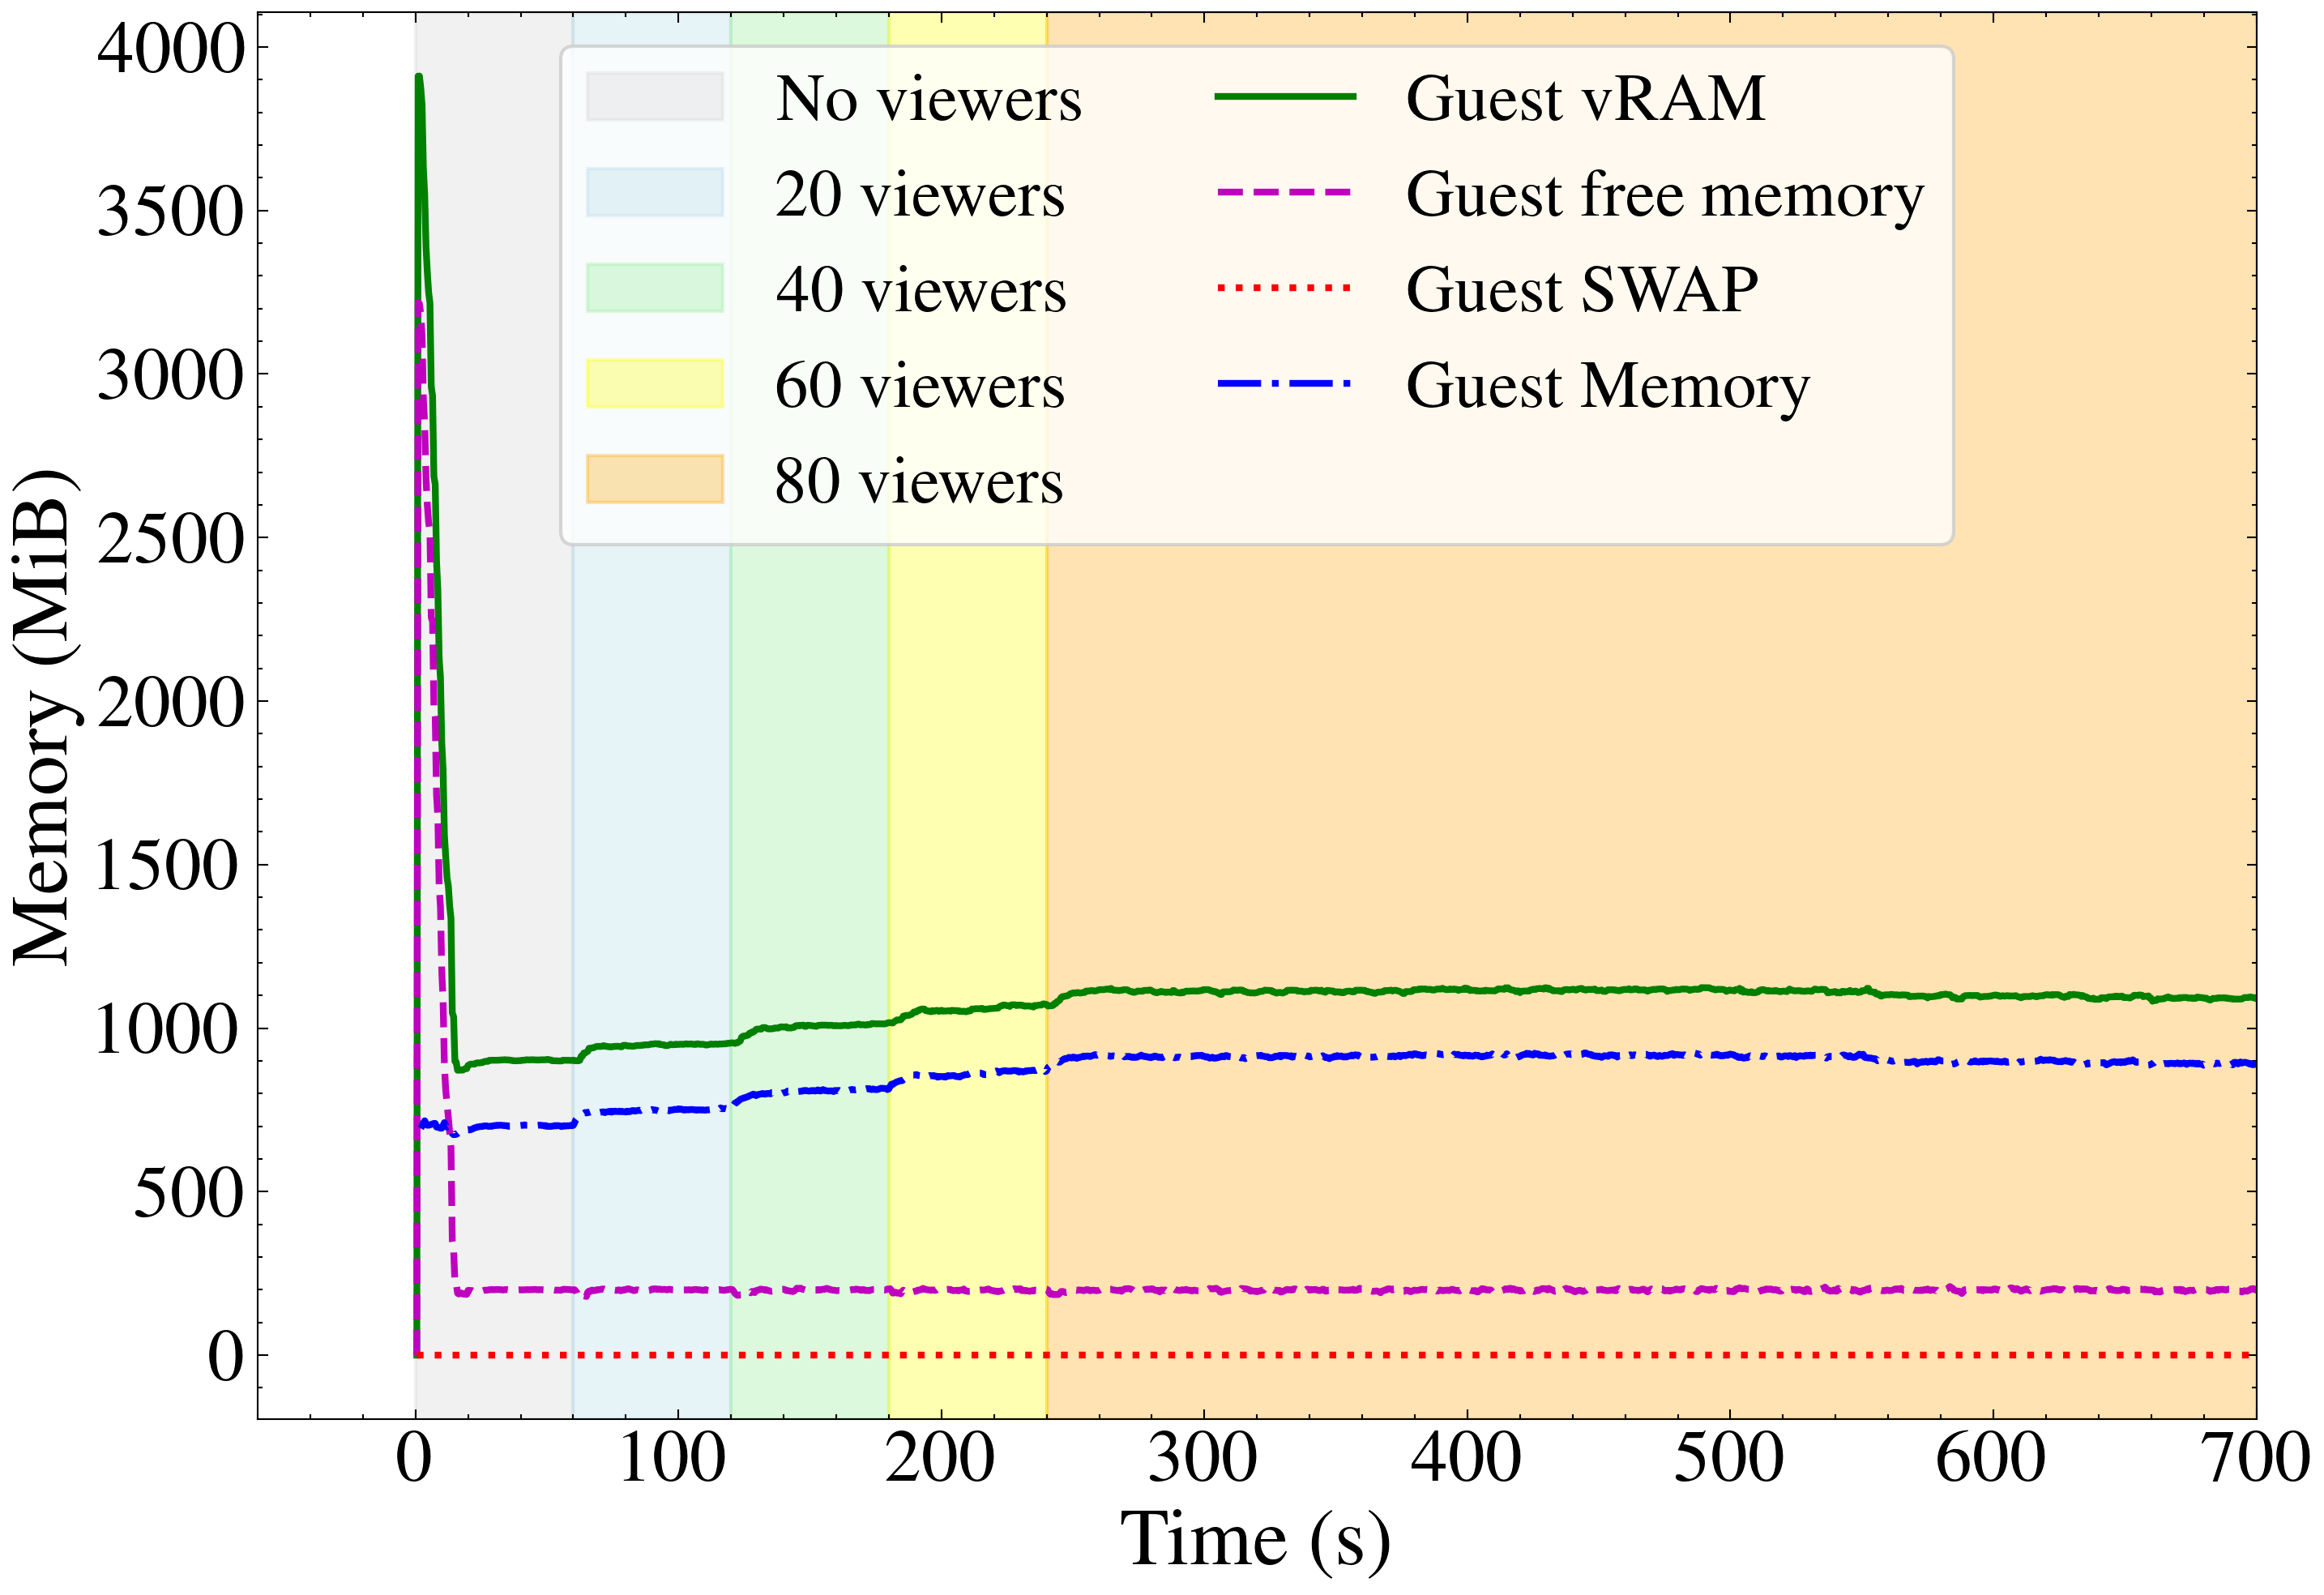

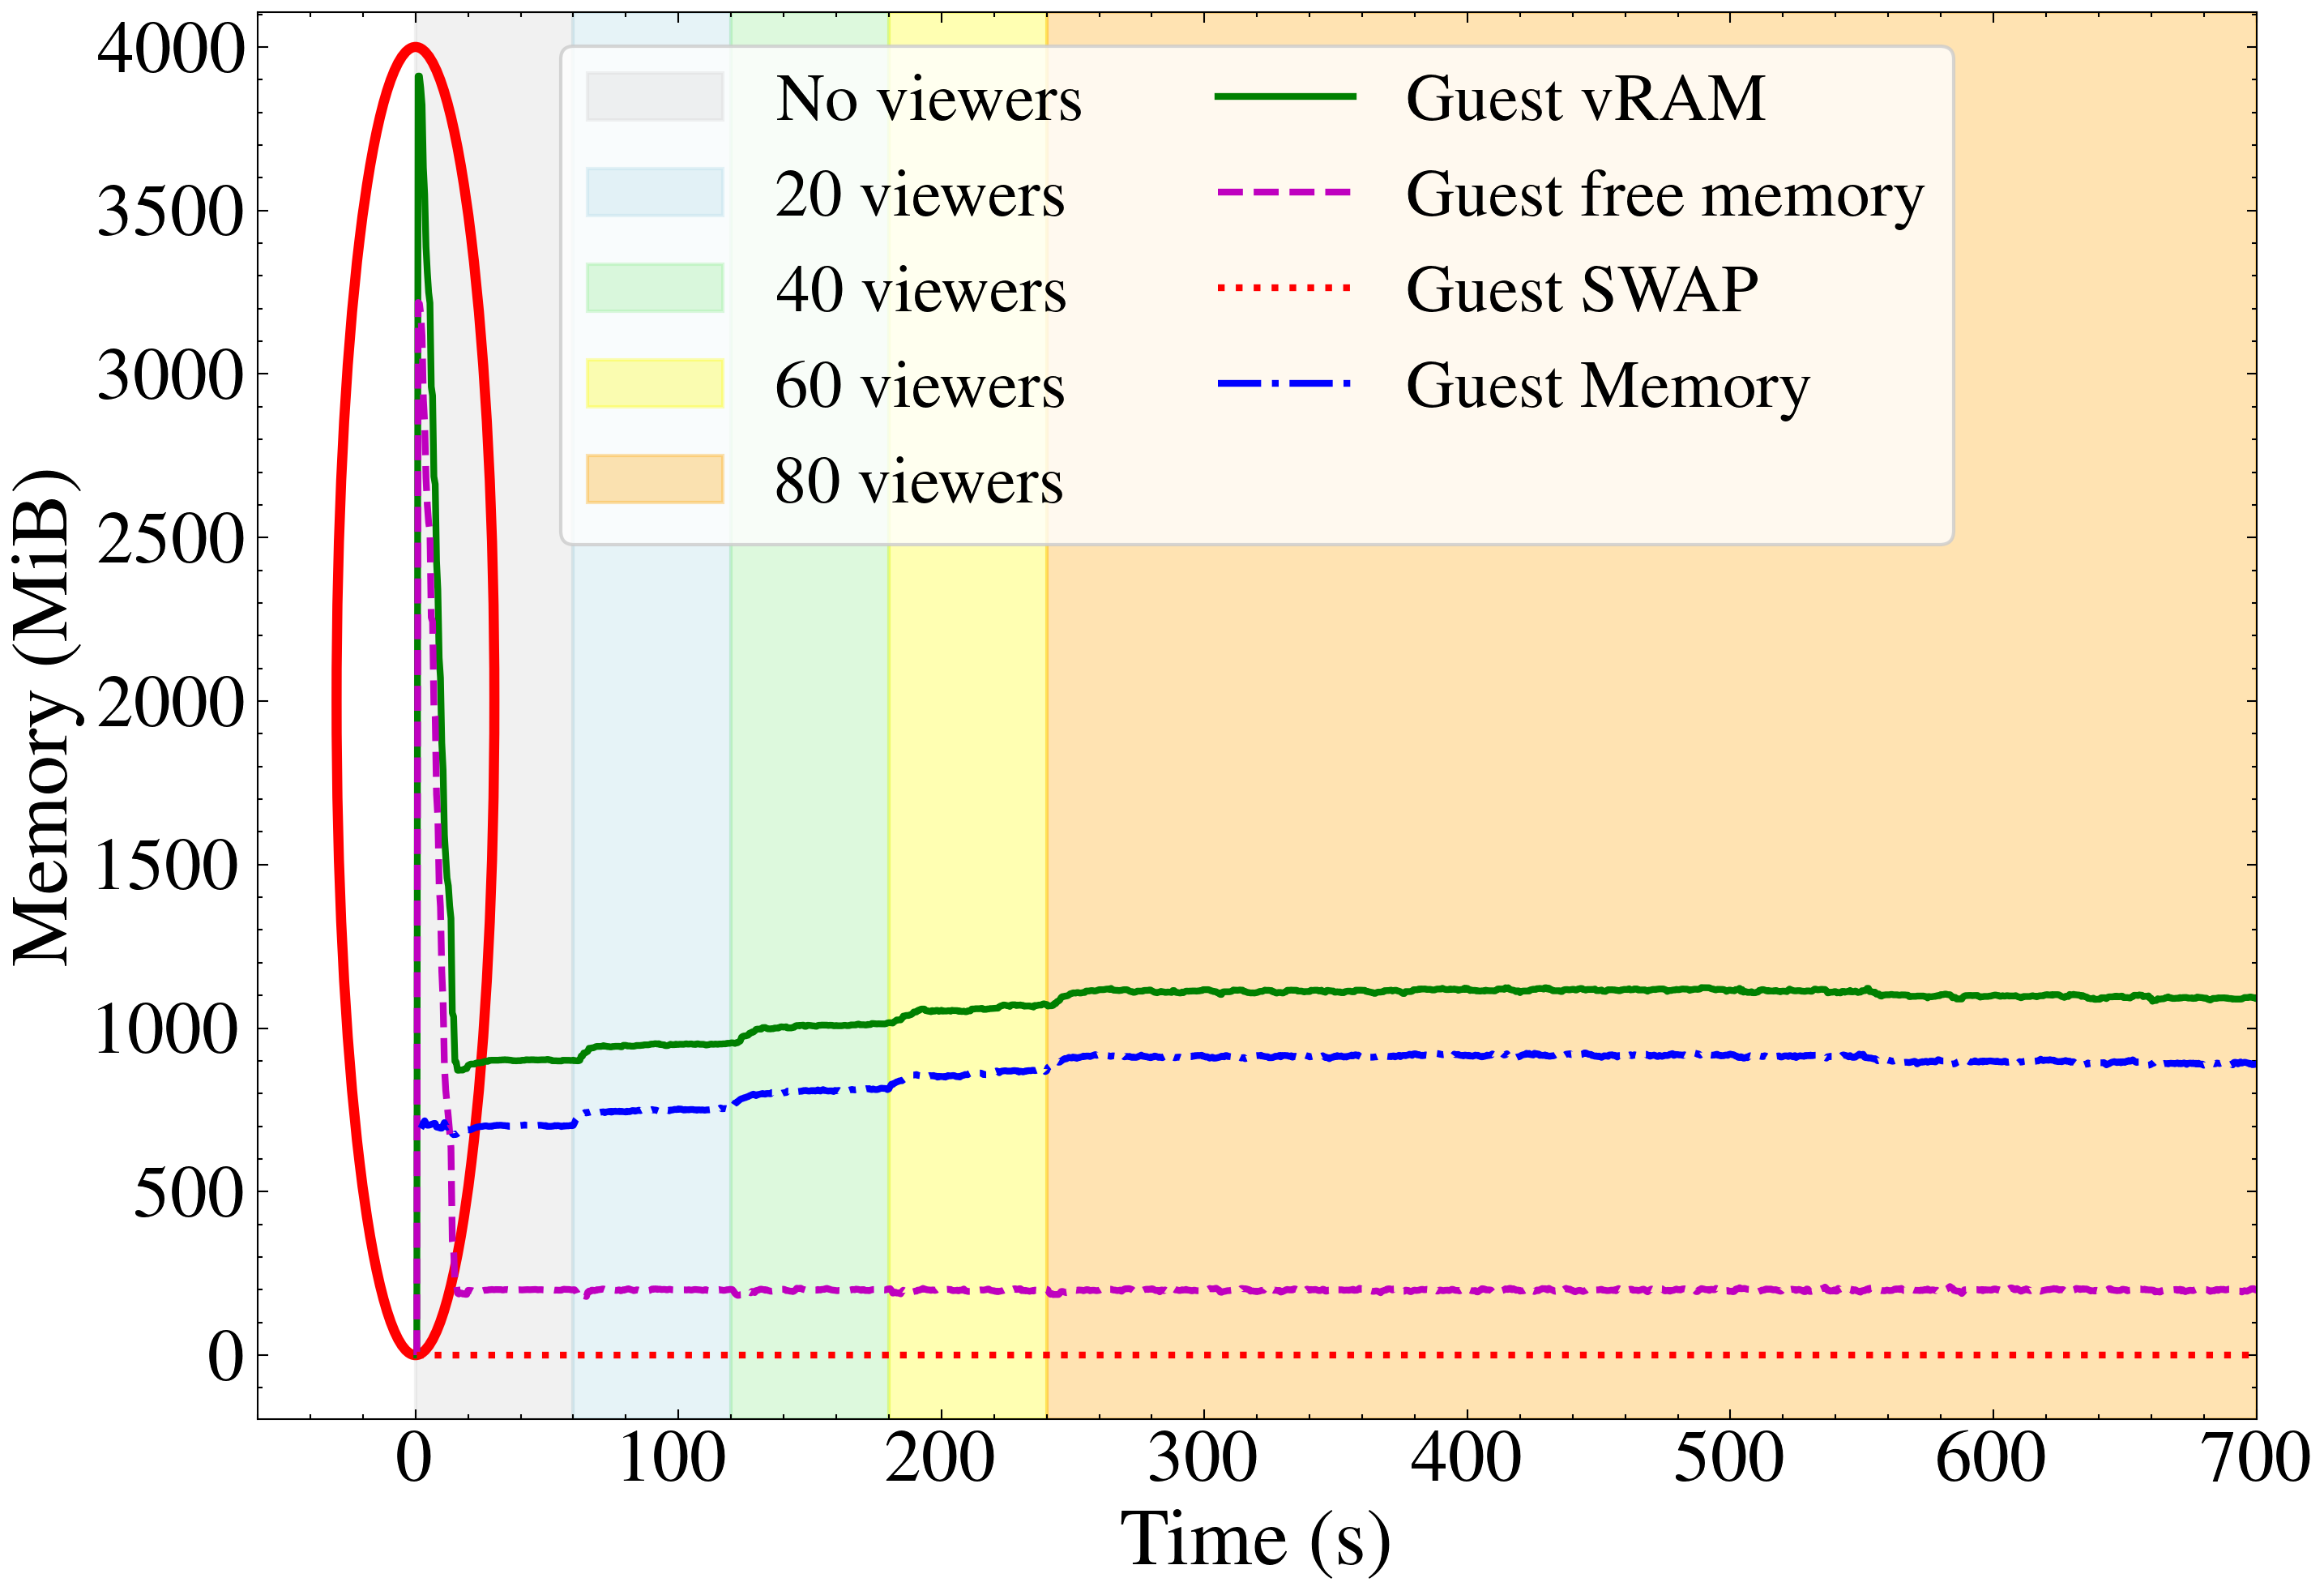

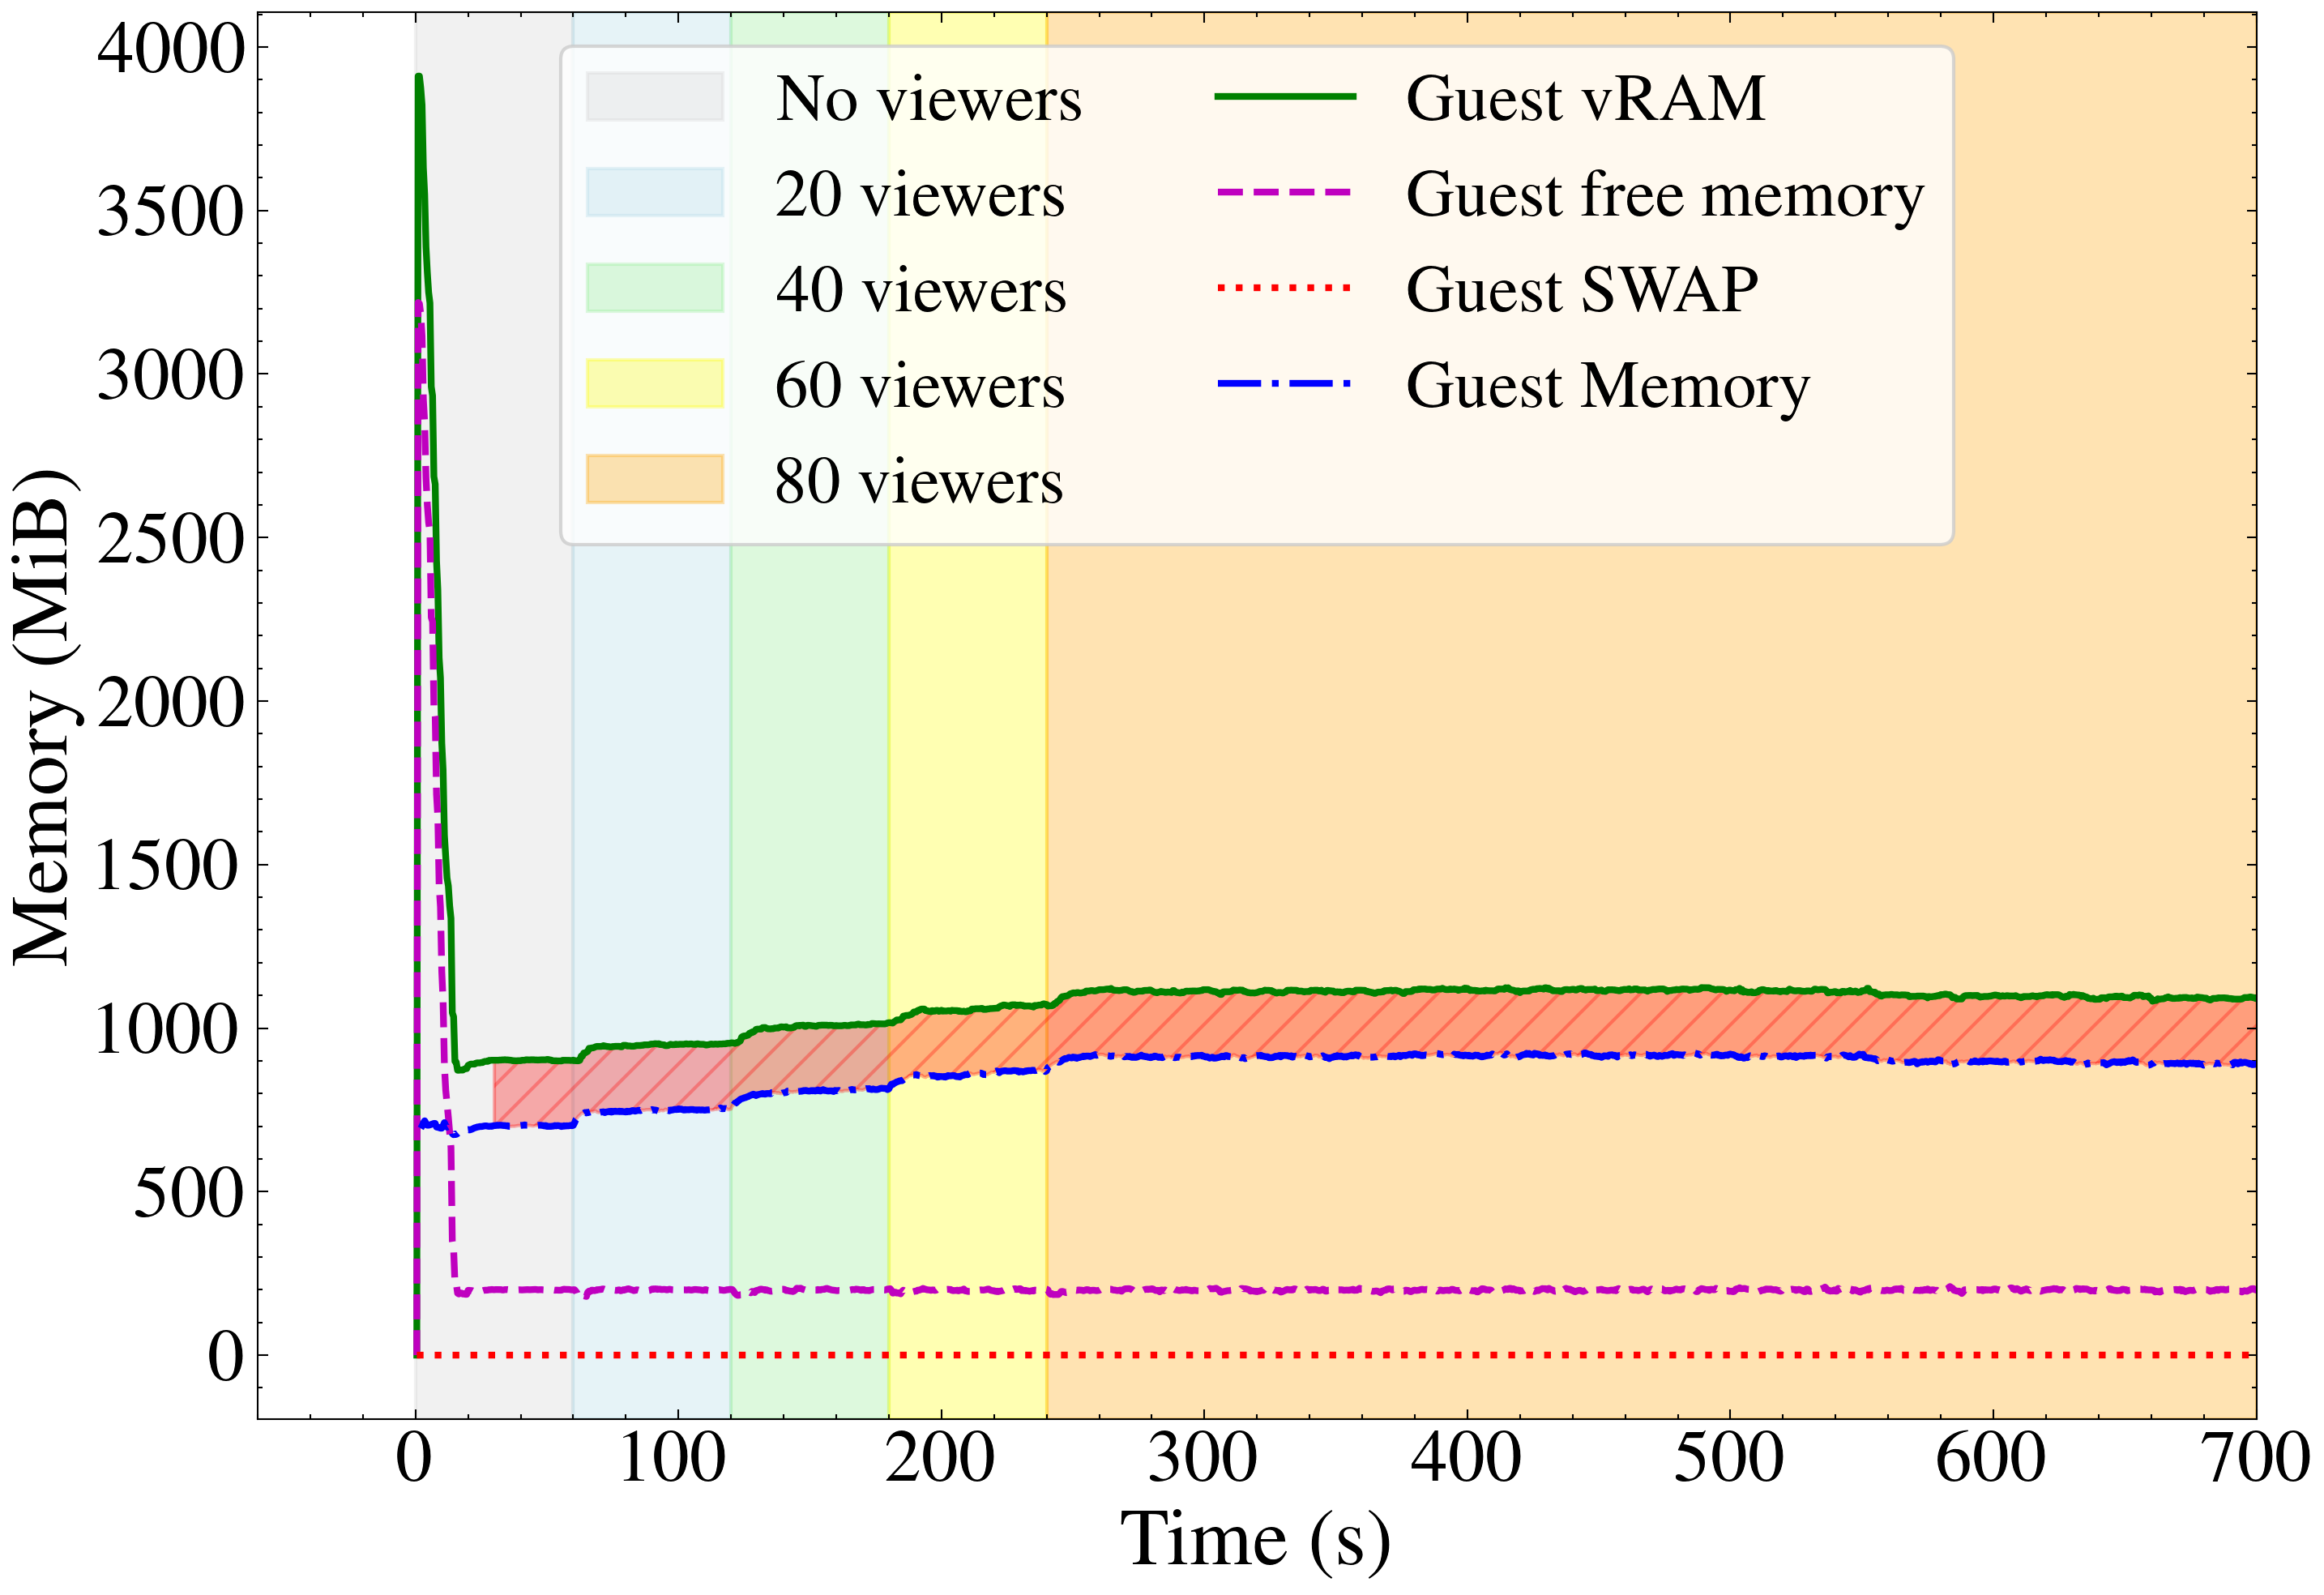

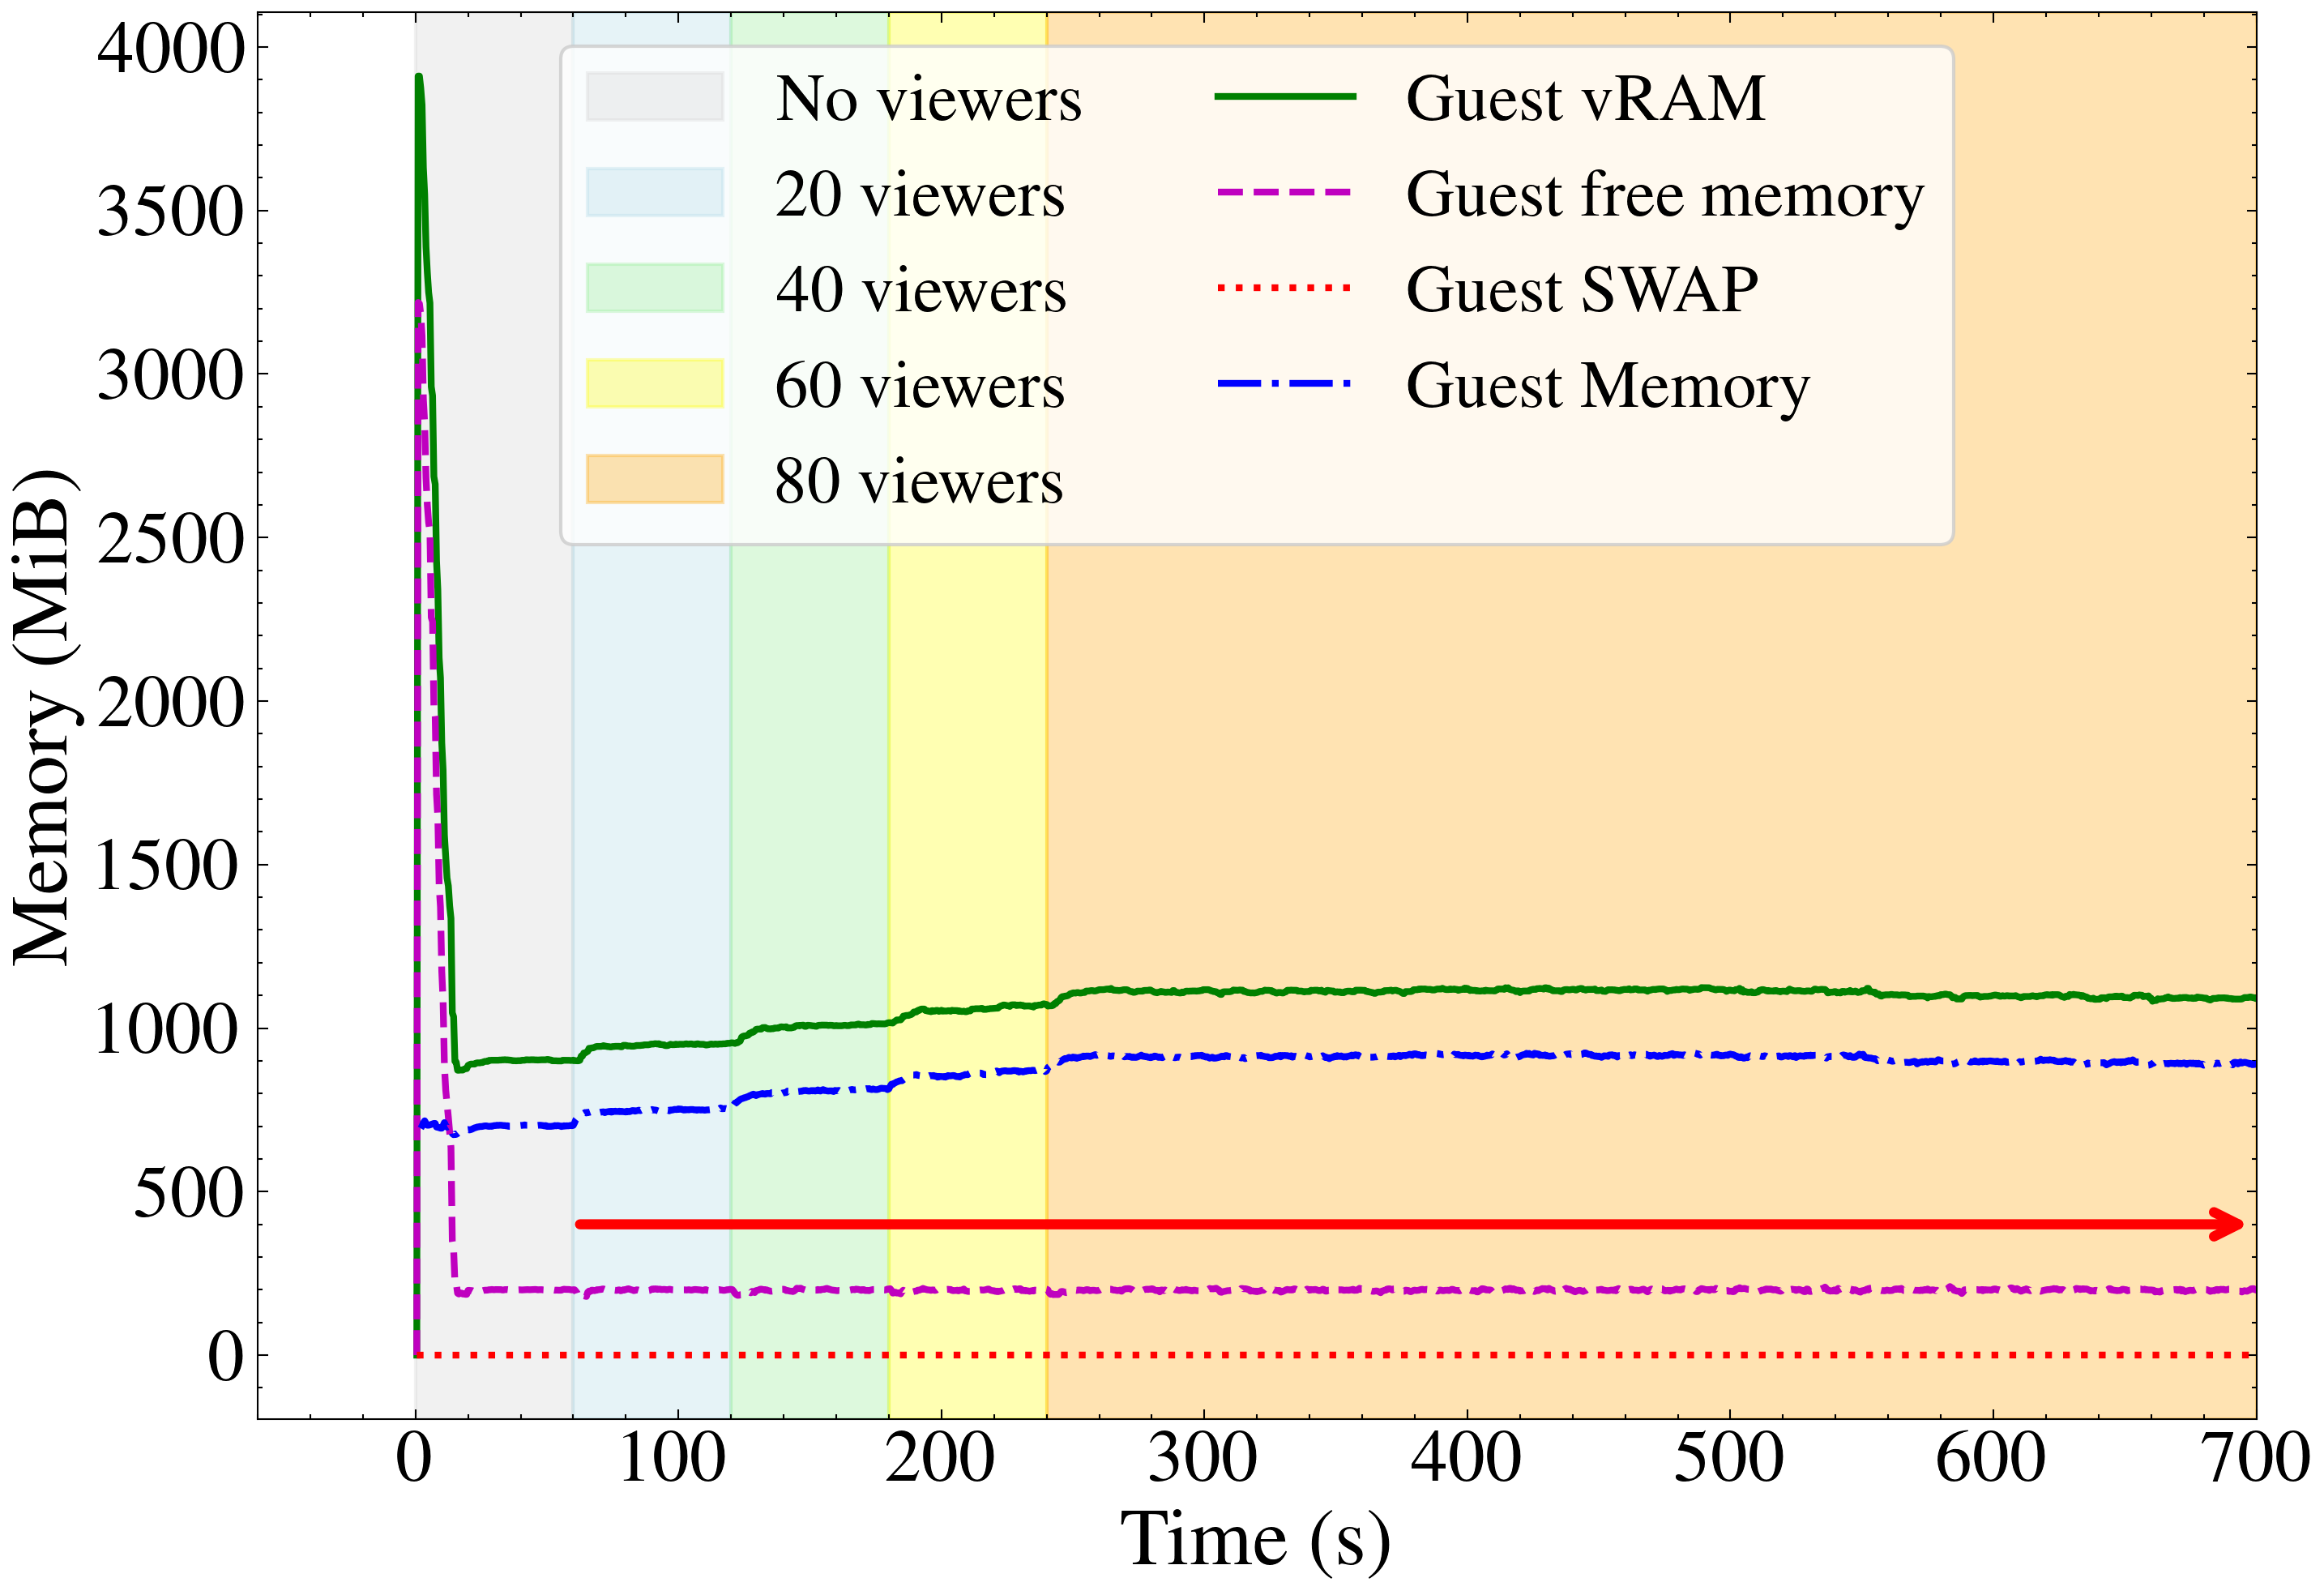

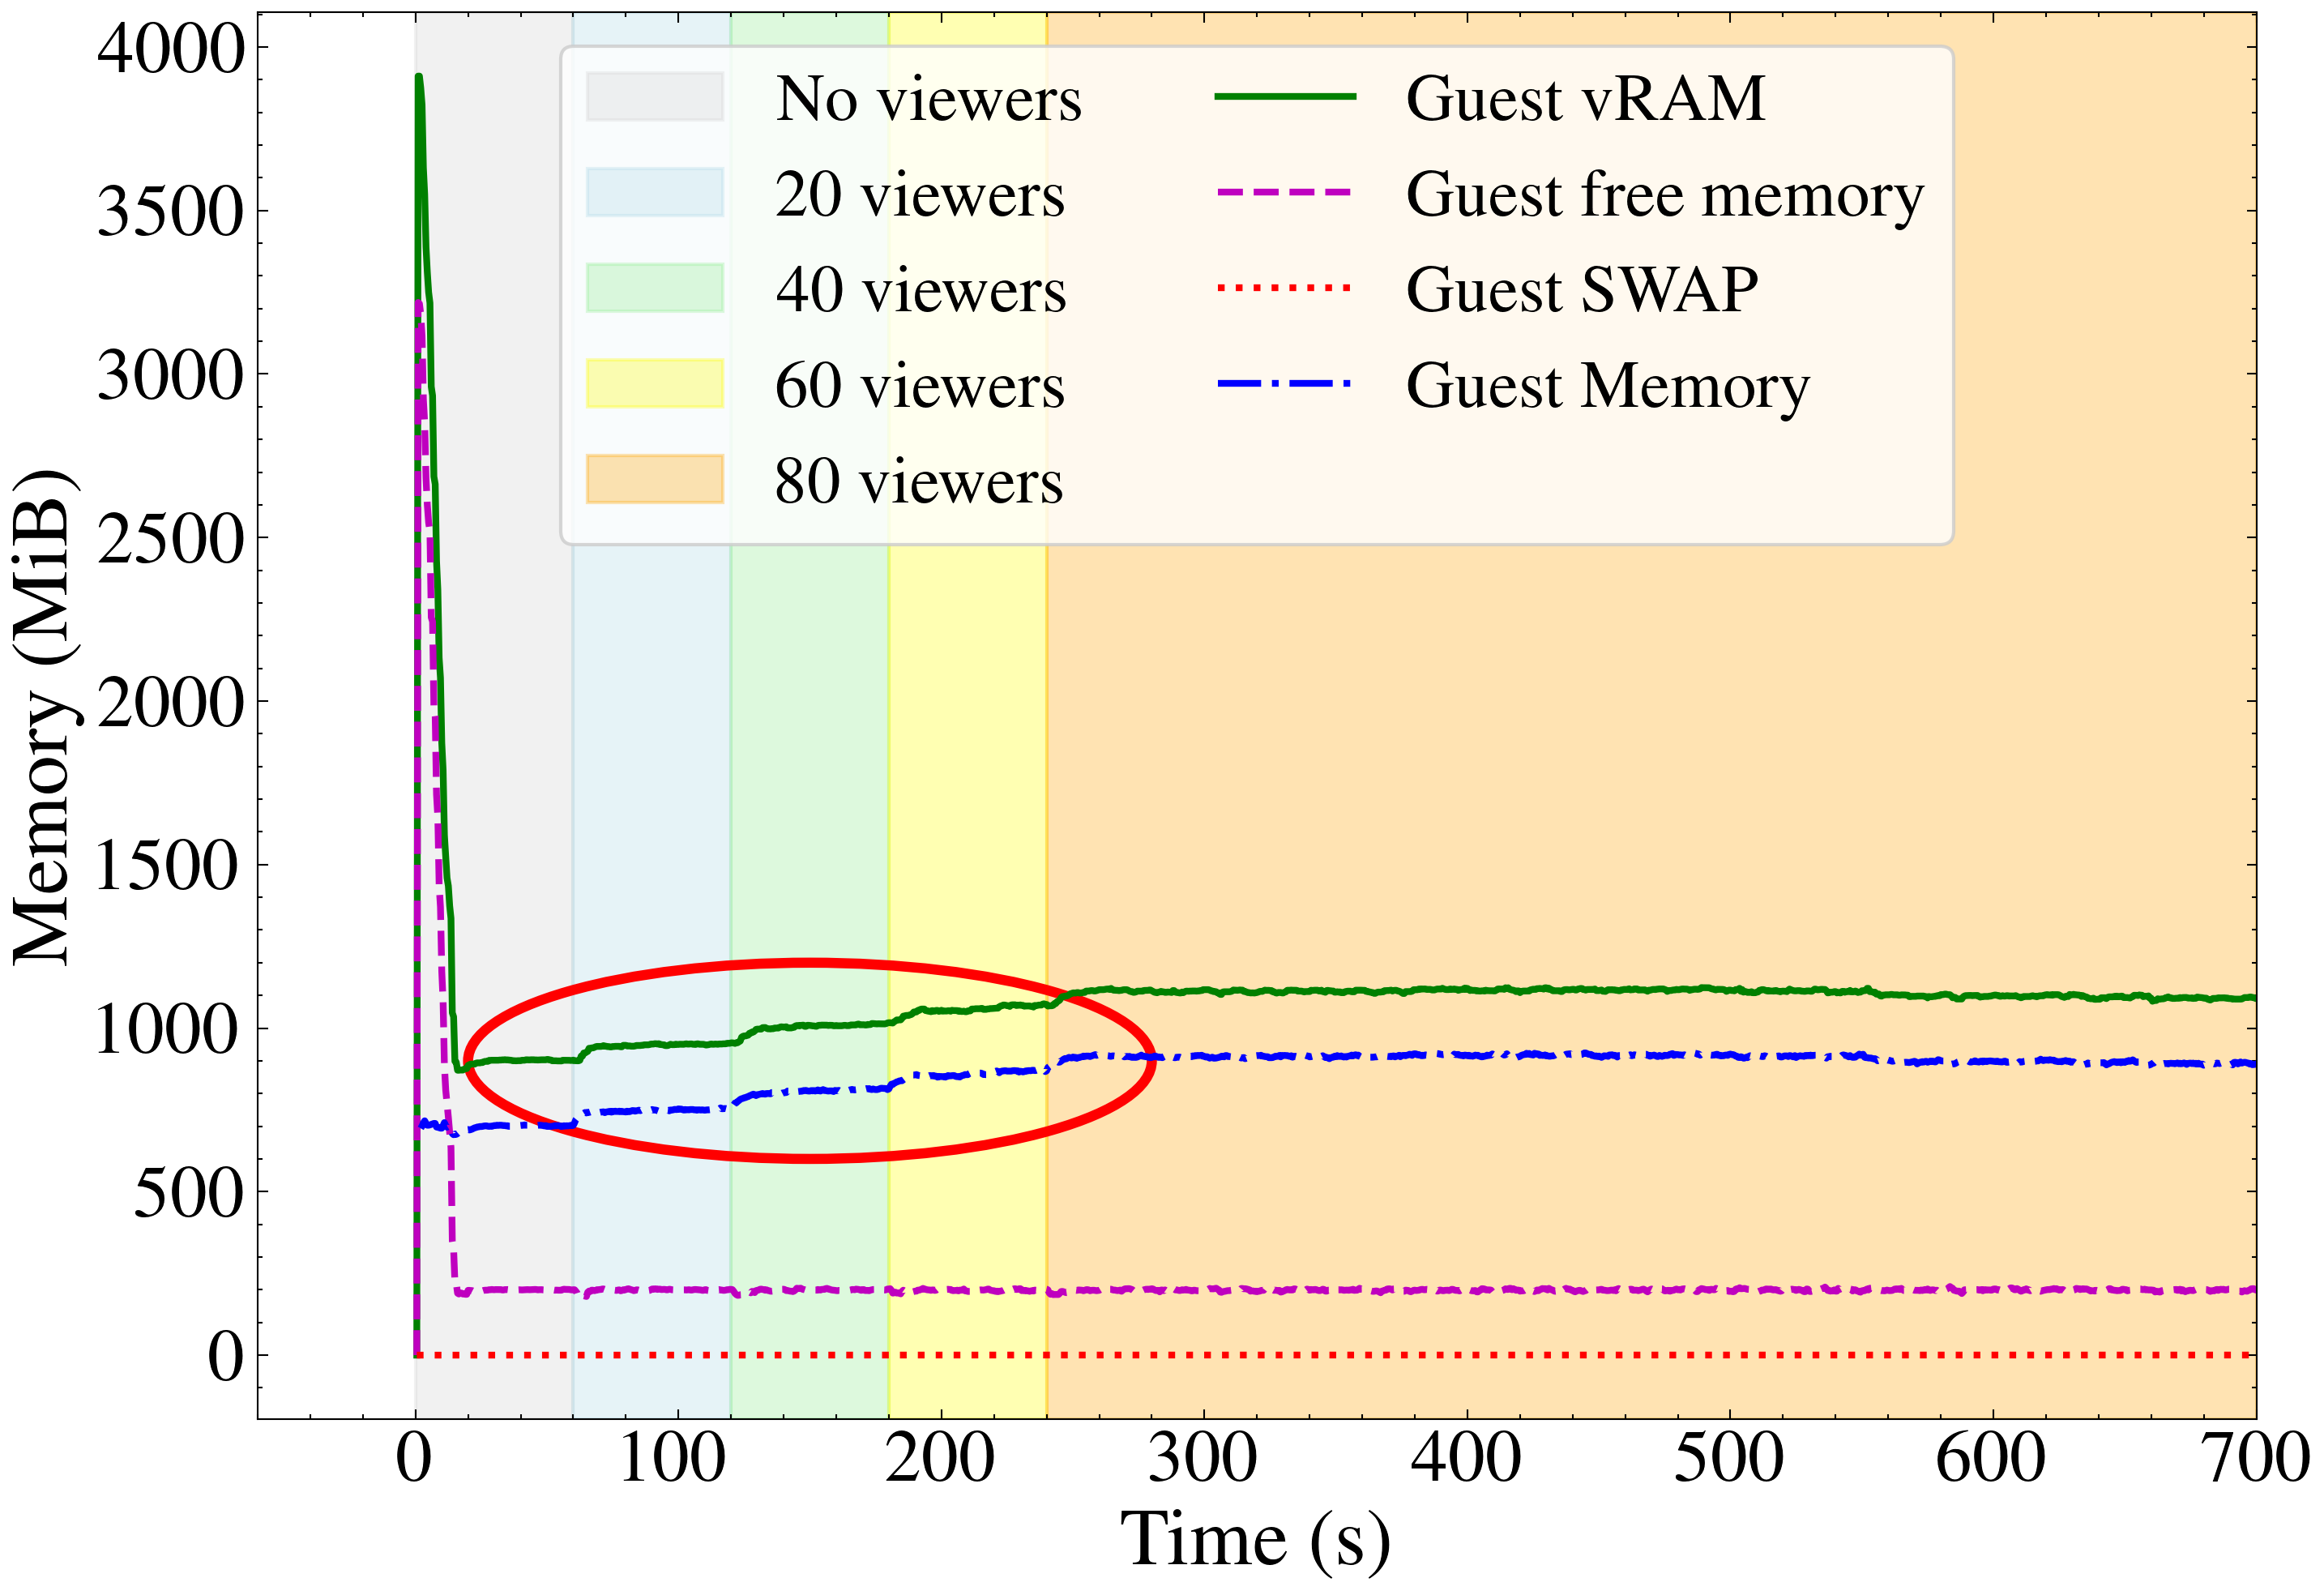

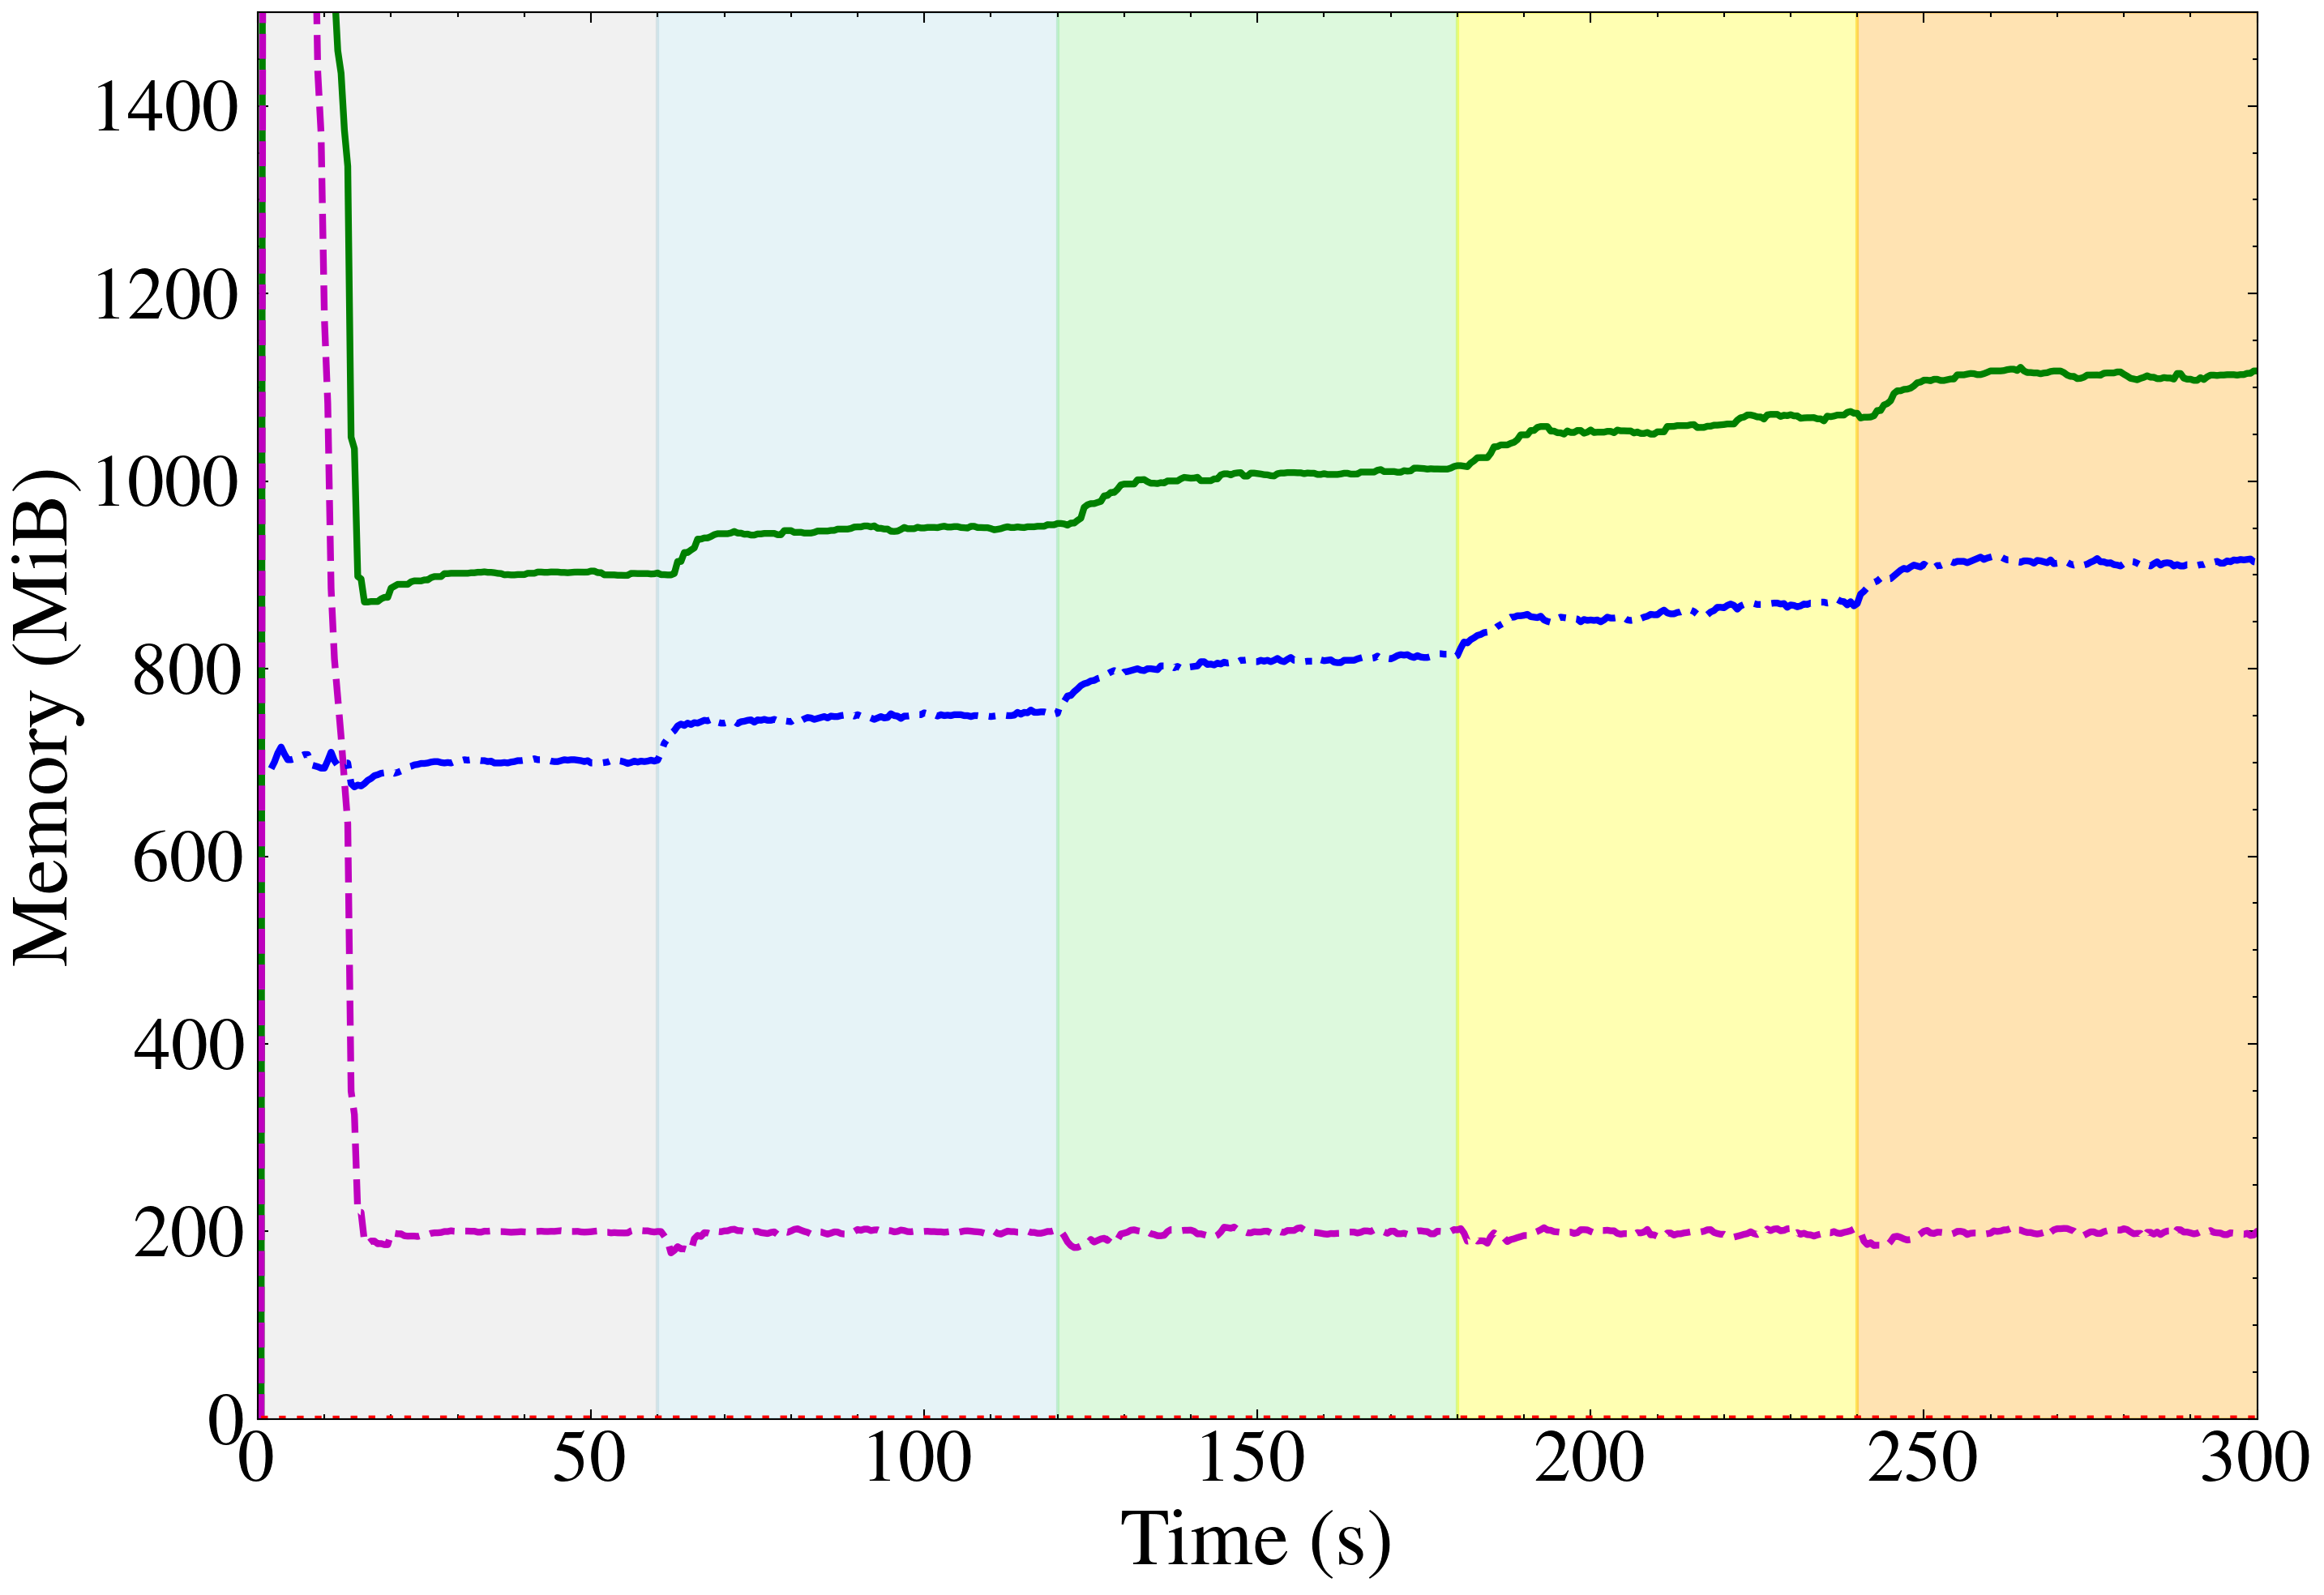

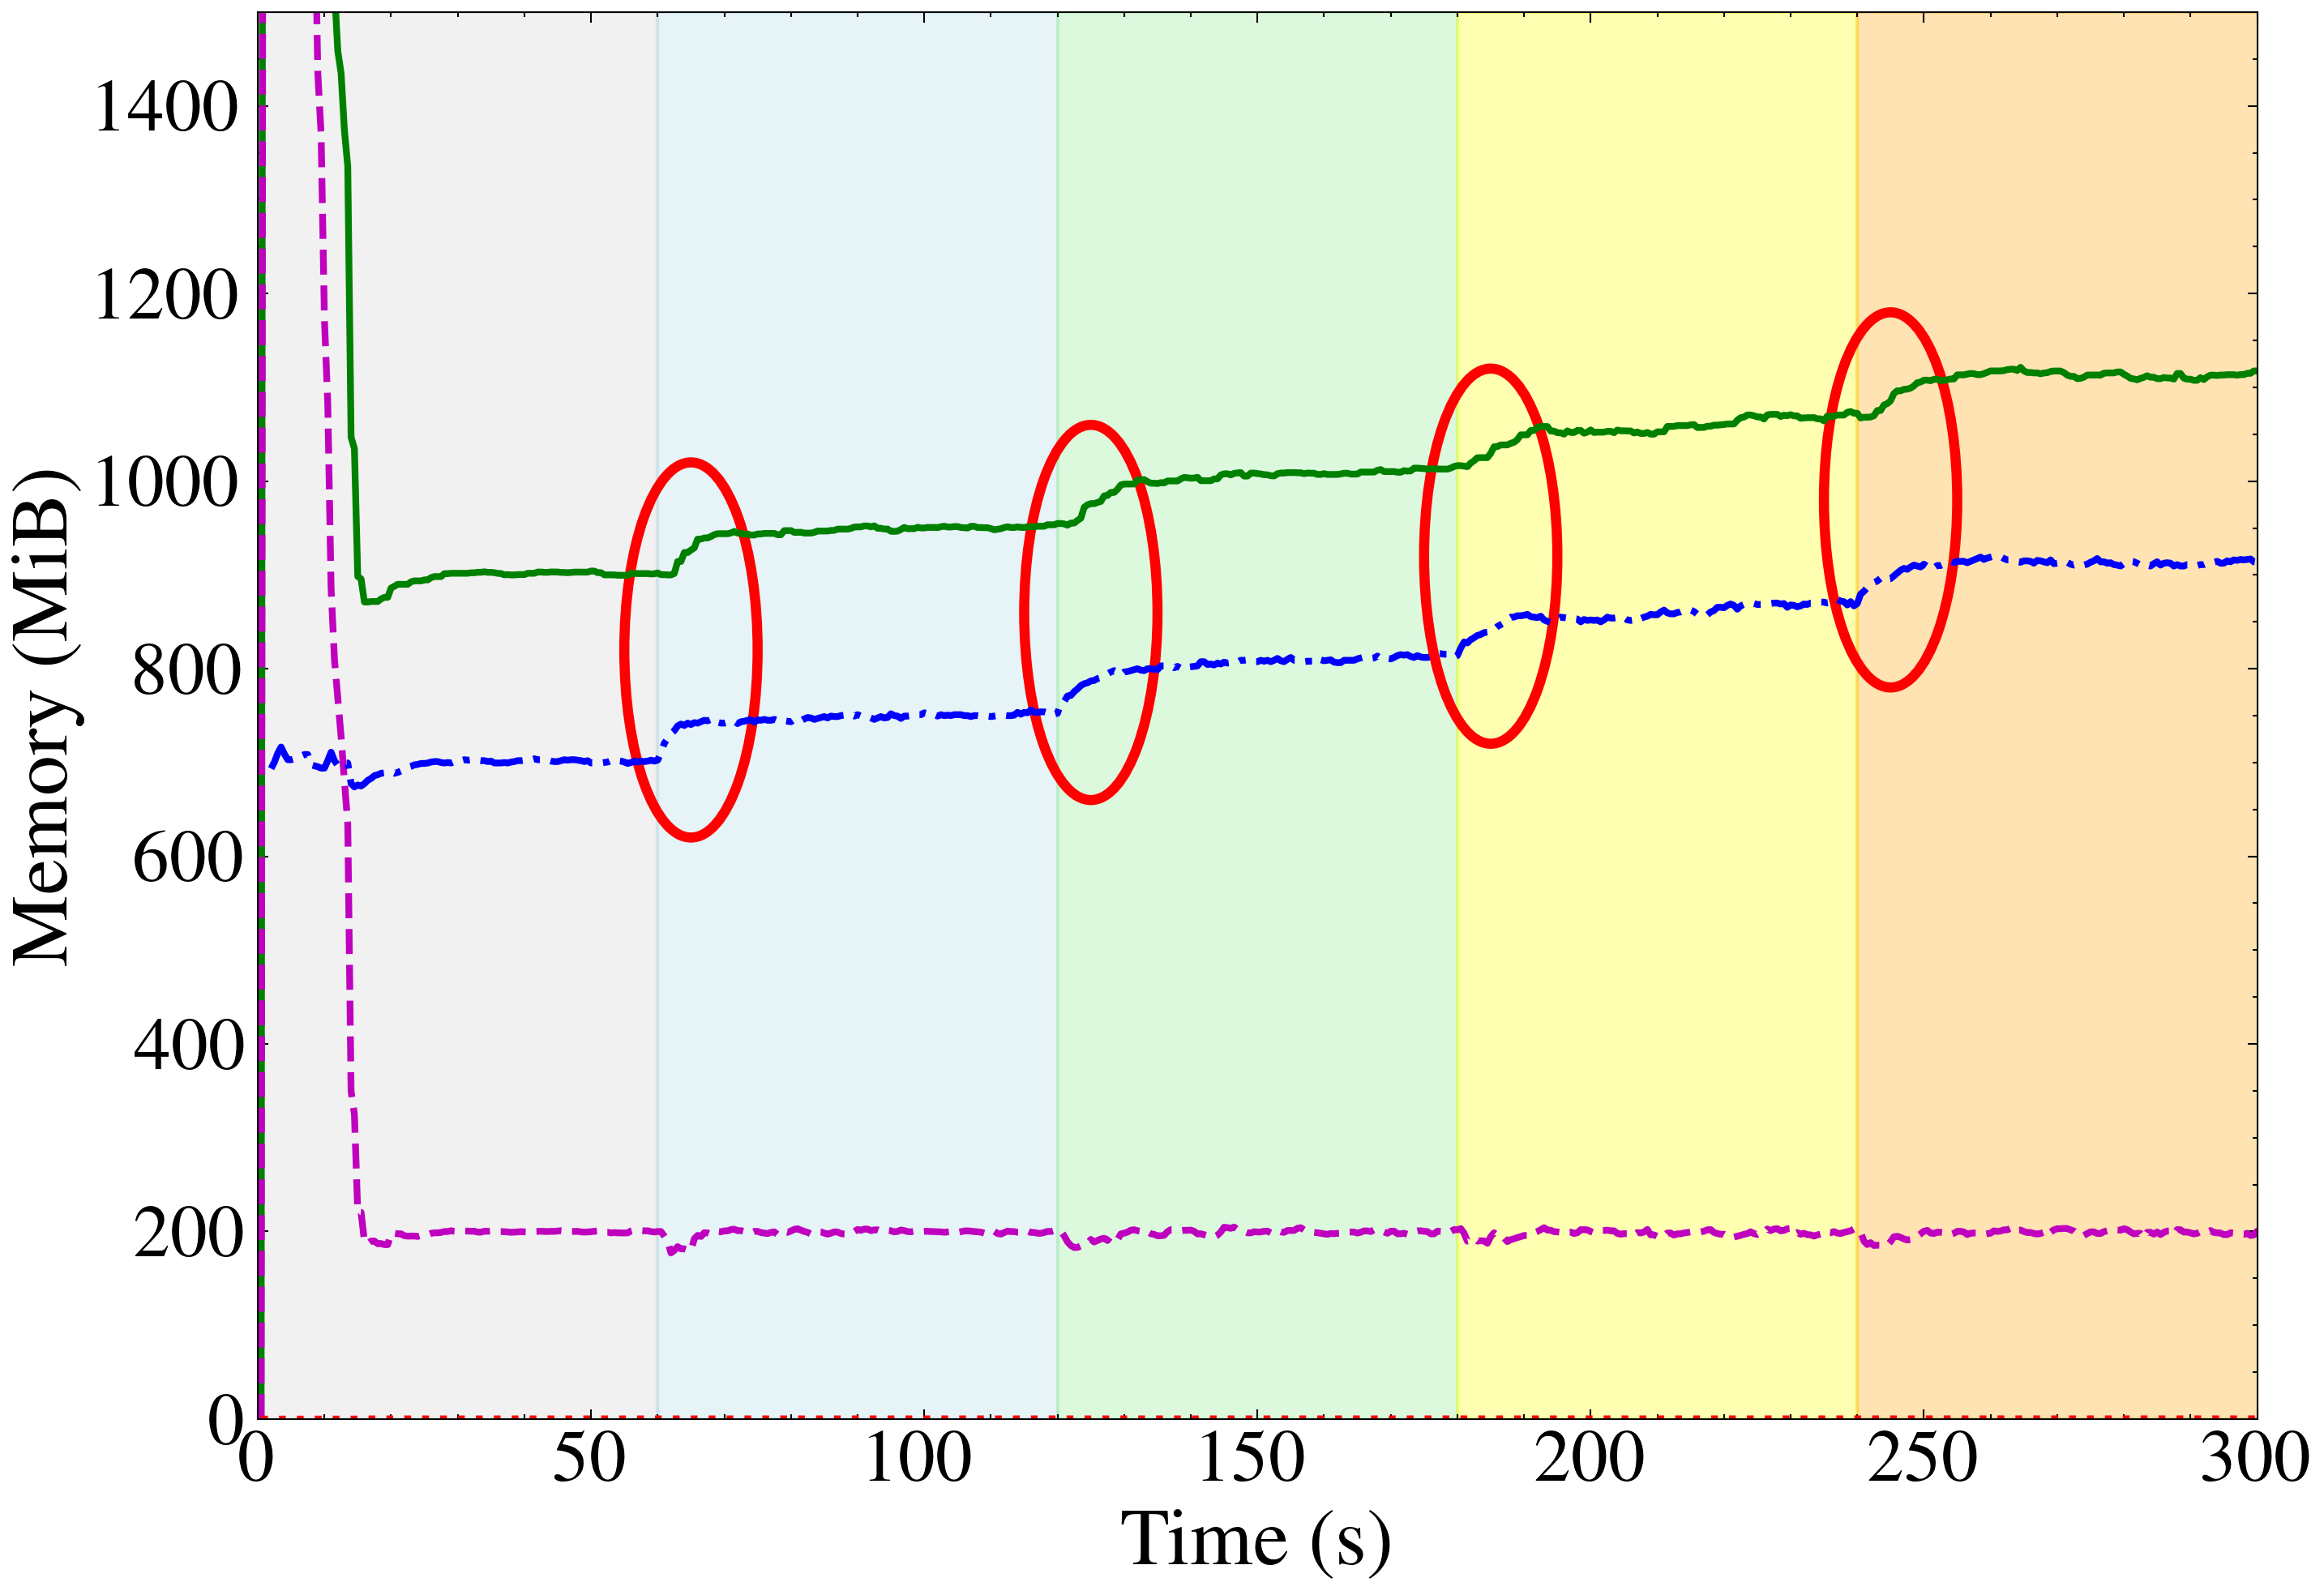

In [195]:
def annotate_ellipse(ax, x=0, y=2000, width=100, height=500, color='red', linewidth=3):
    from matplotlib.patches import Ellipse
    
    oval = Ellipse((x, y), width=width, height=height, color=color, fill=False, linewidth=linewidth)
    ax.add_patch(oval)

def annotate_arrow(ax, x_start, y_start, x_end, y_end, color='red', linewidth=3):
    """
    Ajoute une flèche de (x_start, y_start) à (x_end, y_end)
    """
    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle='->', color=color, lw=linewidth))

def annotate_fill_between(ax, df, x_start=0, x_end=100, color='red', alpha=0.3):
    x_data = df["TIME"]/1000
    df_filtered = df.filter((x_data >= x_start) & (x_data <= x_end))
    x_filtered = df_filtered["TIME"]/1000

    x_data = df_filtered["TIME"]/1000
    y1_data = df_filtered['Guest vRAM'] / 1024
    y2_data = df_filtered['Guest Memory']

    ax.fill_between(x_data.to_numpy(), y1_data.to_numpy(), y2_data.to_numpy(), 
                    color=color, alpha=alpha, label='_nolegend_', hatch='//')

def zoom(ax, xmin, xmax, ymin, ymax):
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

def zoom_and_circles_1(ax, _):
    zoom(ax,0,300,0,1500)
    annotate_ellipse(ax, 65, 820, 20, 400)
    annotate_ellipse(ax, 125, 860, 20, 400)
    annotate_ellipse(ax, 185, 920, 20, 400)
    annotate_ellipse(ax, 245, 980, 20, 400)

def zoom_and_circles_2(ax, _):
    zoom(ax,850,950,0,1500)
    annotate_ellipse(ax, 900, 975, 10, 400)

def ballooning_regul(name, annot=None, leg=True):
    query = """
    SELECT TIME, 
           MEDIAN("VIRSH AVAILABLE") AS "Guest vRAM",
           MEDIAN("VIRSH USABLE") AS "Guest free memory",
           MEDIAN("VIRSH SWAP OUT") AS "Guest SWAP",
           MEDIAN("VM MEMORY USAGE") AS "Guest Memory"
    FROM stats
    WHERE exp_name='balloon-pid-viewer-increase-double-longer-par20'
    GROUP BY TIME
    ORDER BY TIME
    """
    df = con.execute(query).pl()
    
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    fig.patch.set_alpha(0.0)

    go_annotate(ax)
    
    ax.plot(df["TIME"]/1000, df["Guest vRAM"]/(1024), label="Guest vRAM", color='g', linewidth=2)
    ax.plot(df["TIME"]/1000, df["Guest free memory"]/(1024), label="Guest free memory", color='m', linewidth=2)
    ax.plot(df["TIME"]/1000, df["Guest SWAP"]/(1024), label="Guest SWAP", color='r', linewidth=2)
    ax.plot(df["TIME"]/1000, df["Guest Memory"], label="Guest Memory", color='b', linewidth=2)

    ax.set_xlim(-60,700)
    ax.set_xlabel('Time (s)', fontweight='bold', fontsize=24)
    ax.set_ylabel('Memory (MiB)', fontweight='bold', fontsize=24)

    for label in ax.get_xticklabels():
        label.set_fontsize(22)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(22)

    if leg:
        ax.legend(frameon=True, ncol=2, loc="upper center", fontsize=20)

    if annot:
        annot(ax, df)
    
    plt.tight_layout()
    plt.savefig(f'figure-notebook/balloning_webrtc_results/{name}.pdf', bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

ballooning_regul('1')
ballooning_regul('2', annot=lambda ax,_: annotate_ellipse(ax, 0, 2000, 60, 4000))
ballooning_regul('3', annot=lambda ax,df: annotate_fill_between(ax, df, 30, 1000))
ballooning_regul('4', annot=lambda ax,df: annotate_arrow(ax, 60, 400, 700, 400))
ballooning_regul('5', annot=lambda ax,df: annotate_ellipse(ax, 150, 900, 260, 600))
ballooning_regul('6', annot=lambda ax,df: zoom(ax,0,300,0,1500), leg=False)
ballooning_regul('7', annot=zoom_and_circles_1, leg=False)
# ballooning_regul('8', annot=lambda ax,df: annotate_ellipse(ax, 930, 1000, 100, 400))
# ballooning_regul('9', annot=lambda ax,df: zoom(ax,850,950,0,1500), leg=False)
# ballooning_regul('10', annot=zoom_and_circles_2, leg=False)

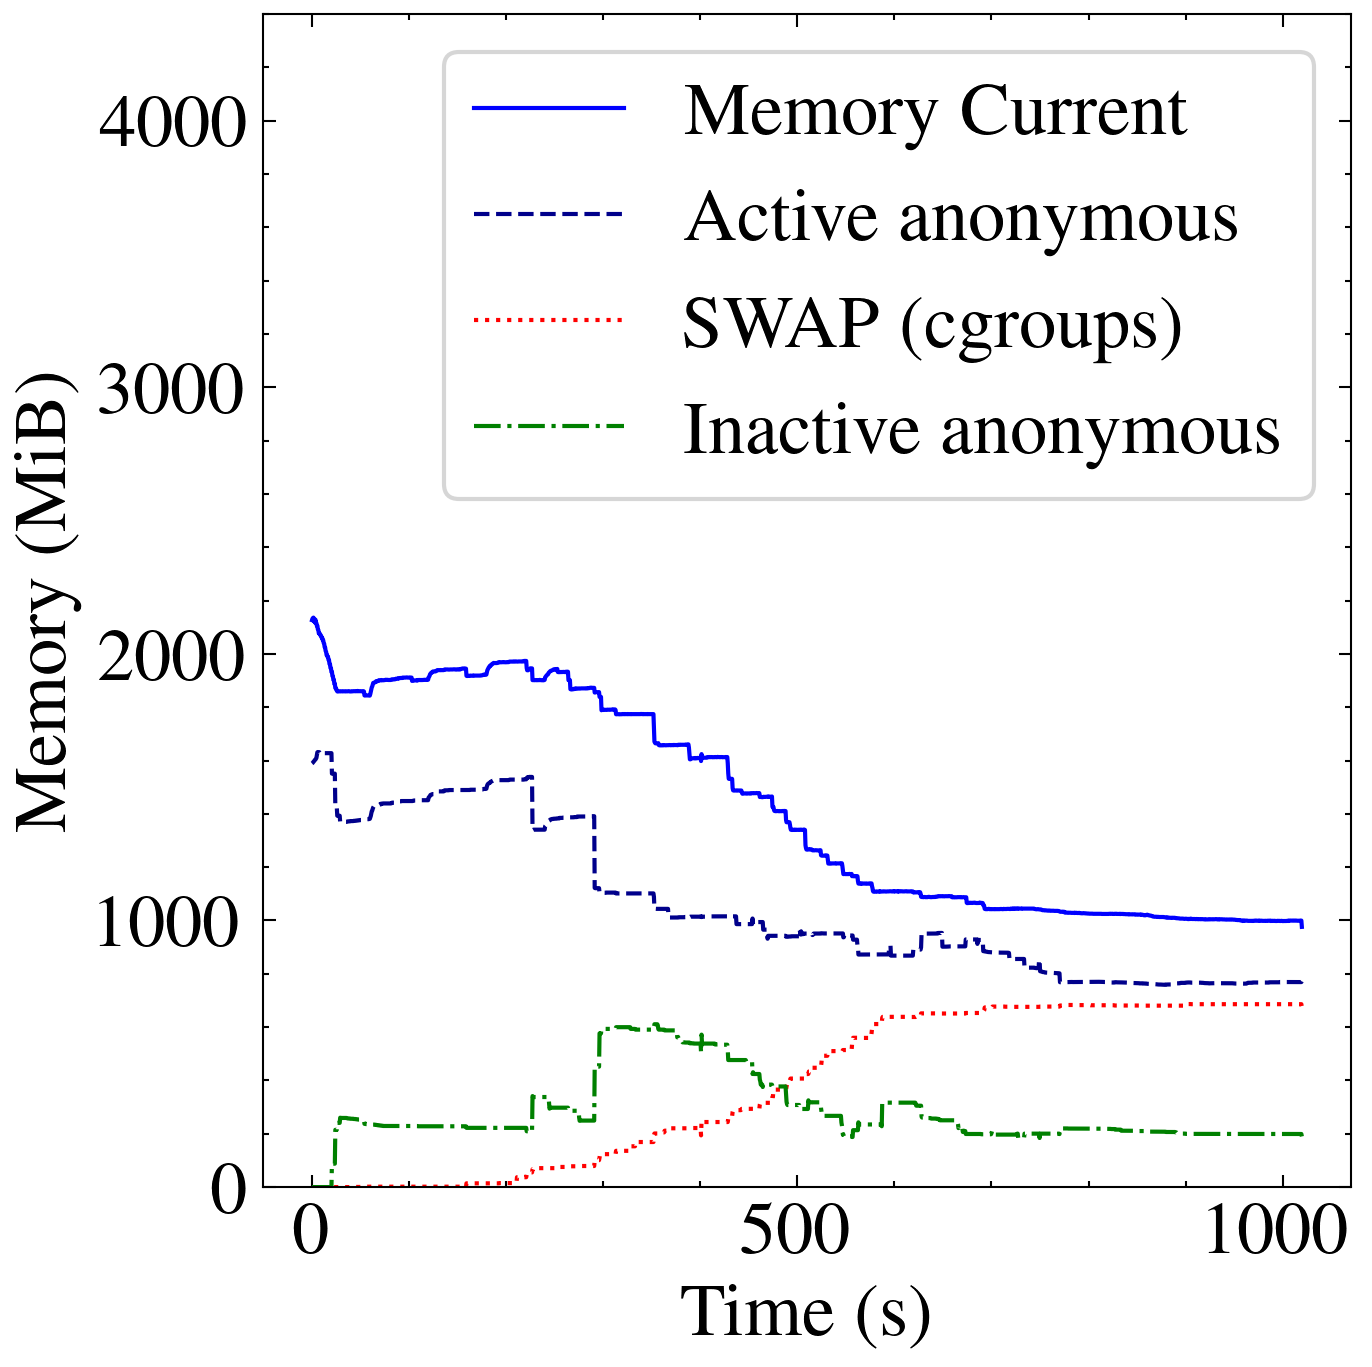

In [98]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY CURRENT") AS "ram",
       MEDIAN("ACTIVE ANON") AS "active",
       MEDIAN("SWAP CURRENT") AS "swap",
       MEDIAN("INACTIVE ANON") AS "inactive"
FROM cgroup_stats
WHERE exp_name='cgroups-regul-stddev-30-viewer-double-increase-par20'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["ram"], label="Memory Current", color='b')
ax.plot(df["TIME"]/1000, df["active"]/(1024*1024), label="Active anonymous", color='darkblue')
ax.plot(df["TIME"]/1000, df["swap"], label="SWAP (cgroups)", color='r')
ax.plot(df["TIME"]/1000, df["inactive"]/(1024*1024), label="Inactive anonymous", color='g')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,4400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/cgroup_memory.pdf', bbox_inches='tight', dpi=300)
plt.show()


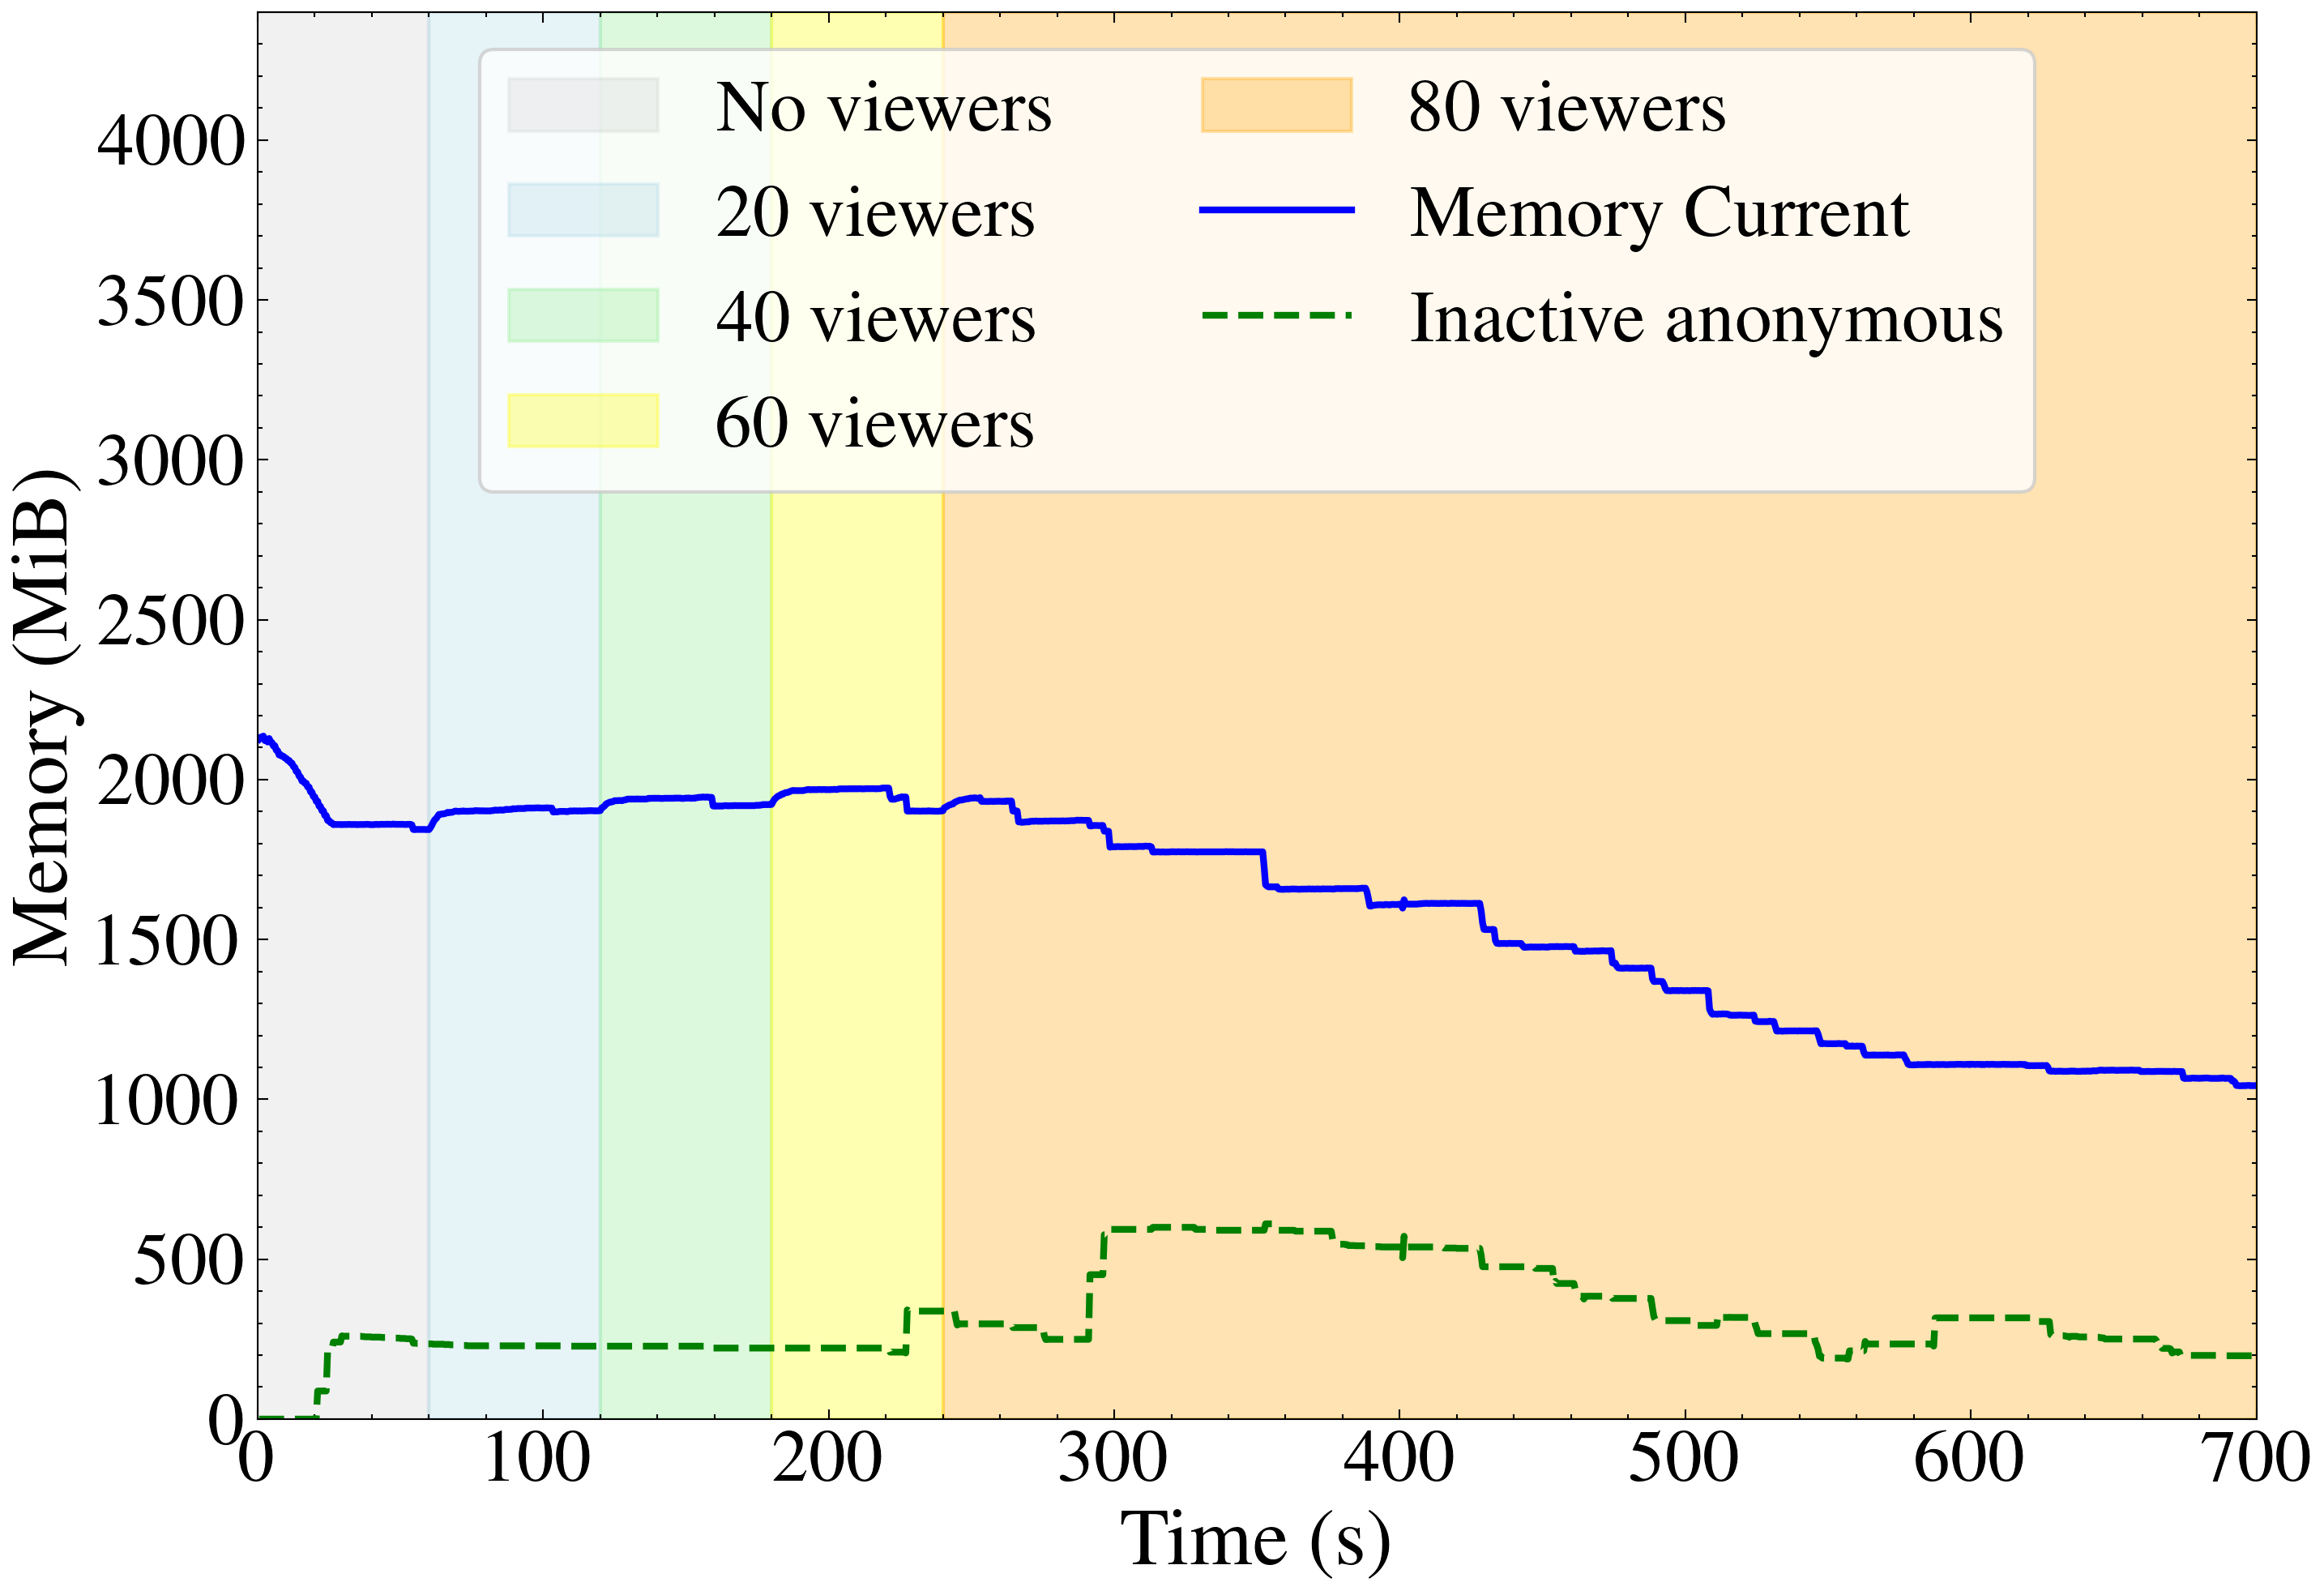

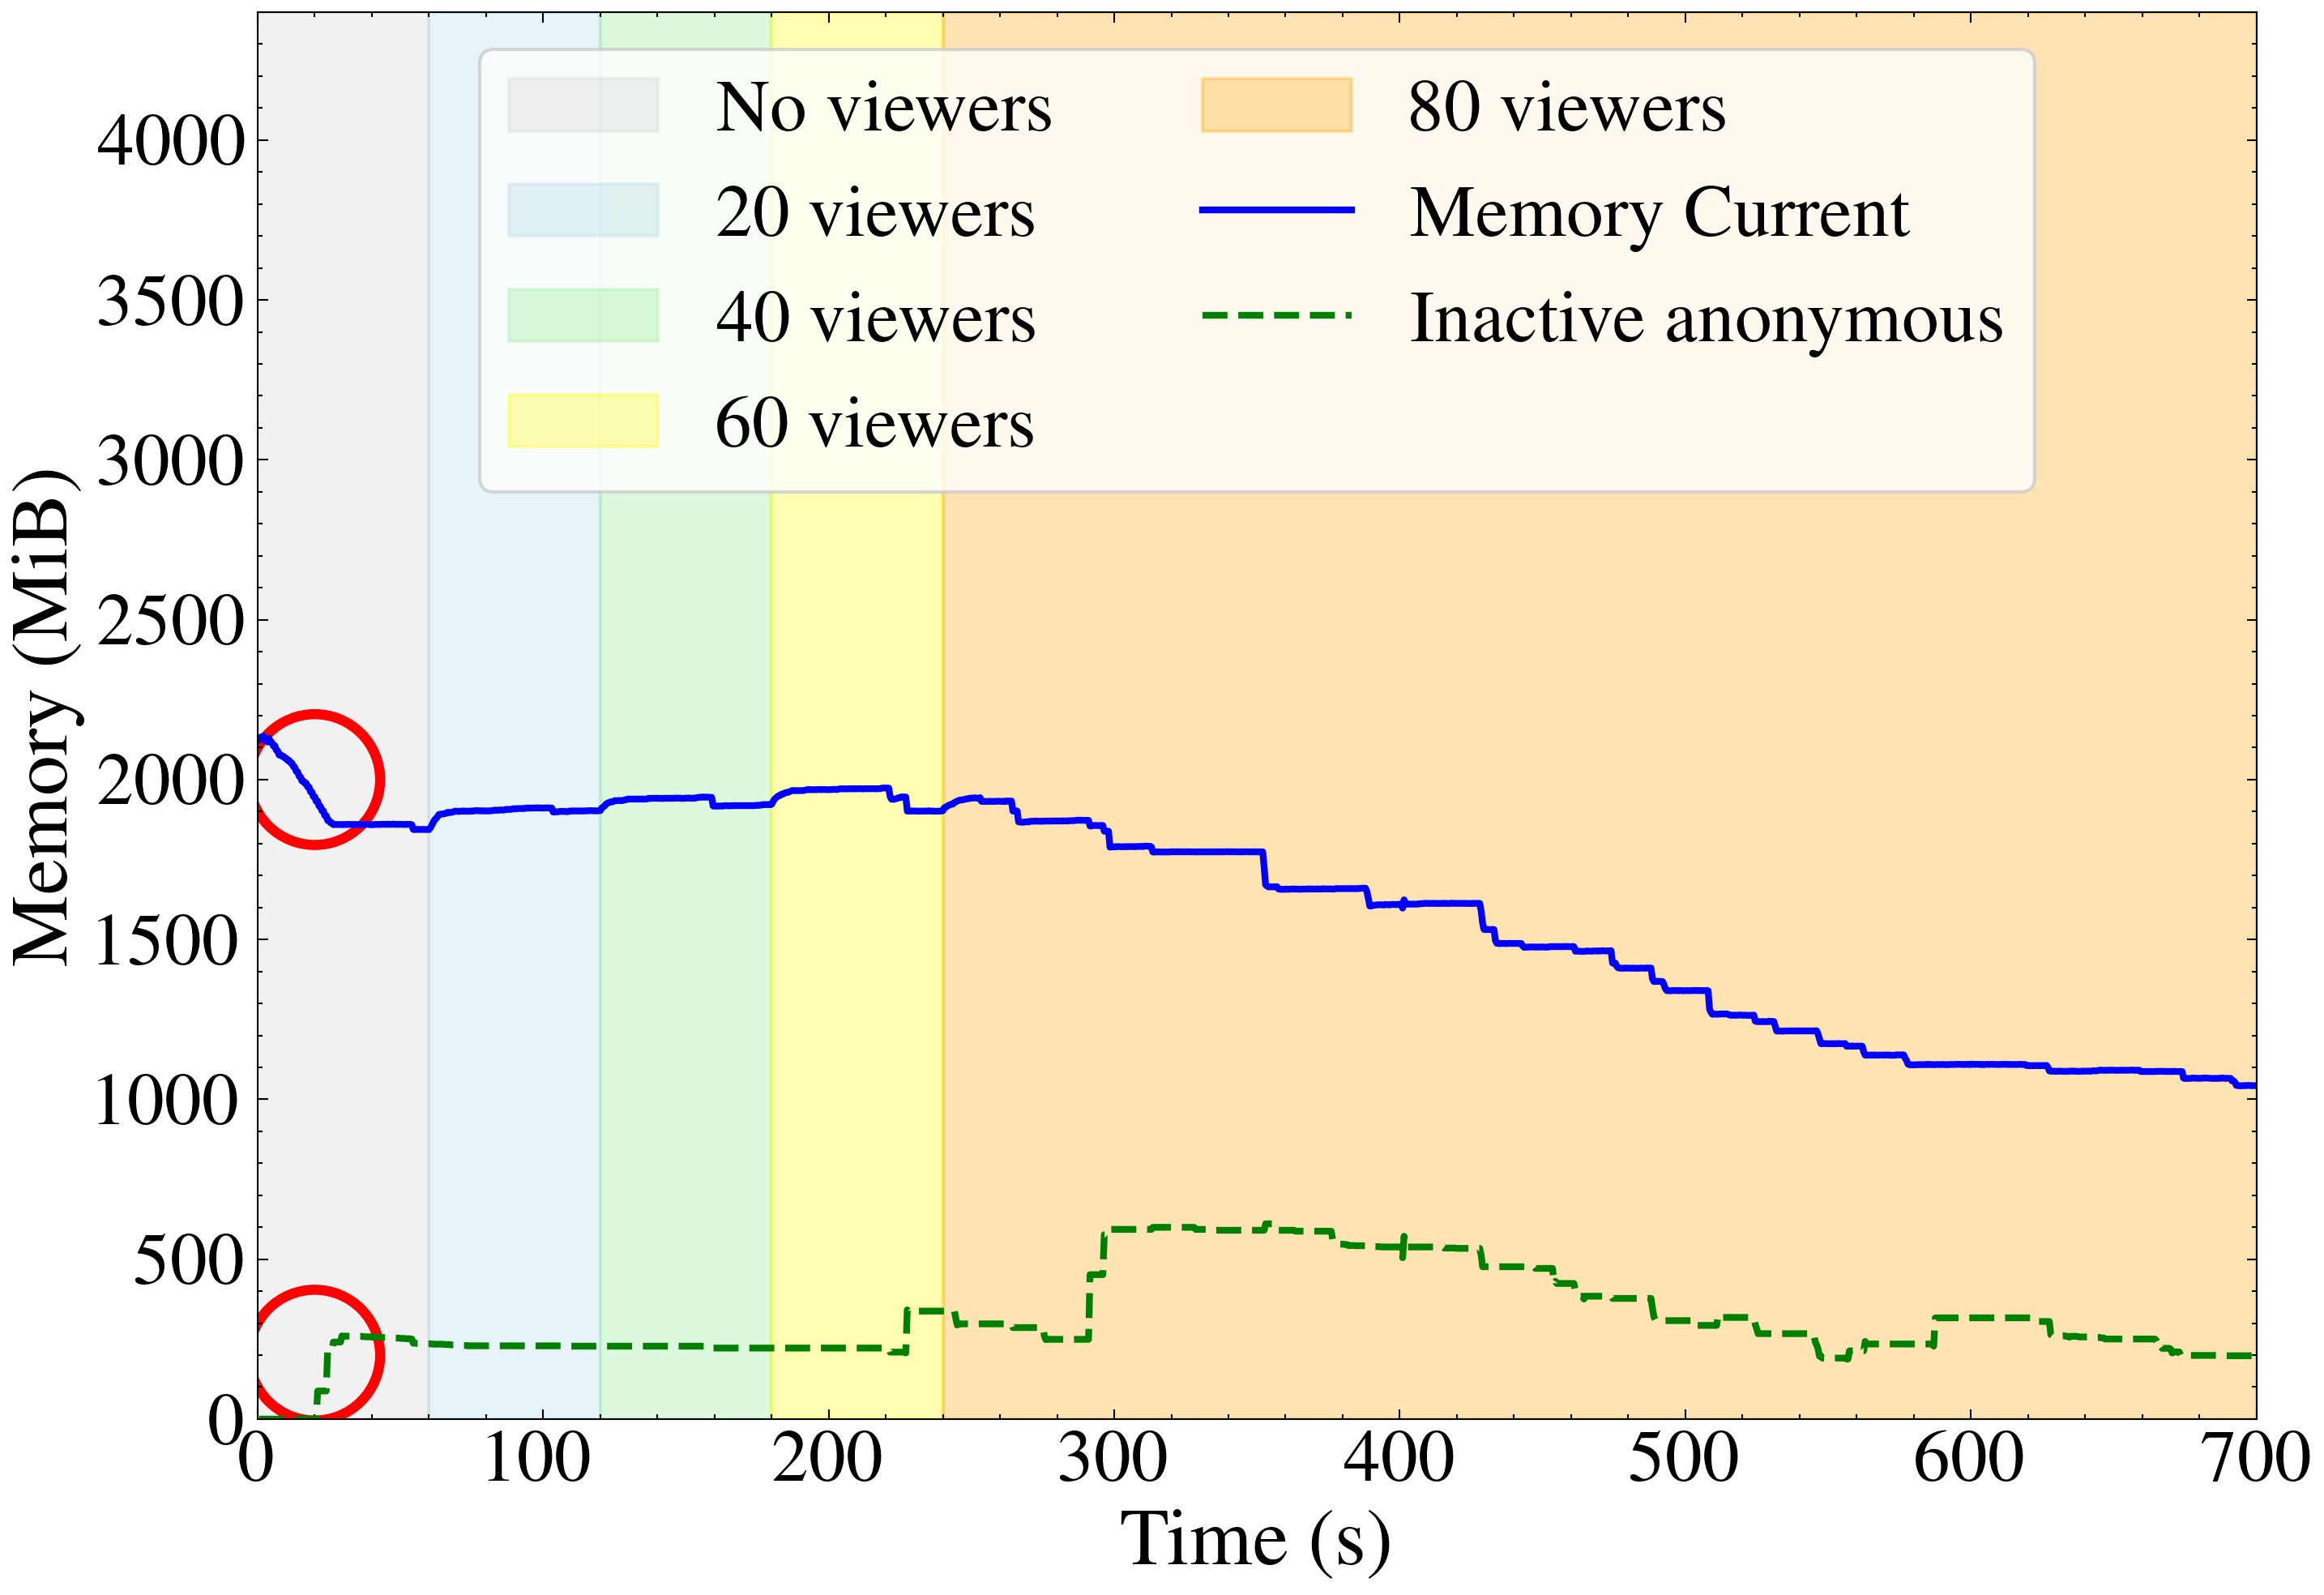

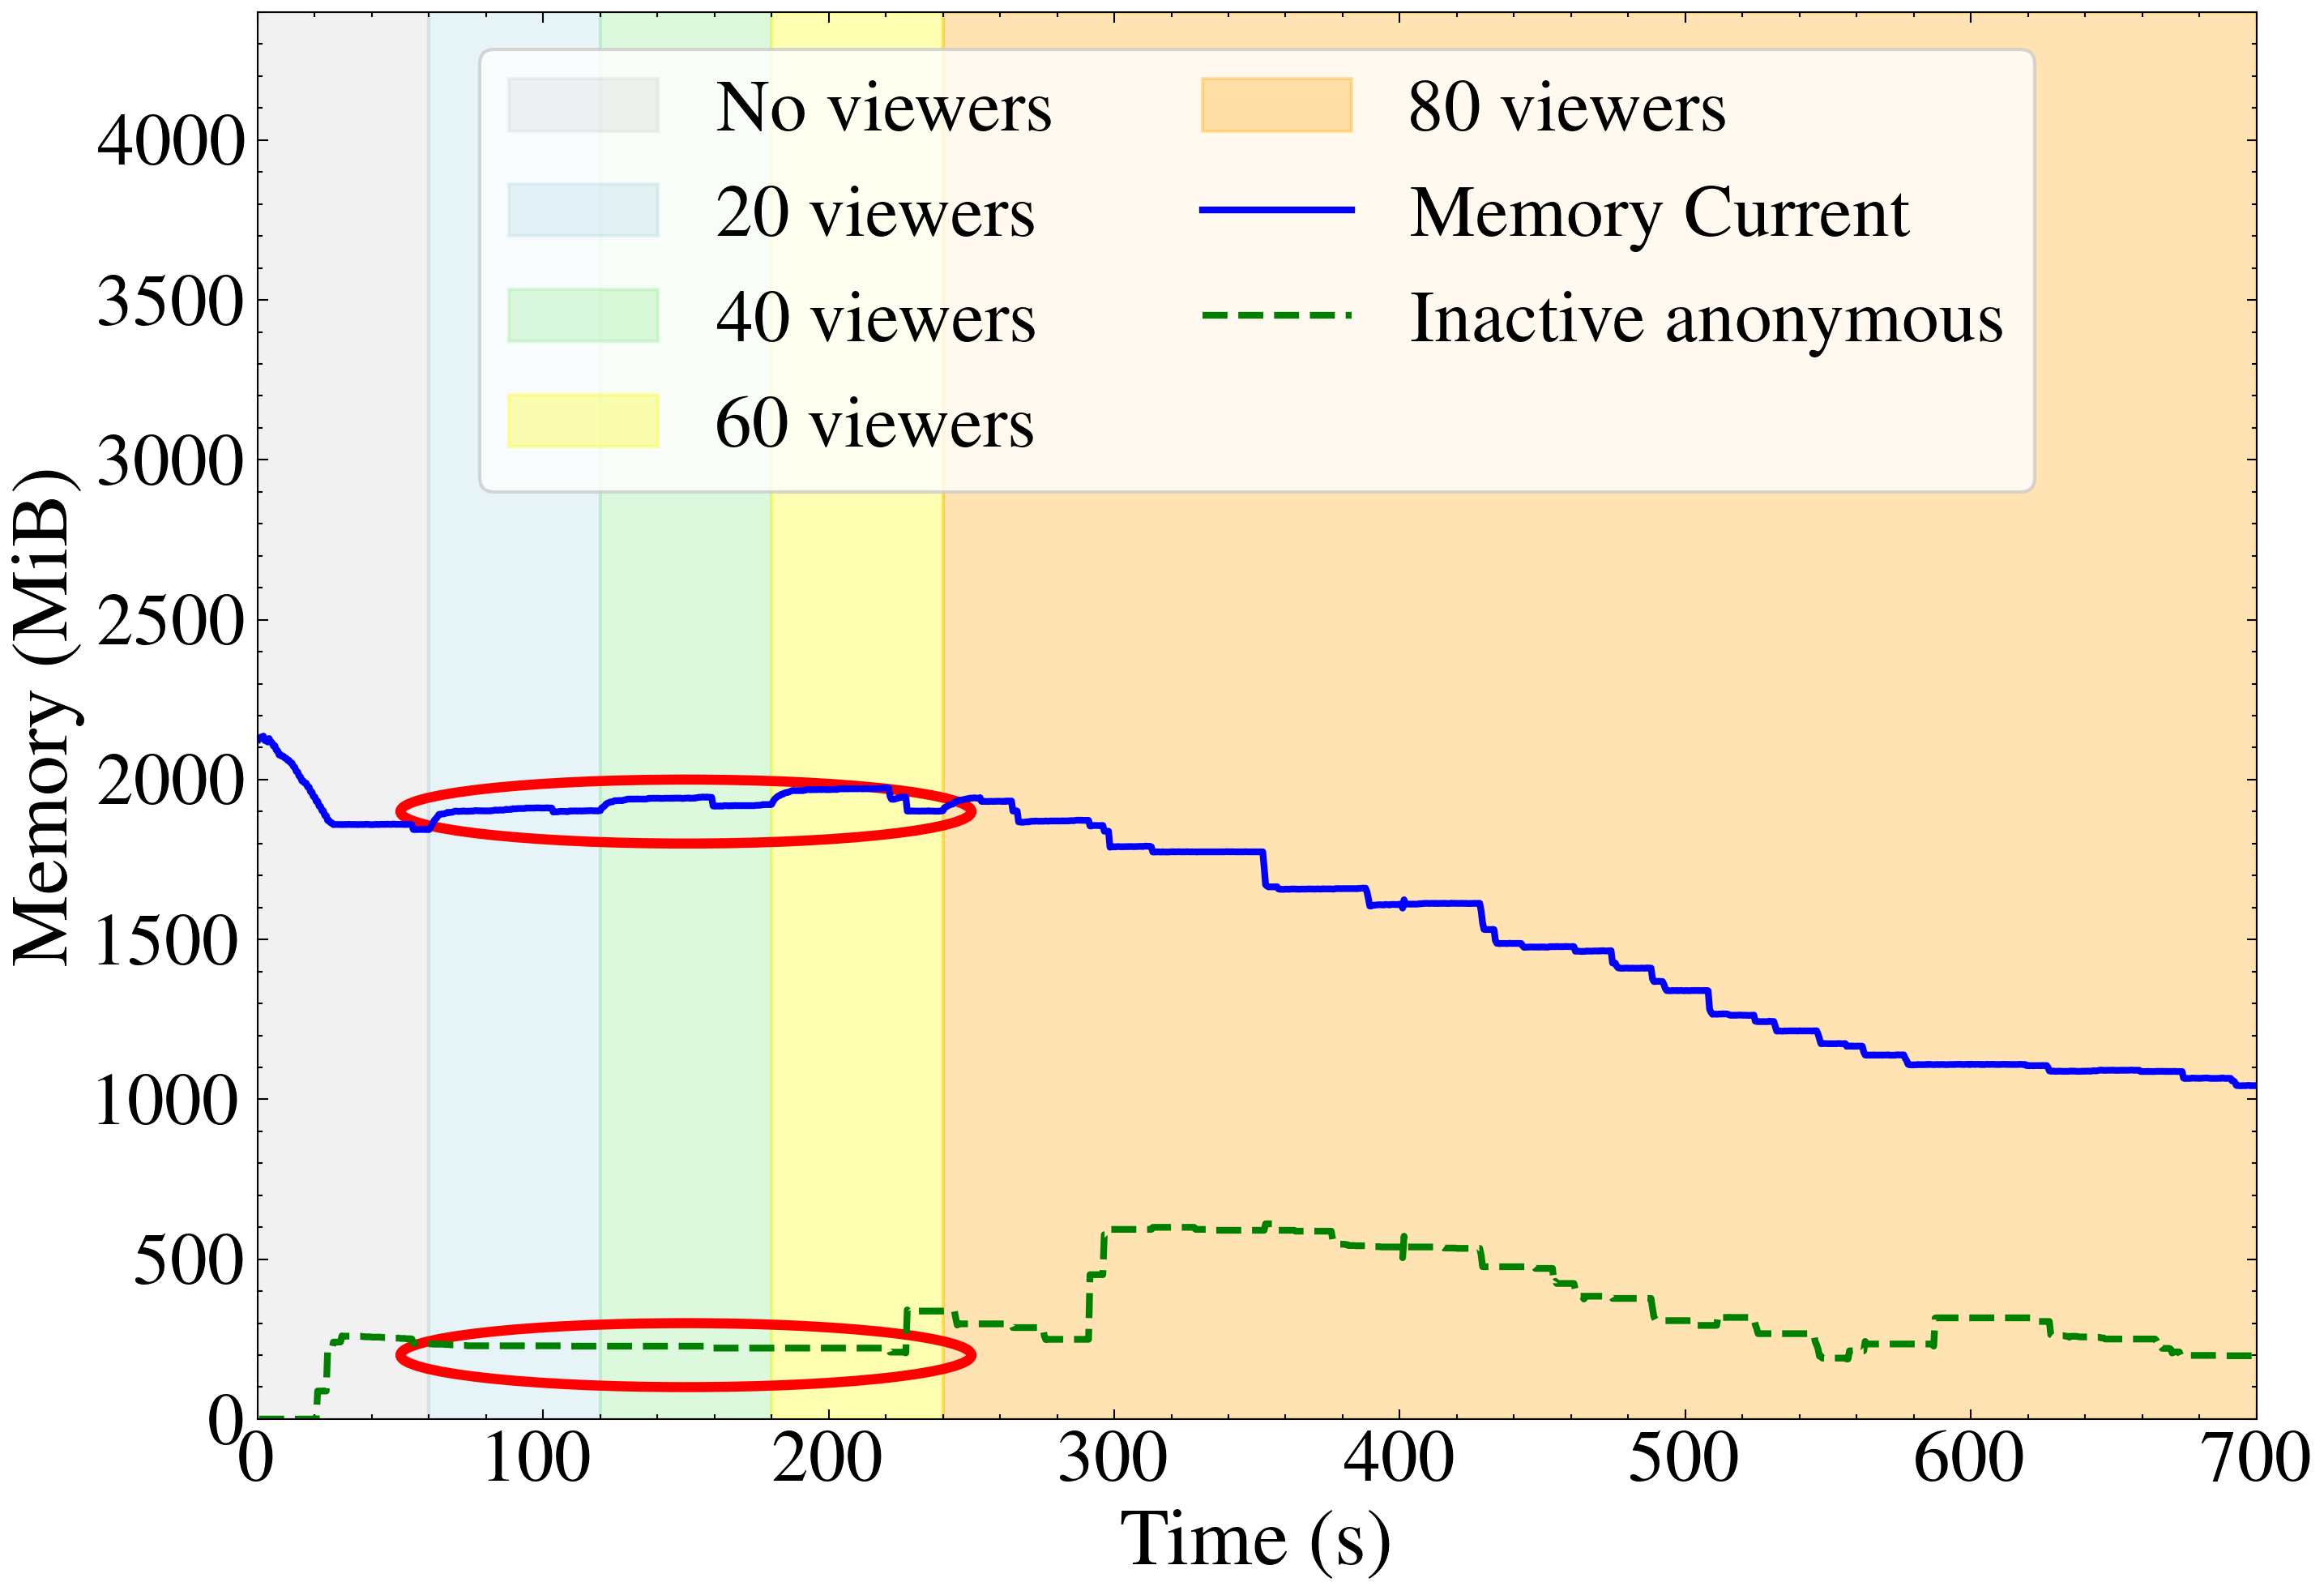

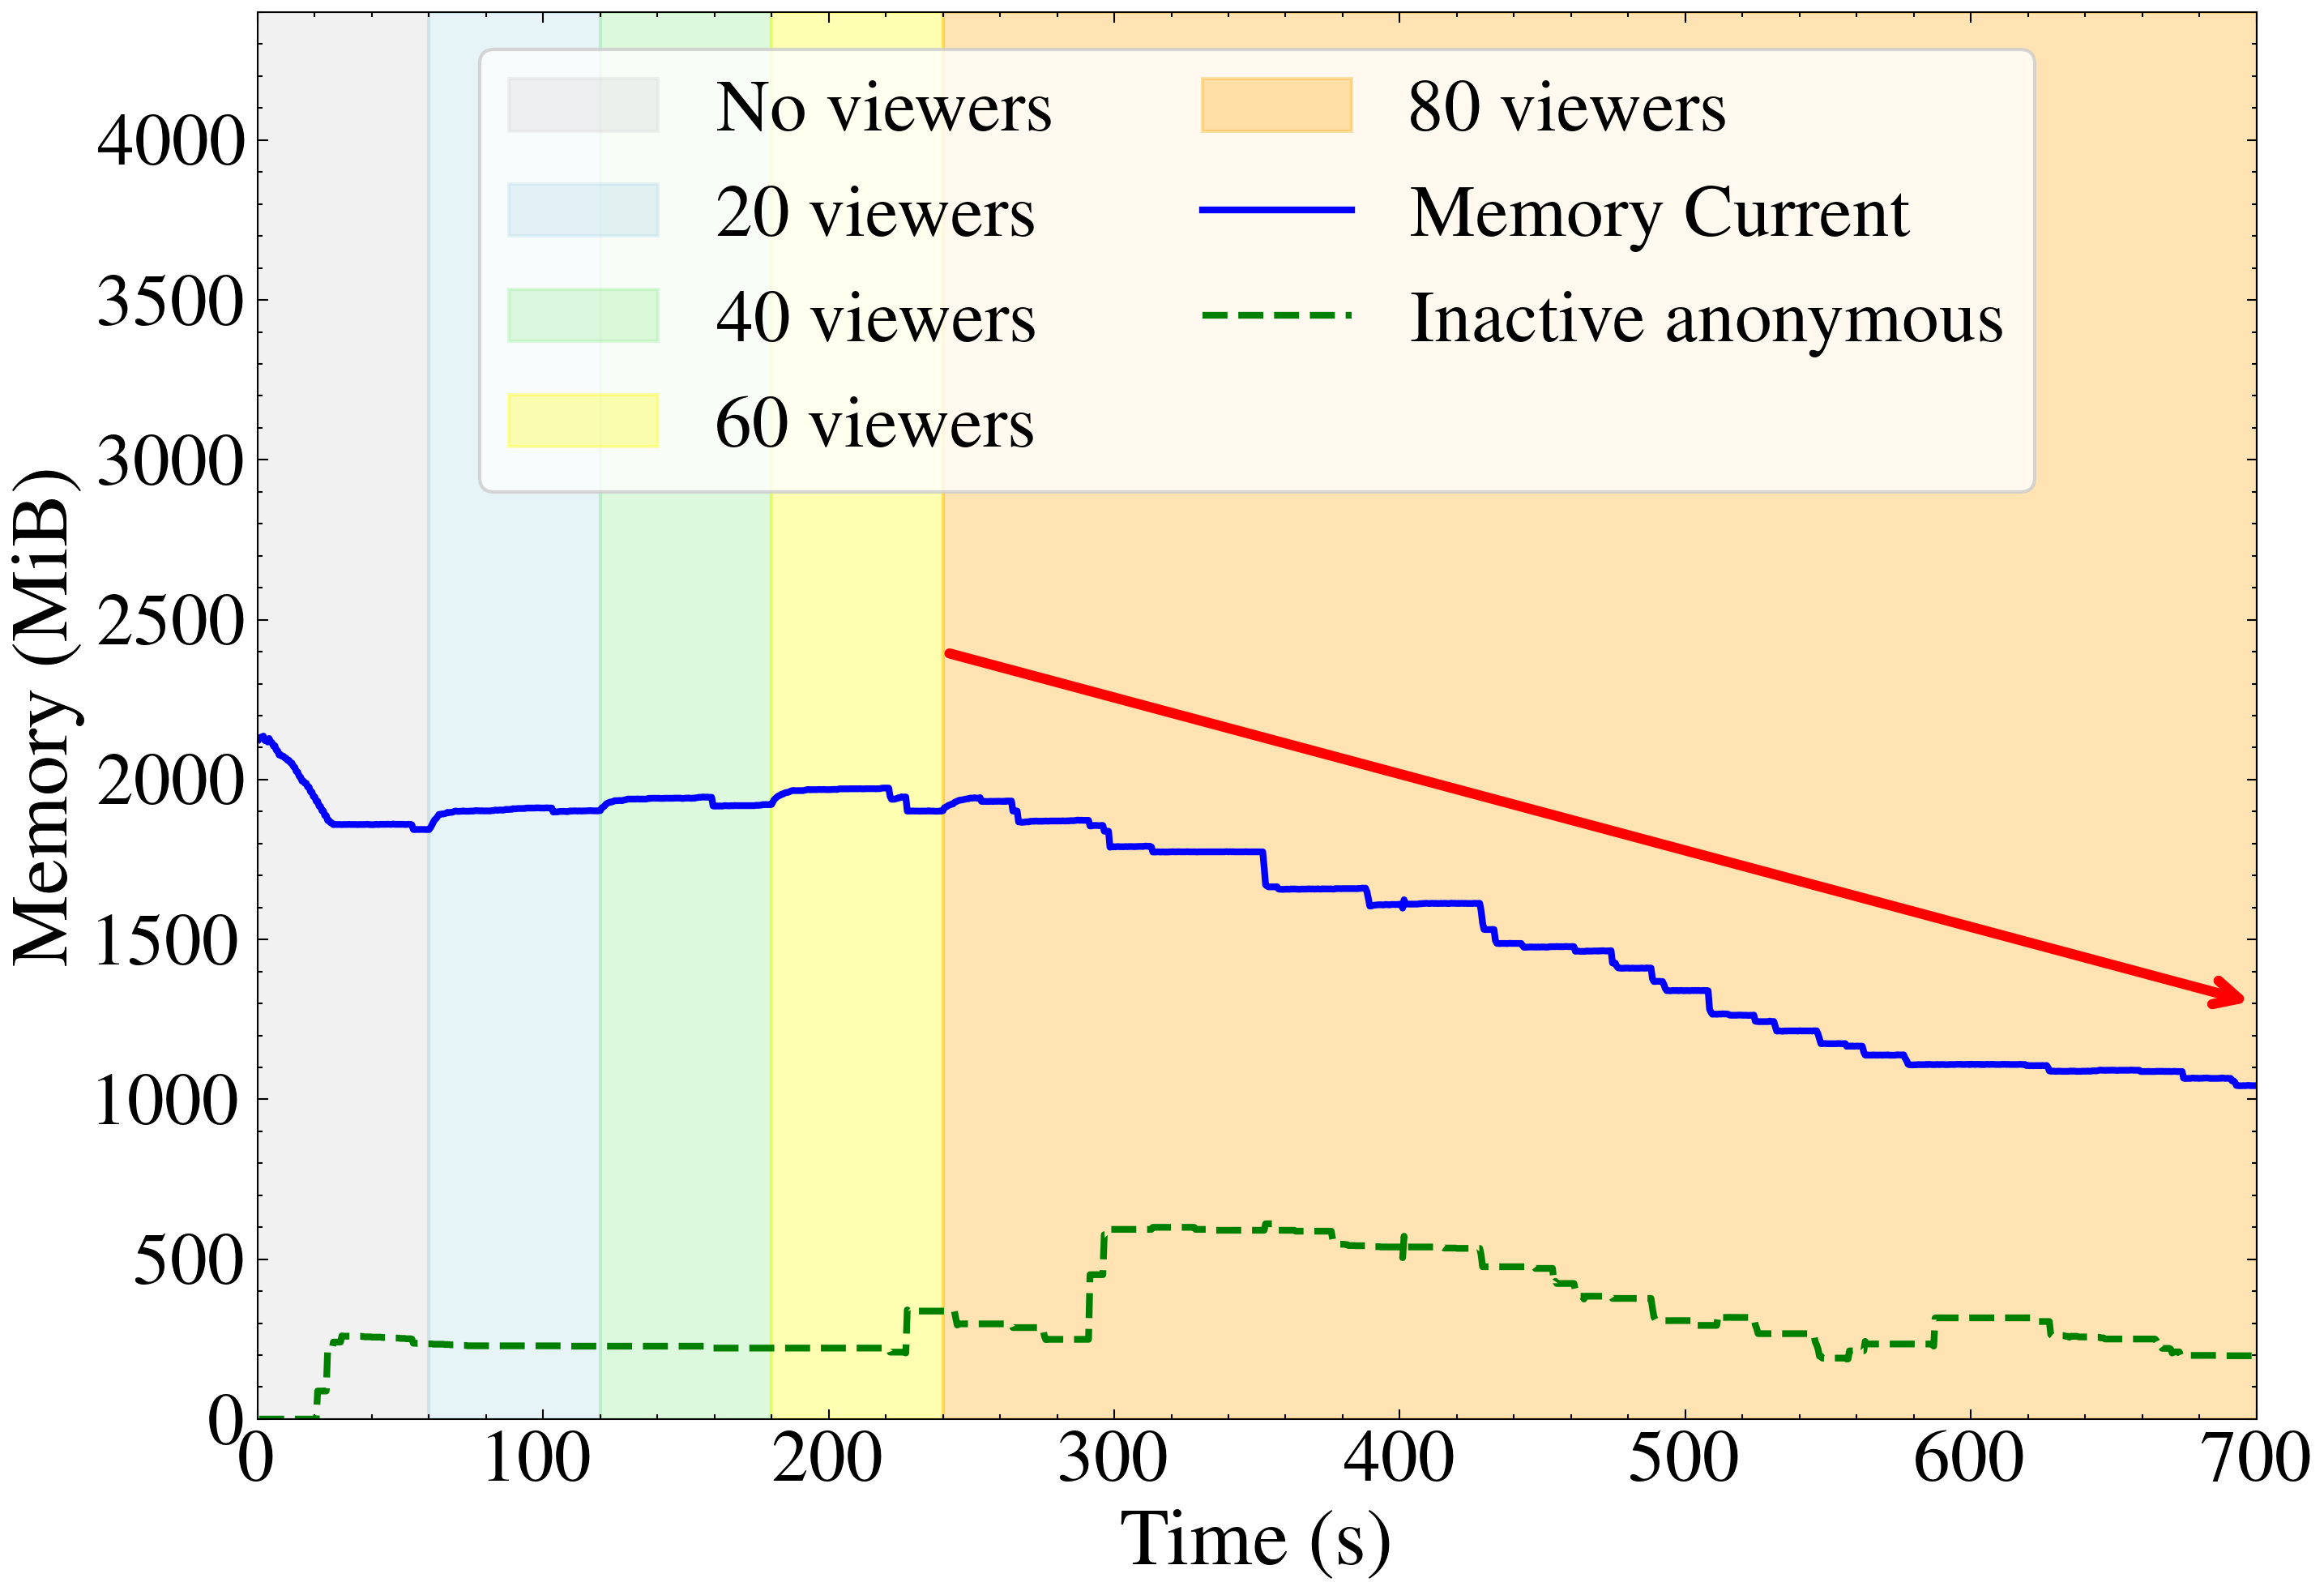

In [192]:
def annotate_circle(ax, x, y, radius):
    ax.scatter(x, y, s=radius, color='none', edgecolors='red', linewidth=3, marker='o', label='_nolegend_')

def annotate_oval(ax, x, y, radius):
    circle = plt.Circle((x, y), radius, color='red', fill=False, linewidth=3)
    ax.add_patch(circle)

def annotate_1(ax):
    annotate_circle(ax, x=20, y=2000, radius=1500)
    annotate_circle(ax, x=20, y=200, radius=1500)

def annotate_2(ax):
    annotate_oval(ax, x=150, y=1900, radius=100)
    annotate_oval(ax, x=150, y=200, radius=100)

def cgroup_regul(name, annotate=None):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    fig.patch.set_alpha(0.0)
    
    go_annotate(ax)
    
    ax.plot(df["TIME"]/1000, df["ram"], label="Memory Current", color='b', lw=2)
    # ax.plot(df["TIME"]/1000, df["active"]/(1024*1024), label="Active anonymous", color='darkblue', lw=2)
    # ax.plot(df["TIME"]/1000, df["swap"], label="SWAP (cgroups)", color='r', lw=2)
    ax.plot(df["TIME"]/1000, df["inactive"]/(1024*1024), label="Inactive anonymous", color='g', lw=2)
    
    ax.set_xlabel('Time (s)', fontweight='bold', fontsize=24)
    ax.set_ylabel('Memory (MiB)', fontweight='bold', fontsize=24)
    ax.set_ylim(0,4400)
    ax.set_xlim(0,700)
    ax.legend(loc="upper center", frameon=True, ncol=2, fontsize=22)

    if annotate:
        annotate(ax)
    
    for label in ax.get_xticklabels():
        label.set_fontsize(22)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(22)
    
    plt.tight_layout()
    plt.savefig(f'figure-notebook/cgroups_webrtc_results/{name}.pdf', bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

cgroup_regul("1")
cgroup_regul("2", annotate=annotate_1)
cgroup_regul("3", annotate=annotate_2)
cgroup_regul("4", annotate=lambda ax: annotate_arrow(ax, 240, 2400, 700, 1300))

shape: (699, 6)
┌────────┬─────────┬──────────┬──────┬────────────┬──────────────────────┐
│ TIME   ┆ hostram ┆ guestram ┆ swap ┆ available  ┆ count("MEMORY USED") │
│ ---    ┆ ---     ┆ ---      ┆ ---  ┆ ---        ┆ ---                  │
│ i64    ┆ f64     ┆ f64      ┆ f64  ┆ f64        ┆ i64                  │
╞════════╪═════════╪══════════╪══════╪════════════╪══════════════════════╡
│ 500    ┆ 1742.0  ┆ null     ┆ 0.0  ┆ 0.0        ┆ 11                   │
│ 1000   ┆ 1744.0  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 1500   ┆ 1744.0  ┆ 692.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 2000   ┆ 1744.0  ┆ 692.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 2500   ┆ 1744.0  ┆ 693.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ …      ┆ …       ┆ …        ┆ …    ┆ …          ┆ …                    │
│ 347500 ┆ 2462.0  ┆ 727.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 348000 ┆ 2461.0  ┆ 727.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 348500 

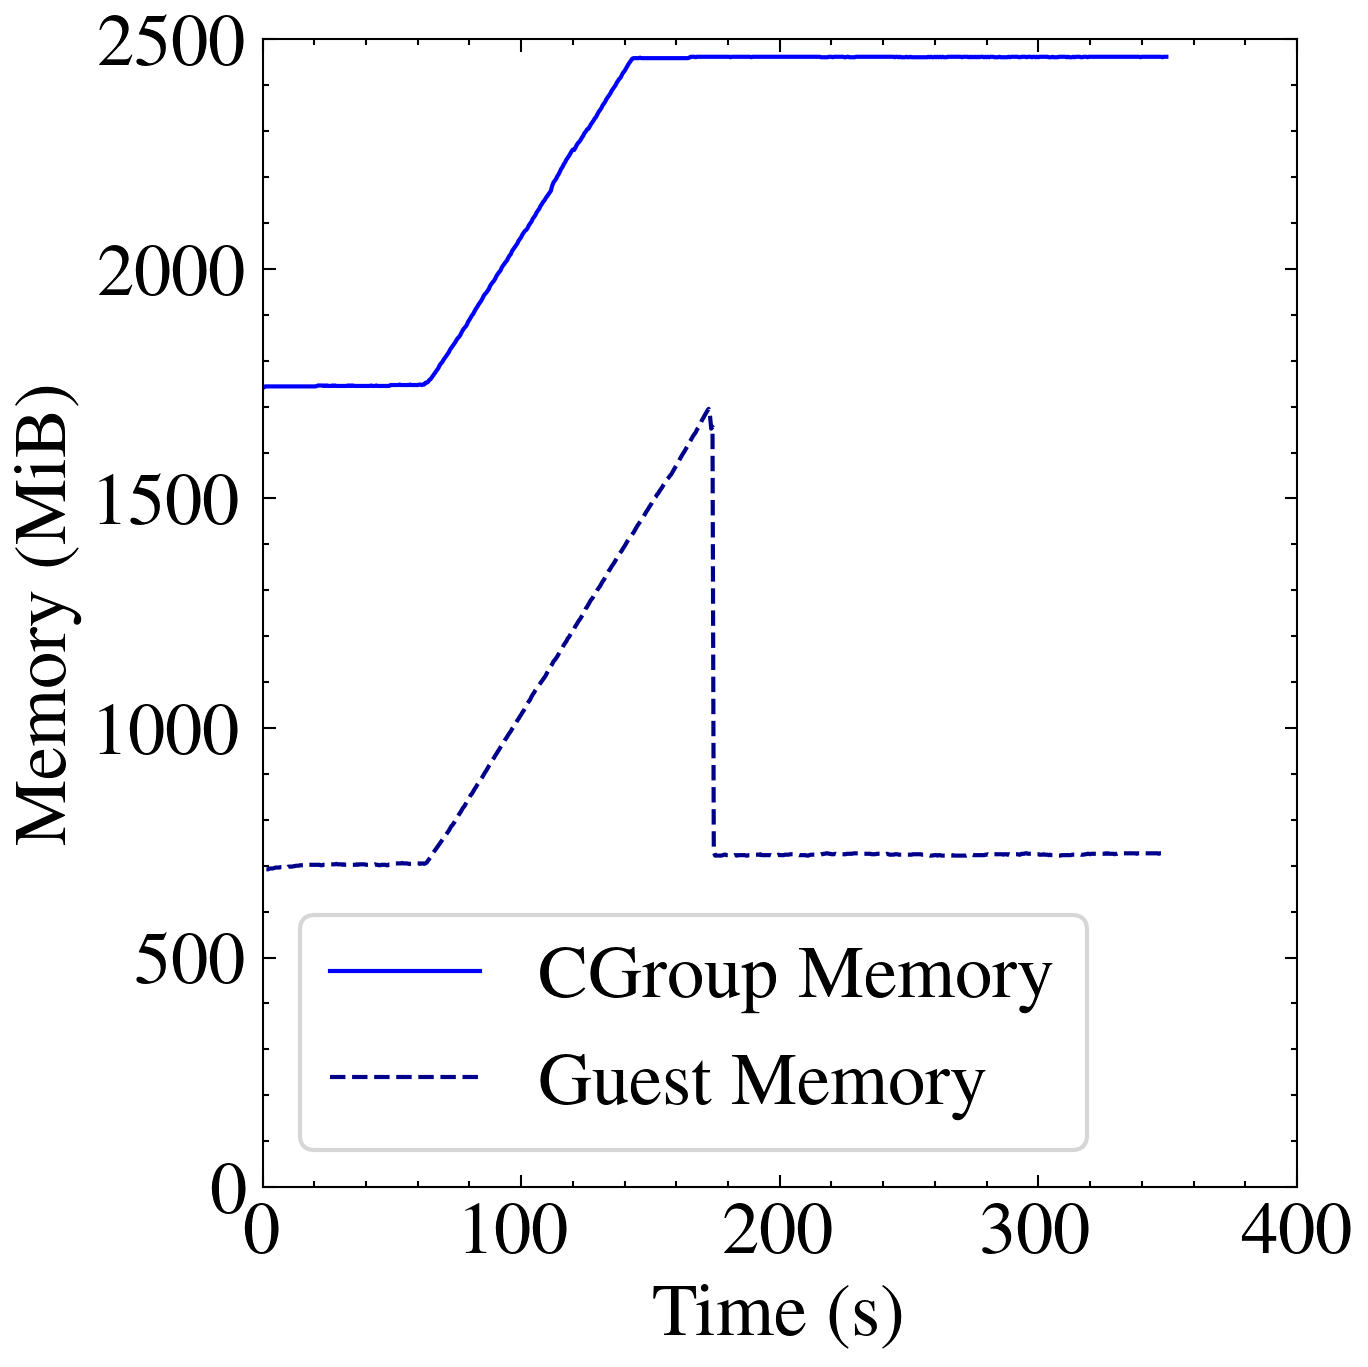

In [75]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='baseline-pid-mongodb-latest'
GROUP BY TIME
HAVING TIME < 350000
ORDER BY TIME
"""
df = con.execute(query).pl()
print(df)

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["hostram"], label="CGroup Memory", color='b')
ax.plot(df["TIME"]/1000, df["guestram"], label="Guest Memory", color='darkblue')
# ax.plot(df["TIME"]/1000, df["swap"]/(1024), label="SWAP (cgroups)", color='r')
# ax.plot(df["TIME"]/1000, df["available"]/(1024), label="Inactive anonymous", color='g')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(0,400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/baseline_redis.pdf', bbox_inches='tight', dpi=300)
plt.show()

shape: (880, 6)
┌────────┬─────────┬──────────┬──────┬────────────┬──────────────────────┐
│ TIME   ┆ hostram ┆ guestram ┆ swap ┆ available  ┆ count("MEMORY USED") │
│ ---    ┆ ---     ┆ ---      ┆ ---  ┆ ---        ┆ ---                  │
│ i64    ┆ f64     ┆ f64      ┆ f64  ┆ f64        ┆ i64                  │
╞════════╪═════════╪══════════╪══════╪════════════╪══════════════════════╡
│ 500    ┆ 1682.0  ┆ null     ┆ 0.0  ┆ 0.0        ┆ 10                   │
│ 1000   ┆ 1682.5  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ 1500   ┆ 1682.0  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ 2000   ┆ 1682.5  ┆ 694.5    ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ 2500   ┆ 1682.0  ┆ 695.0    ┆ 0.0  ┆ 4.004684e6 ┆ 10                   │
│ …      ┆ …       ┆ …        ┆ …    ┆ …          ┆ …                    │
│ 438000 ┆ 1235.0  ┆ 739.0    ┆ 0.0  ┆ 961284.0   ┆ 7                    │
│ 438500 ┆ 1235.0  ┆ 739.0    ┆ 0.0  ┆ 961284.0   ┆ 7                    │
│ 439000 

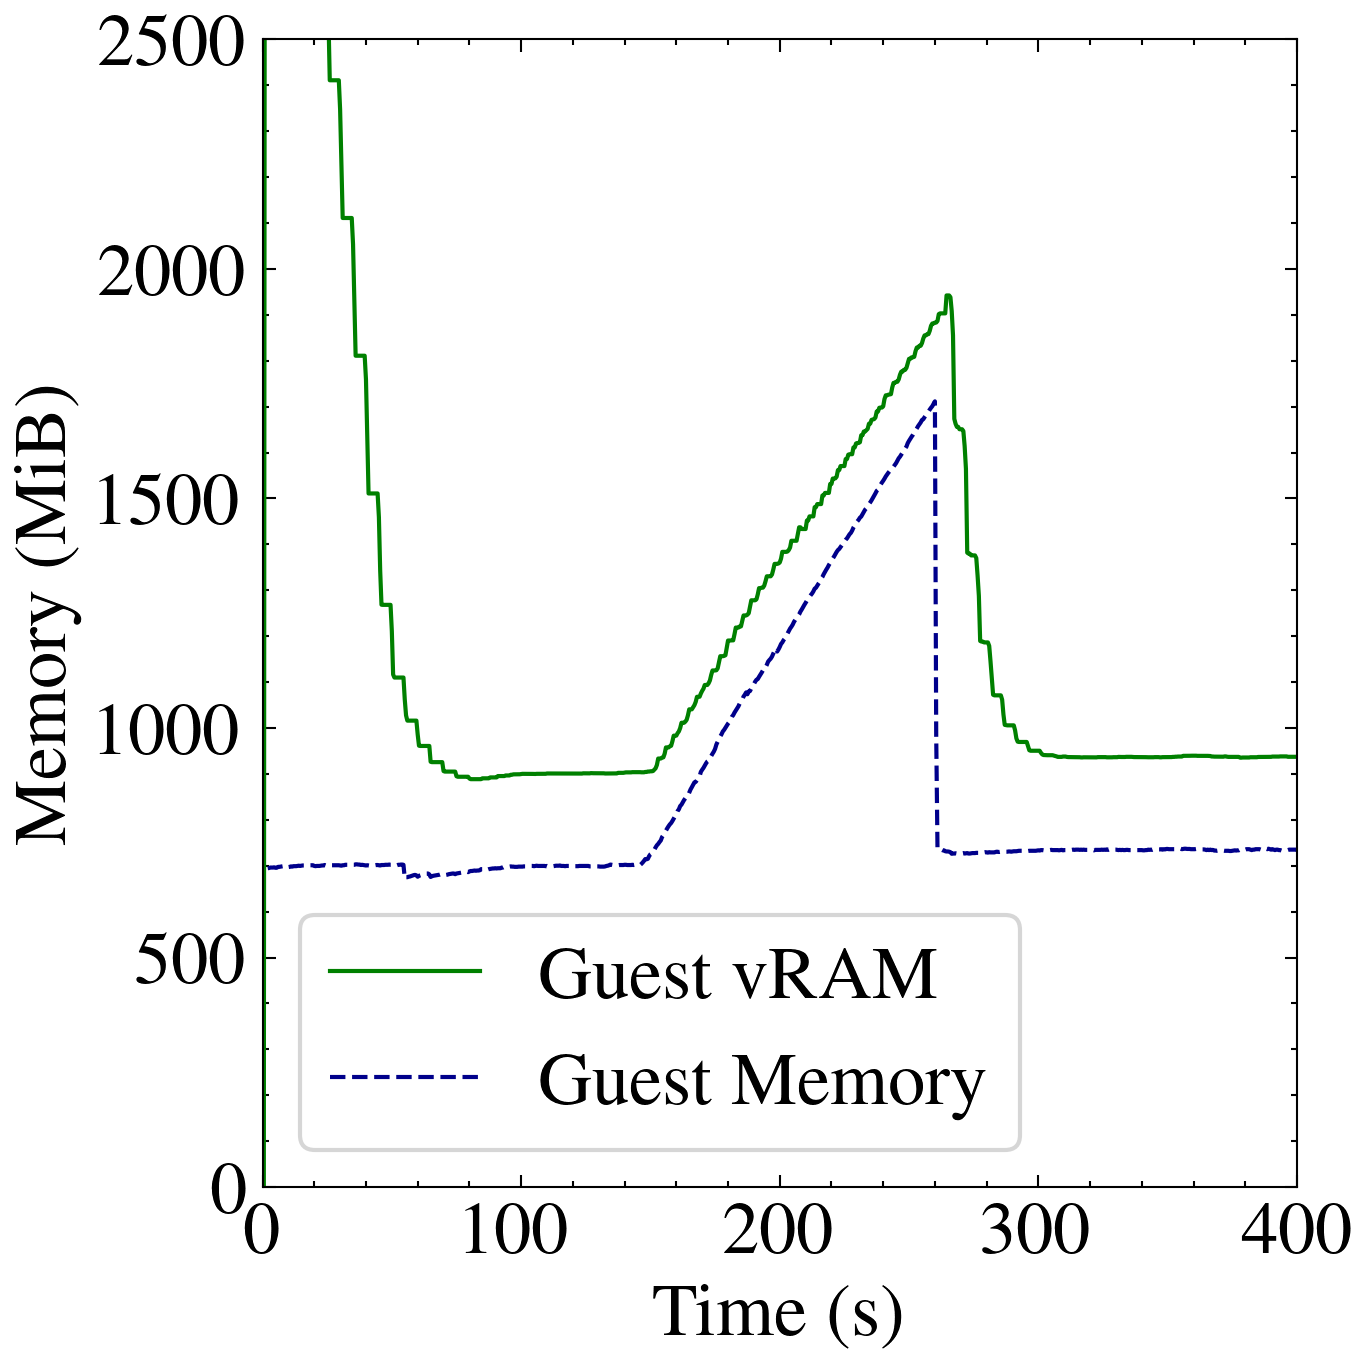

In [76]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='balloon-pid-mongodb-latest-300'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()
print(df)

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# ax.plot(df["TIME"]/1000, df["hostram"], label="CGroup Memory", color='b')
ax.plot(df["TIME"]/1000, df["available"]/(1024), label="Guest vRAM", color='g')
ax.plot(df["TIME"]/1000, df["guestram"], label="Guest Memory", color='darkblue')
# ax.plot(df["TIME"]/1000, df["swap"]/(1024), label="SWAP (cgroups)", color='r')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(0,400)
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/baseline_redis.pdf', bbox_inches='tight', dpi=300)
plt.show()

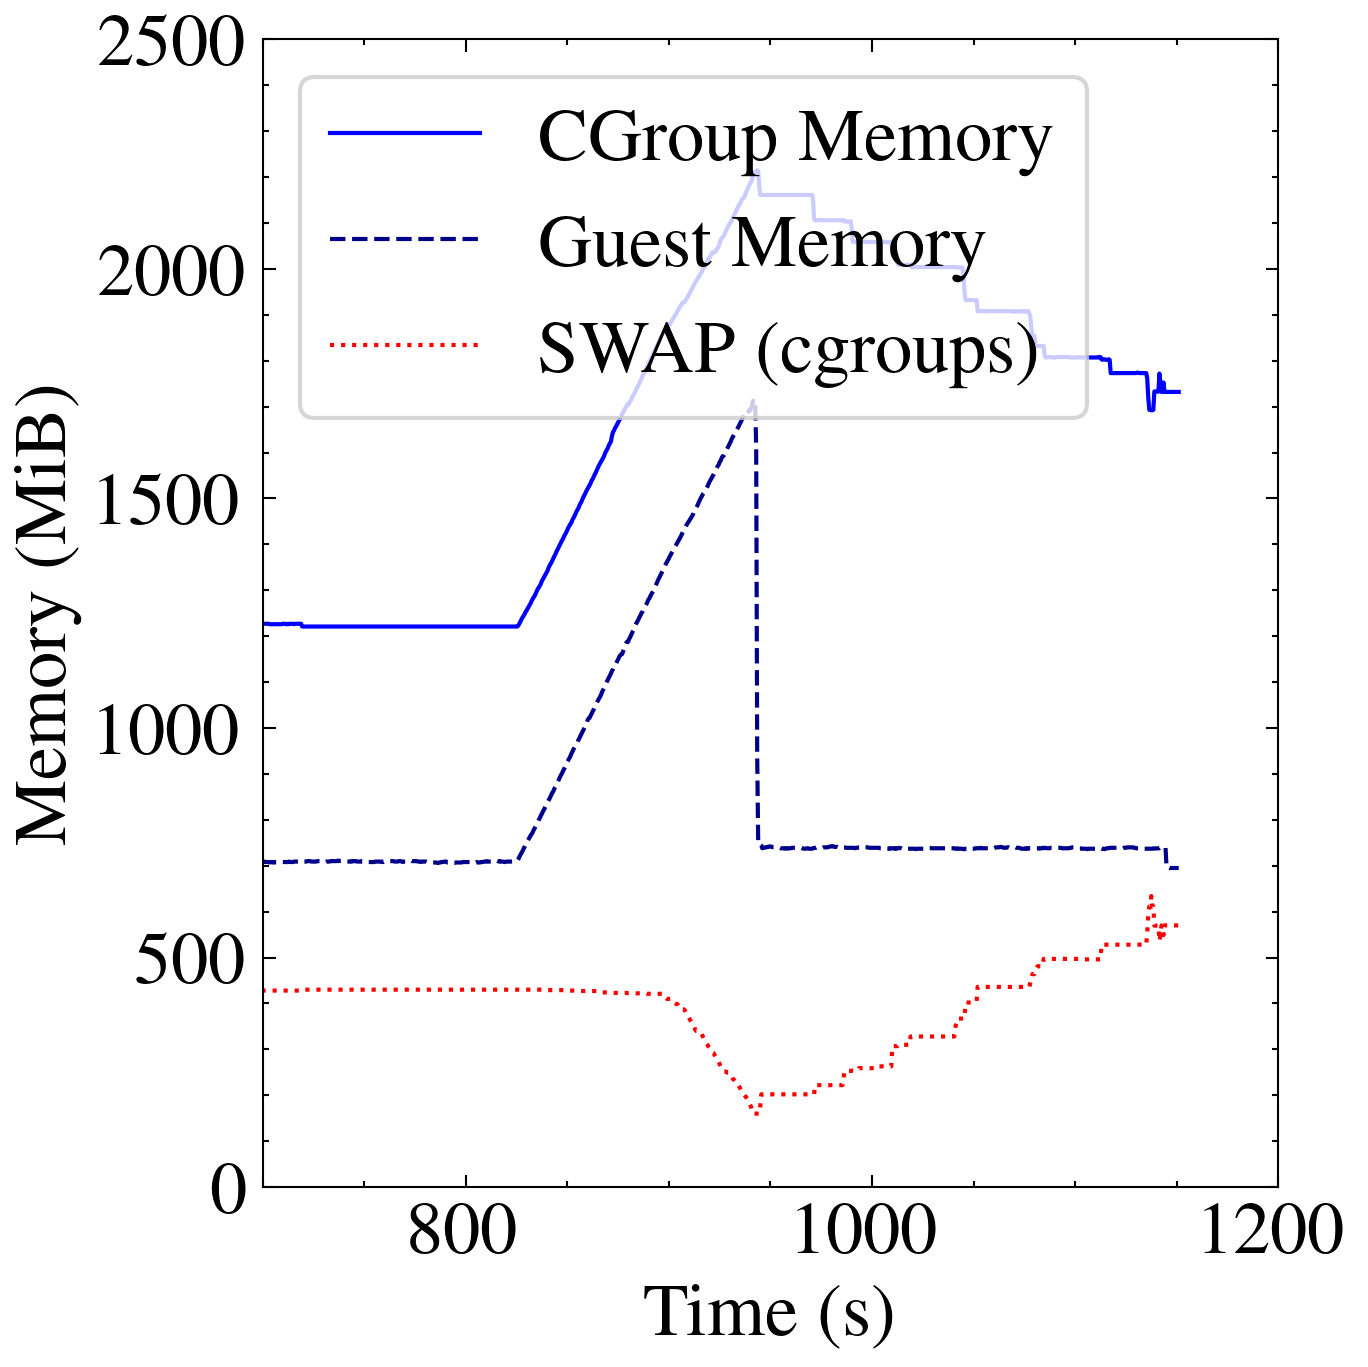

In [78]:
query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='cgroups-pid-mongodb-latest'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(df["TIME"]/1000, df["hostram"], label="CGroup Memory", color='b')
# ax.plot(df["TIME"]/1000, df["available"]/(1024), label="Guest vRAM", color='g')
ax.plot(df["TIME"]/1000, df["guestram"], label="Guest Memory", color='darkblue')
ax.plot(df["TIME"]/1000, df["swap"], label="SWAP (cgroups)", color='r')

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(700,1200)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig('figure-notebook/baseline_redis.pdf', bbox_inches='tight', dpi=300)
plt.show()

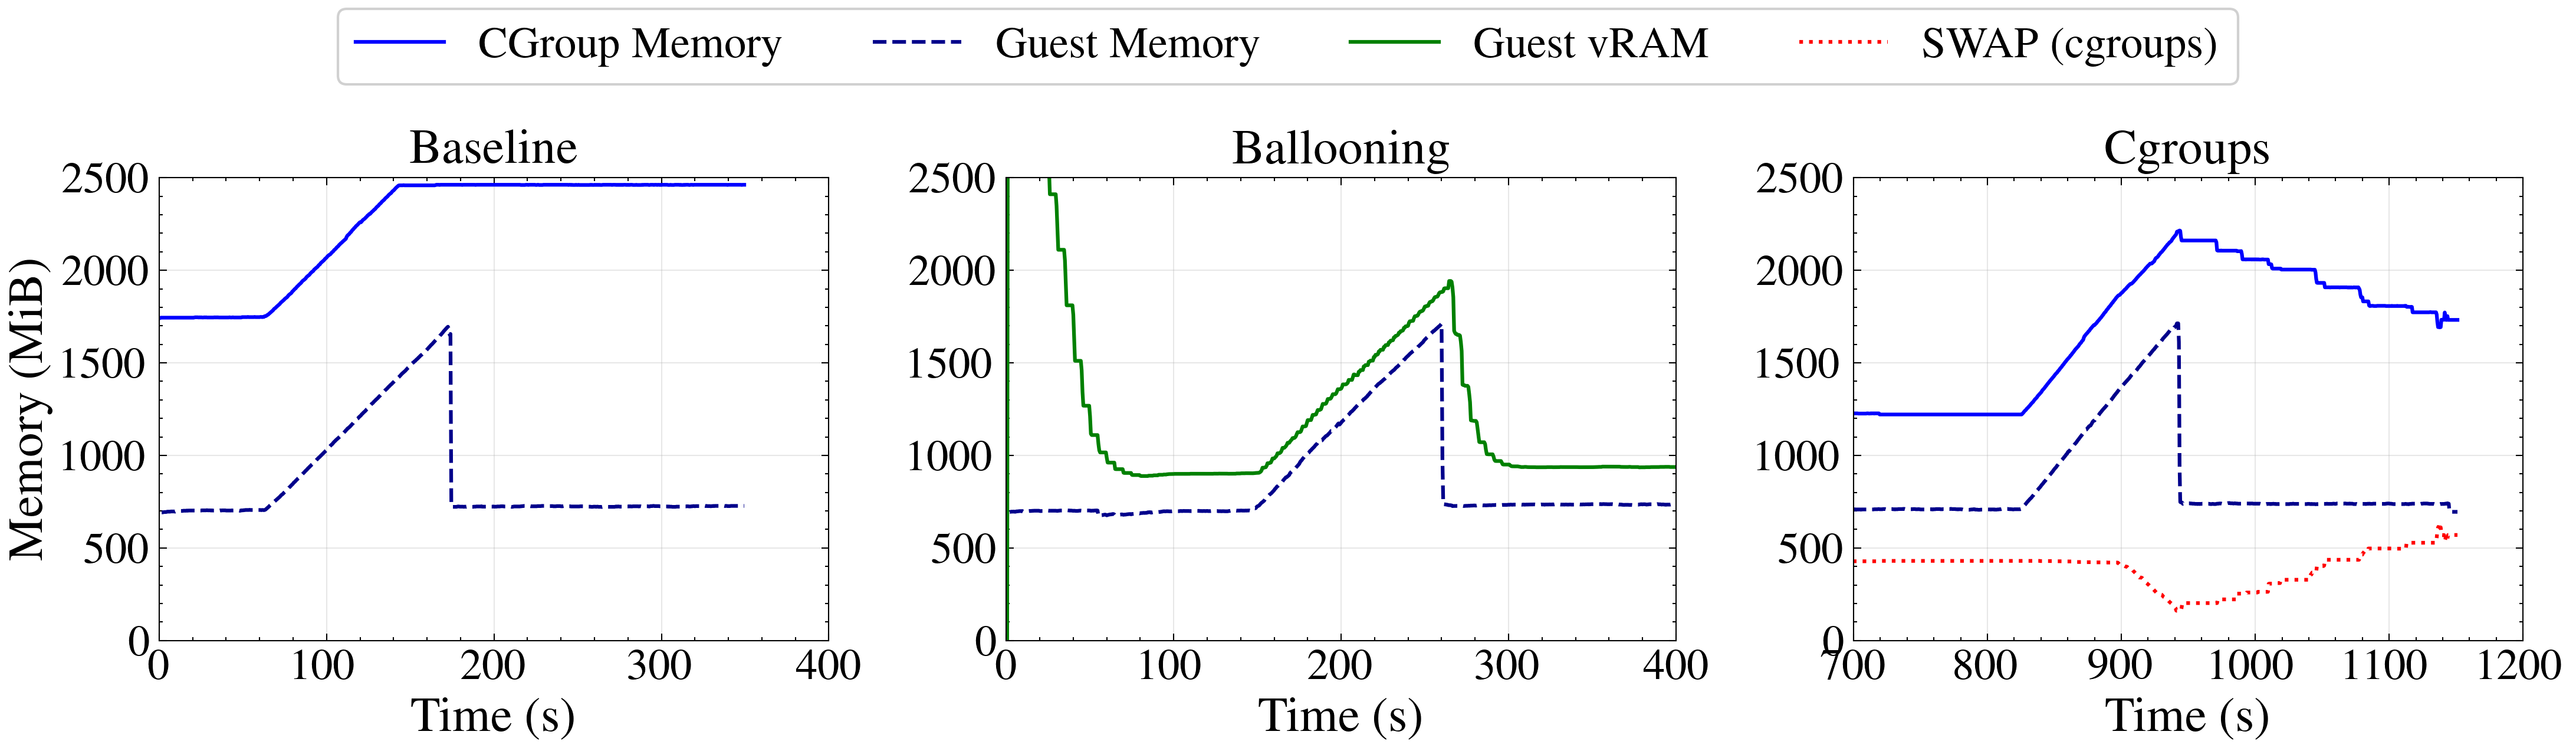

In [84]:
query_baseline = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='baseline-pid-mongodb-latest'
GROUP BY TIME
HAVING TIME < 350000
ORDER BY TIME
"""
df_baseline = con.execute(query_baseline).pl()

query_balloon = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='balloon-pid-mongodb-latest-300'
GROUP BY TIME
ORDER BY TIME
"""
df_balloon = con.execute(query_balloon).pl()

query_cgroups = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='cgroups-pid-mongodb-latest'
GROUP BY TIME
ORDER BY TIME
"""
df_cgroups = con.execute(query_cgroups).pl()

# Figure avec 3 subplots horizontaux
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=300)
fig.patch.set_alpha(0.0)

# ========== Subplot 1: Baseline ==========
ax = axes[0]
ax.plot(df_baseline["TIME"]/1000, df_baseline["hostram"], label="CGroup Memory", color='b', linewidth=1.5)
ax.plot(df_baseline["TIME"]/1000, df_baseline["guestram"], label="Guest Memory", color='darkblue', linewidth=1.5)
ax.set_xlabel('Time (s)', fontweight='bold', fontsize=20)
ax.set_ylabel('Memory (MiB)', fontweight='bold', fontsize=20)
ax.set_ylim(0, 2500)
ax.set_xlim(0, 400)
ax.set_title('Baseline', fontweight='bold', fontsize=20)
ax.grid(alpha=0.3)

# ========== Subplot 2: Ballooning ==========
ax = axes[1]
ax.plot(df_balloon["TIME"]/1000, df_balloon["available"]/(1024), label="Guest vRAM", color='g', linewidth=1.5)
ax.plot(df_balloon["TIME"]/1000, df_balloon["guestram"], label="Guest Memory", color='darkblue', linewidth=1.5)
ax.set_xlabel('Time (s)', fontweight='bold', fontsize=20)
#ax.set_ylabel('Memory (MiB)', fontweight='bold', fontsize=14)
ax.set_ylim(0, 2500)
ax.set_xlim(0, 400)
ax.set_title('Ballooning', fontweight='bold', fontsize=20)
ax.grid(alpha=0.3)

# ========== Subplot 3: Cgroups ==========
ax = axes[2]
ax.plot(df_cgroups["TIME"]/1000, df_cgroups["hostram"], label="CGroup Memory", color='b', linewidth=1.5)
ax.plot(df_cgroups["TIME"]/1000, df_cgroups["guestram"], label="Guest Memory", color='darkblue', linewidth=1.5)
ax.plot(df_cgroups["TIME"]/1000, df_cgroups["swap"], label="SWAP (cgroups)", color='r', linewidth=1.5)
ax.set_xlabel('Time (s)', fontweight='bold', fontsize=20)
# ax.set_ylabel('Memory (MiB)', fontweight='bold', fontsize=14)
ax.set_ylim(0, 2500)
ax.set_xlim(700, 1200)
ax.set_title('Cgroups', fontweight='bold', fontsize=20)
ax.grid(alpha=0.3)

# Légende unique en haut
handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
handles3, labels3 = axes[2].get_legend_handles_labels()

# Fusionner toutes les légendes uniques
all_handles = handles + handles2 + handles3
all_labels = labels + labels2 + labels3
unique_labels = list(dict.fromkeys(all_labels))  # Supprimer les doublons
unique_handles = [all_handles[all_labels.index(label)] for label in unique_labels]

fig.legend(unique_handles, unique_labels, loc='center', bbox_to_anchor=(0.5, 1.05), 
           ncol=4, frameon=True, fontsize=18, framealpha=0.9)

plt.tight_layout()
plt.savefig('figure-notebook/db.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

shape: (717, 6)
┌────────┬─────────┬──────────┬──────┬────────────┬──────────────────────┐
│ TIME   ┆ hostram ┆ guestram ┆ swap ┆ available  ┆ count("MEMORY USED") │
│ ---    ┆ ---     ┆ ---      ┆ ---  ┆ ---        ┆ ---                  │
│ i64    ┆ f64     ┆ f64      ┆ f64  ┆ f64        ┆ i64                  │
╞════════╪═════════╪══════════╪══════╪════════════╪══════════════════════╡
│ 500    ┆ 1742.0  ┆ null     ┆ 0.0  ┆ 0.0        ┆ 11                   │
│ 1000   ┆ 1744.0  ┆ null     ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 1500   ┆ 1744.0  ┆ 692.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 2000   ┆ 1744.0  ┆ 692.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ 2500   ┆ 1744.0  ┆ 693.0    ┆ 0.0  ┆ 4.004684e6 ┆ 11                   │
│ …      ┆ …       ┆ …        ┆ …    ┆ …          ┆ …                    │
│ 356500 ┆ 2396.0  ┆ 726.0    ┆ 0.0  ┆ 4.004688e6 ┆ 1                    │
│ 357000 ┆ 2396.0  ┆ 726.0    ┆ 0.0  ┆ 4.004688e6 ┆ 1                    │
│ 357500 

/tmp/ipykernel_198950/3228881195.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = matplotlib.cm.get_cmap('tab10').colors


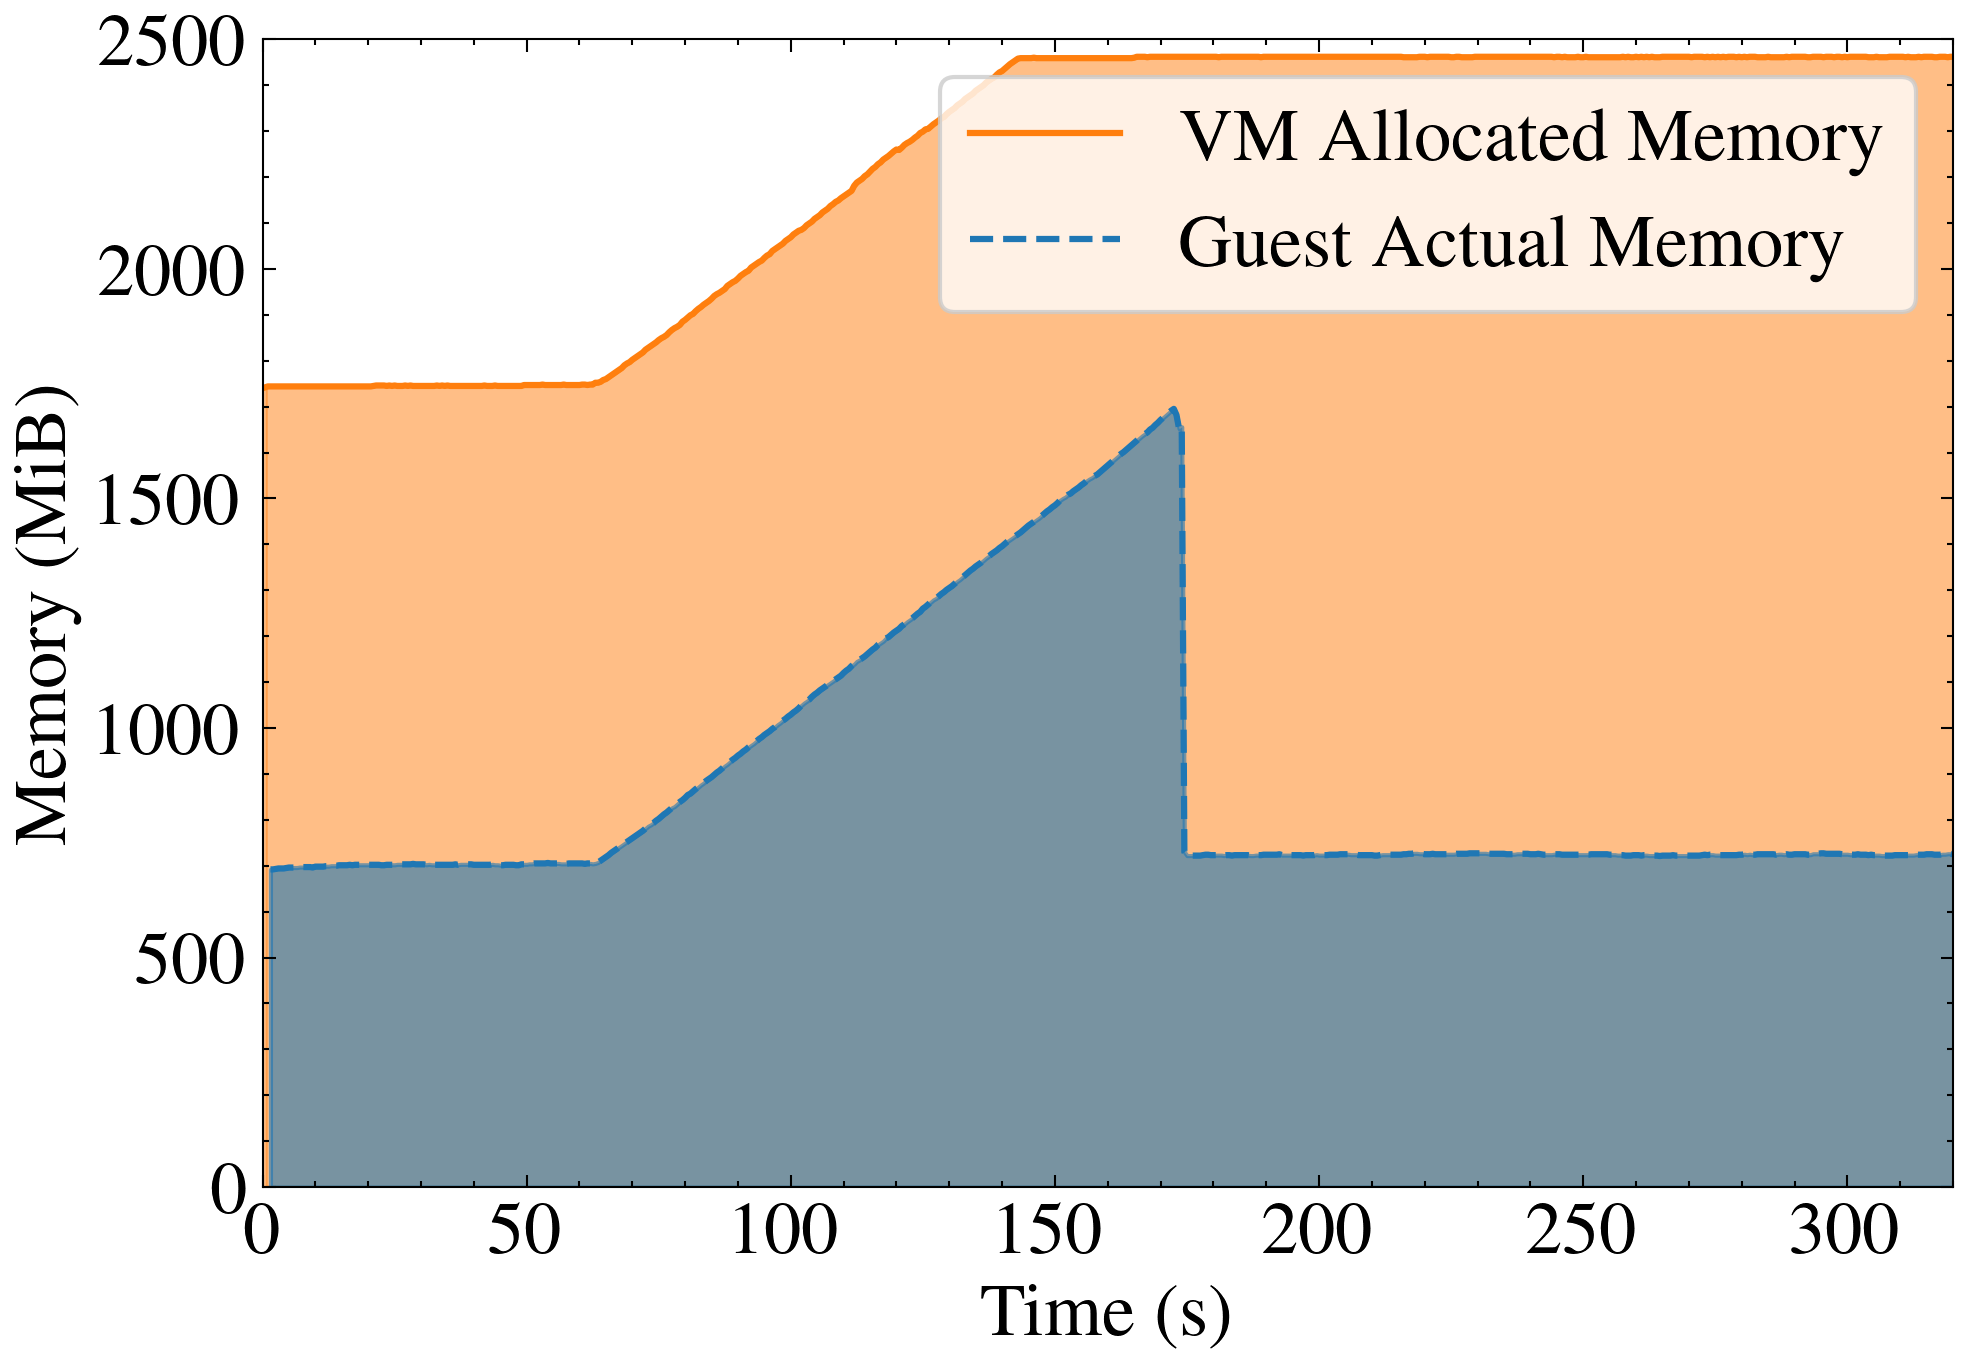

In [23]:
import matplotlib

query = """
SELECT TIME, 
       MEDIAN("MEMORY USED") AS "hostram",
       MEDIAN("VM MEMORY USAGE") AS "guestram",
       MEDIAN("SWAP") AS "swap",
       MEDIAN("VIRSH AVAILABLE") AS "available",
       COUNT("MEMORY USED")
FROM stats
WHERE exp_name='baseline-pid-mongodb-latest'
GROUP BY TIME
ORDER BY TIME
"""
df = con.execute(query).pl()
print(df)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
fig.patch.set_alpha(0.0)                                                                                                                                                                        
ax.set_facecolor('none')

colors = matplotlib.cm.get_cmap('tab10').colors

time = df["TIME"]/1000

ax.fill_between(time, df["hostram"], color=colors[1], alpha=0.5)
ax.fill_between(time, df["guestram"], color=colors[0], alpha=0.6)

ax.plot(time, df["hostram"], label="VM Allocated Memory", color=colors[1], linewidth=1.5)
ax.plot(time, df["guestram"], label="Guest Actual Memory", color=colors[0], linewidth=1.5)

ax.set_xlabel('Time (s)', fontweight='bold')
ax.set_ylabel('Memory (MiB)', fontweight='bold')
ax.set_ylim(0,2500)
ax.set_xlim(0,320)
ax.legend(frameon=True, loc='upper right')

plt.tight_layout()
plt.savefig("figure-notebook/memory_area_plot.pdf", transparent=True)
plt.show()
